# ITT Roosevelt — Corredor Av. Roosevelt, Cali
## Indice de Transformacion Territorial · 5 Dimensiones · 2023-2026
---
**Zona:** Corredor Av. Roosevelt (buffer 100 m) — Comuna 19  
**Periodo:** 2023-2026 (series anuales + trimestrales)  
**Notebook:** `notebooks/01_itt_roosevelt.ipynb`  

Metodologia homologada al documento maestro ITT:  
ITT = 0.27·Seg + 0.22·Mov + 0.19·DesSocial + 0.17·EntU + 0.15·DesEco

In [1]:
# Descomentar en Colab
# !pip install geopandas pyproj shapely openpyxl matplotlib seaborn folium rasterio pillow -q

import subprocess, sys
def check_pkg(pkg):
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
for p in ['geopandas','pyproj','shapely','openpyxl','seaborn','folium','rasterio','Pillow']: check_pkg(p)
print('Dependencias verificadas')

Dependencias verificadas


In [2]:
import json, os, re, warnings
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import folium
warnings.filterwarnings('ignore')

OKI_AZUL    = '#0072B2'
OKI_NARANJA = '#E69F00'
OKI_VERDE   = '#009E73'
OKI_AMARILLO= '#F0E442'
OKI_AZUL_C  = '#56B4E9'
OKI_BERMELL = '#D55E00'
OKI_MORADO  = '#CC79A7'
OKI_GRIS    = '#333333'
C_SEG = OKI_AZUL; C_MOV = OKI_NARANJA; C_COH = OKI_VERDE; C_ITT = OKI_GRIS; BG = '#F4F6F9'
NIVEL_COLORS = {
    'Activacion':     OKI_BERMELL,
    'Consolidacion':  OKI_NARANJA,
    'Transformacion': OKI_VERDE,
    'Escala':         OKI_AZUL,
}
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3,
})
print('Configuracion visual lista - Paleta Okabe-Ito activa')

Configuracion visual lista - Paleta Okabe-Ito activa


In [3]:
import os
from pathlib import Path

if os.path.exists('/content/itt_repos_cali'):
    !git -C /content/itt_repos_cali pull
else:
    !git clone https://github.com/j0rg3c45/Itt_repos_cali.git /content/itt_repos_cali

DATA_DIR = Path('/content/itt_repos_cali/data/itt_roosevelt')
REPO     = Path('/content/itt_repos_cali')
print('Carpetas disponibles:')
for p in sorted(DATA_DIR.iterdir()):
    print(f'  {p.name}')

Already up to date.
Carpetas disponibles:
  .gitkeep
  1_Dimension_Seguridad
  2_Dimensión_Cohesion_Social
  3_Dimension_Movilidad
  4_Desarrollo_Economico
  5_Entorno_Urbano
  6_Educacion
  Geojson_tramos_Roosevelt.geojson
  Geojson_tramos_Roosevelt.qmd
  Geojson_tramos_Roosevelt_Buffer_100.geojson
  Geojson_tramos_Roosevelt_Buffer_100.qmd
  README.md
  tramos_Roosevelt.geojson
  tramos_Roosevelt_Buffer_100.geojson


In [4]:
from pathlib import Path
import os

REPO     = Path('/content/itt_repos_cali')
DATA_DIR = REPO / 'data' / 'itt_roosevelt'
# Para ejecucion local descomentar:
# DATA_DIR = Path('./data/itt_roosevelt')
# REPO     = Path('.')

D = DATA_DIR
PATHS = {
    'poligono':    str(D / 'tramos_Roosevelt_Buffer_100.geojson'),
    'homicidios':  str(D / '1_Dimension_Seguridad' / 'DATIC_homicidios_2023_2026T1_Roosevelt.geojson'),
    'hurtos':      str(D / '1_Dimension_Seguridad' / 'DATIC_hurtos_2023_2026T1_Roosevelt.geojson'),
    'comparendos': str(D / '1_Dimension_Seguridad' / 'DATIC_comparendos_2023_2026T1_Roosevelt.geojson'),
    'vif':         str(D / '2_Dimensión_Cohesion_Social' / 'DATIC_violencia_intrafamiliar_2023_2026T1_Roosevelt.geojson'),
    'siniestros':  str(D / '3_Dimension_Movilidad' / 'BD_SINIESTROS_2023_2026_COMUNA_BARRIO_84_filtrado_tramos_Roosevelt_Buffer_100.geojson'),
    'arboles':     str(D / '5_Entorno_Urbano' / 'CENSO_ARBOREO_filtrado_tramos_Roosevelt_Buffer_100.geojson'),
    'sedes':       str(D / '6_Educacion' / 'Sedes_educativas_oficiales_Roosevelt.geojson'),
    'registro_mercantil': str(D / '4_Desarrollo_Economico' / 'registro_mercantil_2025_con_coordenadas_filtrado_tramos_Roosevelt_Buffer_100.geojson'),
}

ANIOS       = [2023, 2024, 2025, 2026]
ANO_CORTE   = 2026
ZONA_NOMBRE = 'Corredor Roosevelt — Comuna 19'

PESOS = {
    'Seguridad': 0.27,
    'Movilidad': 0.22,
    'DesSocial': 0.19,
    'EntornoU':  0.17,
    'DesEco':    0.15,
}

# Umbrales calibrados a la escala del corredor (mayor que un barrio)
REFS = {
    'homicidios':      (0,   8,   True,  'Homicidios anuales en el corredor'),
    'hurtos':          (100, 350, True,  'Hurtos anuales en el corredor'),
    'siniestralidad':  (10,  45,  True,  'Siniestros viales anuales'),
    'lesionados':      (8,   35,  True,  'Accidentes con lesionados anuales'),
    'mortales':        (0,   4,   True,  'Accidentes mortales anuales'),
    'vif':             (3,   15,  True,  'Violencia intrafamiliar anual'),
    'rinas':           (0,   25,  True,  'Rinas / conflictividad anual'),
    'spa':             (0,   200, True,  'Sustancias psicoactivas (comparendos) anuales'),
}

# Fallback solo si las celdas de dimension no ejecutan
# roo_eu2 sobreescribe EntornoU, roo_ed3 sobreescribe EducDes (+ carry-forward 2026)
# roo_de3 sobreescribe DesEco (+ carry-forward 2026)
REF_ENTORNO_U      = 39.2
REF_EDUC_DES       = 54.9
REF_DES_ECO        = 50.0
REF_VULNERABILIDAD = 54.1  # contexto, no entra al score

print(f'Zona: {ZONA_NOMBRE}  |  Periodo: {ANIOS[0]}-{ANIOS[-1]}')
for nombre, path in PATHS.items():
    mark = 'OK  ' if os.path.exists(path) else 'FALTA'
    print(f'  {mark}  {nombre}: {os.path.basename(path)}')
print()
print('Pesos ITT (5 dims):', ' | '.join(f'{k}={v:.0%}' for k, v in PESOS.items()))
print(f'Suma pesos: {sum(PESOS.values()):.2f}')
print('\nUmbrales:')
for ind, (rmin, rmax, inv, desc) in REFS.items():
    print(f'  {ind:18s}  [{rmin:>3} - {rmax:>4}]  inv={inv}  — {desc}')

Zona: Corredor Roosevelt — Comuna 19  |  Periodo: 2023-2026
  OK    poligono: tramos_Roosevelt_Buffer_100.geojson
  OK    homicidios: DATIC_homicidios_2023_2026T1_Roosevelt.geojson
  OK    hurtos: DATIC_hurtos_2023_2026T1_Roosevelt.geojson
  OK    comparendos: DATIC_comparendos_2023_2026T1_Roosevelt.geojson
  OK    vif: DATIC_violencia_intrafamiliar_2023_2026T1_Roosevelt.geojson
  OK    siniestros: BD_SINIESTROS_2023_2026_COMUNA_BARRIO_84_filtrado_tramos_Roosevelt_Buffer_100.geojson
  OK    arboles: CENSO_ARBOREO_filtrado_tramos_Roosevelt_Buffer_100.geojson
  OK    sedes: Sedes_educativas_oficiales_Roosevelt.geojson
  OK    registro_mercantil: registro_mercantil_2025_con_coordenadas_filtrado_tramos_Roosevelt_Buffer_100.geojson

Pesos ITT (5 dims): Seguridad=27% | Movilidad=22% | DesSocial=19% | EntornoU=17% | DesEco=15%
Suma pesos: 1.00

Umbrales:
  homicidios          [  0 -    8]  inv=True  — Homicidios anuales en el corredor
  hurtos              [100 -  350]  inv=True  — Hurtos anu

In [5]:
def load_gj(path):
    with open(path, encoding='utf-8') as f: return json.load(f)

gdf_roo     = gpd.read_file(PATHS['poligono'])
gdf_roo_wgs = gdf_roo.to_crs('EPSG:4326')

raw_hom  = load_gj(PATHS['homicidios'])
raw_hur  = load_gj(PATHS['hurtos'])
raw_sin  = load_gj(PATHS['siniestros'])
raw_vif  = load_gj(PATHS['vif'])
raw_comp = load_gj(PATHS['comparendos'])
raw_arb  = load_gj(PATHS['arboles'])
raw_sed  = load_gj(PATHS['sedes'])

for n, r in [('Homicidios',raw_hom),('Hurtos',raw_hur),('Siniestros',raw_sin),
             ('VIF',raw_vif),('Comparendos',raw_comp),('Arboles',raw_arb),('Sedes',raw_sed)]:
    print(f'  {n:15s}: {len(r["features"]):>5} registros')

  Homicidios     :     5 registros
  Hurtos         :   770 registros
  Siniestros     :    84 registros
  VIF            :    28 registros
  Comparendos    :  1485 registros
  Arboles        :  1776 registros
  Sedes          :     2 registros



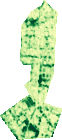
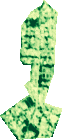
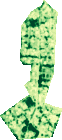
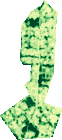

In [6]:
import folium, io, base64, importlib.util
from folium.plugins import HeatMap

if importlib.util.find_spec('rasterio'):
    import rasterio, matplotlib.cm as cm
    from PIL import Image
    HAS_RASTERIO = True
else:
    HAS_RASTERIO = False

centroid = gdf_roo_wgs.geometry.centroid.iloc[0]
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=16,
               tiles='CartoDB positron')

# ── Polígono corredor ─────────────────────────────────────────────────────────
folium.GeoJson(gdf_roo_wgs.__geo_interface__,
    name='Corredor Roosevelt (buffer 100 m)',
    style_function=lambda x: {
        'fillColor':'#2E7D32','color':'#1B4F8A',
        'weight':2.5,'fillOpacity':0.08
    }).add_to(m)

# ── NDVI por año (capas independientes) ───────────────────────────────────────
if HAS_RASTERIO:
    for año_ndvi in [2023, 2024, 2025, 2026]:
        ndvi_tif = DATA_DIR / '5_Entorno_Urbano' / 'NVDI' / f'Roosevelt_ndvi_{año_ndvi}.tif'
        if not ndvi_tif.exists():
            continue
        with rasterio.open(ndvi_tif) as src:
            data   = src.read(1).astype(float)
            bounds = src.bounds
            if src.nodata is not None: data[data == src.nodata] = np.nan
        vmin, vmax_n = -0.1, 0.5
        norm = np.clip((data - vmin) / (vmax_n - vmin), 0, 1)
        rgba = (cm.YlGn(norm) * 255).astype(np.uint8)
        if np.any(np.isnan(data)): rgba[np.isnan(data), 3] = 0
        buf = io.BytesIO()
        Image.fromarray(rgba).save(buf, format='PNG')
        img_b64 = base64.b64encode(buf.getvalue()).decode()
        folium.raster_layers.ImageOverlay(
            image=f'data:image/png;base64,{img_b64}',
            bounds=[[bounds.bottom, bounds.left],[bounds.top, bounds.right]],
            name=f'NDVI {año_ndvi}', opacity=0.65, show=(año_ndvi==2025)
        ).add_to(m)

# ── Árboles (censo DAGMA) ─────────────────────────────────────────────────────
fg_arb = folium.FeatureGroup(name='Arboles (censo DAGMA)', show=False)
for feat in raw_arb['features']:
    geom = feat.get('geometry', {})
    if not geom or not geom.get('coordinates'): continue
    lon, lat = geom['coordinates'][:2]
    p = feat['properties']
    especie = p.get('ESPECIE', p.get('especie', p.get('nombre_com', 'Árbol')))
    folium.CircleMarker([lat, lon], radius=3,
        color='#2E7D32', fill=True, fill_color='#4CAF50', fill_opacity=0.7,
        popup=f'<b>Árbol</b><br>{especie}').add_to(fg_arb)
fg_arb.add_to(m)

# ── Siniestros viales ─────────────────────────────────────────────────────────
fg_sin = folium.FeatureGroup(name='Siniestros viales', show=False)
_color_sin = {'Mortal': 'red', 'Lesiones': 'orange', 'Solo daños': 'gray'}
for feat in raw_sin['features']:
    geom = feat.get('geometry', {})
    if not geom or not geom.get('coordinates'): continue
    lon, lat = geom['coordinates'][:2]
    p = feat['properties']
    tipo  = p.get('Tipo_Confi', 'S/D')
    clase = p.get('Clase_acci', '')
    fecha = str(p.get('Fecha', ''))[:10]
    color = _color_sin.get(tipo, 'gray')
    folium.CircleMarker([lat, lon], radius=5,
        color=color, fill=True, fill_color=color, fill_opacity=0.75,
        popup=f'<b>Siniestro</b><br>Tipo: {tipo}<br>Clase: {clase}<br>Fecha: {fecha}'
    ).add_to(fg_sin)
fg_sin.add_to(m)

# ── Homicidios ────────────────────────────────────────────────────────────────
fg_hom = folium.FeatureGroup(name='Homicidios', show=True)
for feat in raw_hom['features']:
    geom = feat.get('geometry', {})
    if not geom or not geom.get('coordinates'): continue
    lon, lat = geom['coordinates'][:2]
    p = feat['properties']
    folium.Marker([lat, lon],
        popup=f'<b>Homicidio</b><br>{str(p.get("fechah",""))[:10]}',
        icon=folium.Icon(color='red', icon='exclamation-sign', prefix='glyphicon')
    ).add_to(fg_hom)
fg_hom.add_to(m)

# ── VIF ───────────────────────────────────────────────────────────────────────
fg_vif = folium.FeatureGroup(name='VIF', show=True)
for feat in raw_vif['features']:
    geom = feat.get('geometry', {})
    if not geom or not geom.get('coordinates'): continue
    lon, lat = geom['coordinates'][:2]
    p = feat['properties']
    folium.Marker([lat, lon],
        popup=f'<b>VIF</b><br>{str(p.get("fecha_hech",""))[:10]}',
        icon=folium.Icon(color='purple', icon='home', prefix='glyphicon')
    ).add_to(fg_vif)
fg_vif.add_to(m)

# ── Hurtos ────────────────────────────────────────────────────────────────────
fg_hur = folium.FeatureGroup(name='Hurtos (puntos)', show=False)
_heat_hur = []
for feat in raw_hur['features']:
    geom = feat.get('geometry', {})
    if not geom or not geom.get('coordinates'): continue
    lon, lat = geom['coordinates'][:2]
    p = feat['properties']
    folium.CircleMarker([lat, lon], radius=4,
        color='#1565C0', fill=True, fill_color='#1E88E5', fill_opacity=0.6,
        popup=f'Hurto<br>{str(p.get("fecha_hech",""))[:10]}').add_to(fg_hur)
    _heat_hur.append([lat, lon])
fg_hur.add_to(m)

# Heatmap hurtos
if _heat_hur:
    HeatMap(_heat_hur, name='Hurtos (heatmap)', min_opacity=0.3,
            radius=12, blur=8, show=False).add_to(m)

# ── SPA (sustancias psicoactivas) ─────────────────────────────────────────────
fg_spa = folium.FeatureGroup(name='Comparendos SPA', show=False)
for feat in raw_comp['features']:
    p = feat['properties']
    if p.get('agrupado', '') != 'SUSTANCIAS PSICOACTIVAS': continue
    try:
        lat = float(p.get('lat') or p.get('latitude') or 0)
        lon = float(p.get('lon') or p.get('longitude') or 0)
    except: continue
    if lat == 0 and lon == 0: continue
    folium.CircleMarker([lat, lon], radius=4,
        color='#6A1B9A', fill=True, fill_color='#AB47BC', fill_opacity=0.7,
        popup=f'SPA<br>{str(p.get("fecha_hech",""))[:10]}').add_to(fg_spa)
fg_spa.add_to(m)

# ── Negocios (Registro Mercantil) ─────────────────────────────────────────────
fg_neg = folium.FeatureGroup(name='Negocios registrados', show=False)
if 'df_de' in dir():
    for _, row in df_de.iterrows():
        try:
            lat = float(row.get('Y') or row.get('lat') or 0)
            lon = float(row.get('X') or row.get('lon') or 0)
        except: continue
        if lat == 0 and lon == 0: continue
        nombre = str(row.get('razon_soci', row.get('RAZON_SOCI', 'Negocio')))[:40]
        tamano = str(row.get('TAMANO957', ''))
        folium.CircleMarker([lat, lon], radius=3,
            color='#E65100', fill=True, fill_color='#FF8F00', fill_opacity=0.65,
            popup=f'<b>{nombre}</b><br>{tamano}').add_to(fg_neg)
fg_neg.add_to(m)

# ── Sedes educativas ──────────────────────────────────────────────────────────
fg_s = folium.FeatureGroup(name='Sedes educativas', show=False)
for feat in raw_sed['features']:
    p = feat['properties']
    if p.get('Latitud_D'):
        folium.Marker([p['Latitud_D'], p['Longitud_D']],
            popup=f'<b>{p.get("NombreSede","Sede")}</b>',
            icon=folium.Icon(color='cadetblue', icon='education', prefix='glyphicon')
        ).add_to(fg_s)
fg_s.add_to(m)

folium.LayerControl(collapsed=False).add_to(m)
m


In [7]:
def procesar(raw, col_fecha, filtro=None, filtro_col=None, formato_fecha=None, startswith=False):
    df = pd.DataFrame([f['properties'] for f in raw['features']])
    _ng = [col for col in df.columns if col not in ('geom','geometry','the_geom')]
    _b  = len(df)
    df  = df.drop_duplicates(subset=_ng).reset_index(drop=True)
    if _b != len(df): print(f'  [dedup] {_b-len(df)} duplicados removidos ({_b}->{len(df)})')

    if filtro and filtro_col:
        if startswith:
            df = df[df[filtro_col].astype(str).str.startswith(filtro)].copy()
        else:
            df = df[df[filtro_col] == filtro].copy()
    df['_fecha'] = pd.to_datetime(df[col_fecha], format=formato_fecha, errors='coerce')
    df['año']      = df['_fecha'].dt.year
    df['trimestre'] = df['_fecha'].dt.quarter
    return df[df['año'].isin(ANIOS)].copy()

def agg_anual(df): return df.groupby('año').size().reindex(ANIOS, fill_value=0)
def agg_trim(df):
    idx = pd.MultiIndex.from_product([ANIOS,[1,2,3,4]], names=['año','trimestre'])
    return df.groupby(['año','trimestre']).size().reindex(idx, fill_value=0)

df_hom = procesar(raw_hom, 'fechah',      formato_fecha='%m/%d/%Y')
df_hur = procesar(raw_hur, 'fecha_hech')
df_sin = procesar(raw_sin, 'Fecha')
df_les = df_sin[df_sin['Tipo_Confi'] == 'Lesiones'].copy()
df_mor = df_sin[df_sin['Tipo_Confi'] == 'Mortal'].copy()
df_vif = procesar(raw_vif, 'fecha_hech')
df_rin = procesar(raw_comp, 'fecha_hech', filtro='RI', filtro_col='agrupado', startswith=True)

base = pd.DataFrame({'año': ANIOS})
for nombre, df_src in [('homicidios',df_hom),('hurtos',df_hur),('siniestralidad',df_sin),
                        ('lesionados',df_les),('mortales',df_mor),('vif',df_vif),('rinas',df_rin)]:
    base[nombre] = agg_anual(df_src).values

idx_t = pd.MultiIndex.from_product([ANIOS,[1,2,3,4]], names=['año','trimestre'])
corr_trim = pd.DataFrame(index=idx_t).reset_index()
for nombre, df_src in [('homicidios',df_hom),('hurtos',df_hur),('siniestralidad',df_sin),
                        ('lesionados',df_les),('mortales',df_mor),('vif',df_vif),('rinas',df_rin)]:
    ser = agg_trim(df_src).reset_index()
    ser.columns = ['año','trimestre',nombre]
    corr_trim = corr_trim.merge(ser, on=['año','trimestre'], how='left').fillna({nombre:0})
corr_trim['periodo'] = corr_trim['año'].astype(str) + '-Q' + corr_trim['trimestre'].astype(str)

mask_q2plus = (corr_trim['año'] == 2026) & (corr_trim['trimestre'] > 1)
corr_trim.loc[mask_q2plus, ['homicidios','hurtos','vif','rinas']] = np.nan
# Siniestros 2026: tenemos datos hasta Q2 — solo nullificar Q3/Q4
_q_sin_2026 = int(df_sin[df_sin['año']==2026]['trimestre'].nunique()) if len(df_sin[df_sin['año']==2026]) > 0 else 0
mask_sin_fut = (corr_trim['año'] == 2026) & (corr_trim['trimestre'] > _q_sin_2026)
corr_trim.loc[mask_sin_fut, ['siniestralidad','lesionados','mortales']] = np.nan

# Anualizar indicadores Q1-only 2026 (hurtos, vif, rinas) para consistencia
_q_hur_2026 = int(df_hur[df_hur['año']==2026]['trimestre'].nunique()) if len(df_hur[df_hur['año']==2026])>0 else 0
_q_vif_2026 = int(df_vif[df_vif['año']==2026]['trimestre'].nunique()) if len(df_vif[df_vif['año']==2026])>0 else 0
_q_rin_2026 = int(df_rin[df_rin['año']==2026]['trimestre'].nunique()) if len(df_rin[df_rin['año']==2026])>0 else 0
for _ci, _qi in [('hurtos',_q_hur_2026),('vif',_q_vif_2026),('rinas',_q_rin_2026)]:
    if 0 < _qi < 4:
        _vi = base.loc[base['año']==2026, _ci].iloc[0]
        base.loc[base['año']==2026, _ci] = round(_vi * 4 / _qi)
        print(f'  {_ci} 2026: {_qi}T disponibles → anualizado x{4/_qi:.1f} ({int(_vi)}→{round(_vi*4/_qi)})')

# Anualizar siniestros 2026 (proyectar del parcial disponible)
if _q_sin_2026 > 0 and _q_sin_2026 < 4:
    _f_sin = 4 / _q_sin_2026
    for _col_sin in ['siniestralidad','lesionados','mortales']:
        _v = base.loc[base['año']==2026, _col_sin].iloc[0]
        base.loc[base['año']==2026, _col_sin] = round(_v * _f_sin)
    print(f'  Siniestros 2026: {_q_sin_2026}T disponibles → anualizado x{_f_sin:.1f}')

print('Indicadores anuales:')
print(base.to_string(index=False))
print()
print('Indicadores trimestrales (NaN = sin dato):')
print(corr_trim.to_string(index=False))

  hurtos 2026: 1T disponibles → anualizado x4.0 (42→168)
  vif 2026: 1T disponibles → anualizado x4.0 (4→16)
  rinas 2026: 1T disponibles → anualizado x4.0 (4→16)
  Siniestros 2026: 2T disponibles → anualizado x2.0
Indicadores anuales:
 año  homicidios  hurtos  siniestralidad  lesionados  mortales  vif  rinas
2023           2     245              31          26         1    9     12
2024           1     274              17          15         2    9     12
2025           2     209              24          22         1    6     21
2026           0     168              24          24         0   16     16

Indicadores trimestrales (NaN = sin dato):
 año  trimestre  homicidios  hurtos  siniestralidad  lesionados  mortales  vif  rinas periodo
2023          1         1.0    57.0             9.0         7.0       0.0  3.0    2.0 2023-Q1
2023          2         1.0    68.0             8.0         7.0       0.0  2.0    0.0 2023-Q2
2023          3         0.0    64.0             5.0         4.0

In [8]:
def score_ref(valor, ref_min, ref_max, inverso):
    if ref_max == ref_min: return 100.0
    raw = np.clip((valor - ref_min) / (ref_max - ref_min) * 100, 0, 100)
    return 100 - raw if inverso else raw

for ind, (rmin, rmax, inv, desc) in REFS.items():
    if ind in base.columns:
        base[f'score_{ind}'] = base[ind].apply(lambda v: score_ref(v, rmin, rmax, inv))

if 'score_spa' not in base.columns:
    _df_spa = pd.DataFrame([f['properties'] for f in raw_comp['features']])
    _df_spa = _df_spa[_df_spa['agrupado'] == 'SUSTANCIAS PSICOACTIVAS'].copy()
    _df_spa['_fecha'] = pd.to_datetime(_df_spa['fecha_hech'], errors='coerce')
    _df_spa['año']    = _df_spa['_fecha'].dt.year
    _spa_anual = _df_spa.groupby('año').size().reindex(ANIOS, fill_value=0)
    # Anualizar SPA 2026 (solo Q1 disponible)
    _q_spa_2026 = int(_df_spa[_df_spa['año']==2026]['_fecha'].dt.quarter.nunique()) if len(_df_spa[_df_spa['año']==2026])>0 else 0
    if 0 < _q_spa_2026 < 4:
        _spa_anual[2026] = round(_spa_anual[2026] * 4 / _q_spa_2026)
        print(f'  SPA 2026: {_q_spa_2026}T disponibles → anualizado x{4/_q_spa_2026:.1f}')
    base['spa']       = _spa_anual.values
    base['score_spa'] = base['spa'].apply(lambda v: score_ref(v, 0, 200, True))
    print(f'SPA anual: {dict(zip(ANIOS, base["spa"].values))}')

base['score_seguridad'] = (base['score_homicidios'] + base['score_hurtos']) / 2
base['score_movilidad'] = (base['score_siniestralidad'] + base['score_lesionados'] + base['score_mortales']) / 3
base['score_cohesion']  = (base['score_vif'] + base['score_rinas'] + base['score_spa']) / 3
base['score_entorno_u'] = REF_ENTORNO_U
base['score_educ_des']  = REF_EDUC_DES
base['score_des_social'] = (base['score_cohesion'] + base['score_educ_des']) / 2
base['score_des_eco']   = REF_DES_ECO

# Movilidad 2026: se calcula con siniestros anualizados desde roo_proc
# (NaN solo si no hay datos de siniestros en 2026)
if '_q_sin_2026' in dir() and _q_sin_2026 == 0:
    base.loc[base['año'] == 2026, 'score_movilidad'] = np.nan

def _itt_row(row):
    dims = {
        'Seguridad': row.get('score_seguridad', np.nan),
        'Movilidad': row.get('score_movilidad', np.nan),
        'DesSocial': row.get('score_des_social', np.nan),
        'EntornoU':  row.get('score_entorno_u', np.nan),
        'DesEco':    row.get('score_des_eco',   np.nan),
    }
    total_peso = sum(PESOS[k] for k, v in dims.items() if not pd.isna(v))
    if total_peso == 0: return np.nan
    return sum(PESOS[k] * v for k, v in dims.items() if not pd.isna(v)) / total_peso

base['score_des_social'] = (base['score_cohesion'] + base['score_educ_des']) / 2
base['ITT'] = base.apply(_itt_row, axis=1)

def clasificar(v):
    if pd.isna(v): return 'S/D'
    if v < 40:   return 'Activacion'
    elif v < 60: return 'Consolidacion'
    elif v < 80: return 'Transformacion'
    else:        return 'Escala'

base['nivel'] = base['ITT'].apply(clasificar)

print('ITT Roosevelt — Normalizacion provisional | 5 dimensiones')
cols = ['año','score_seguridad','score_movilidad','score_des_social','score_entorno_u','score_des_eco','ITT','nivel']
print(base[cols].round(1).to_string(index=False))

  SPA 2026: 1T disponibles → anualizado x4.0
SPA anual: {2023: np.int64(116), 2024: np.int64(101), 2025: np.int64(161), 2026: np.int64(112)}
ITT Roosevelt — Normalizacion provisional | 5 dimensiones
 año  score_seguridad  score_movilidad  score_des_social  score_entorno_u  score_des_eco  ITT         nivel
2023             58.5             49.4              51.4             39.2           50.0 50.6 Consolidacion
2024             59.0             68.0              52.7             39.2           50.0 55.1 Consolidacion
2025             65.7             61.0              45.9             39.2           50.0 54.0 Consolidacion
2026             86.4             66.9              40.8             39.2           50.0 60.0 Consolidacion


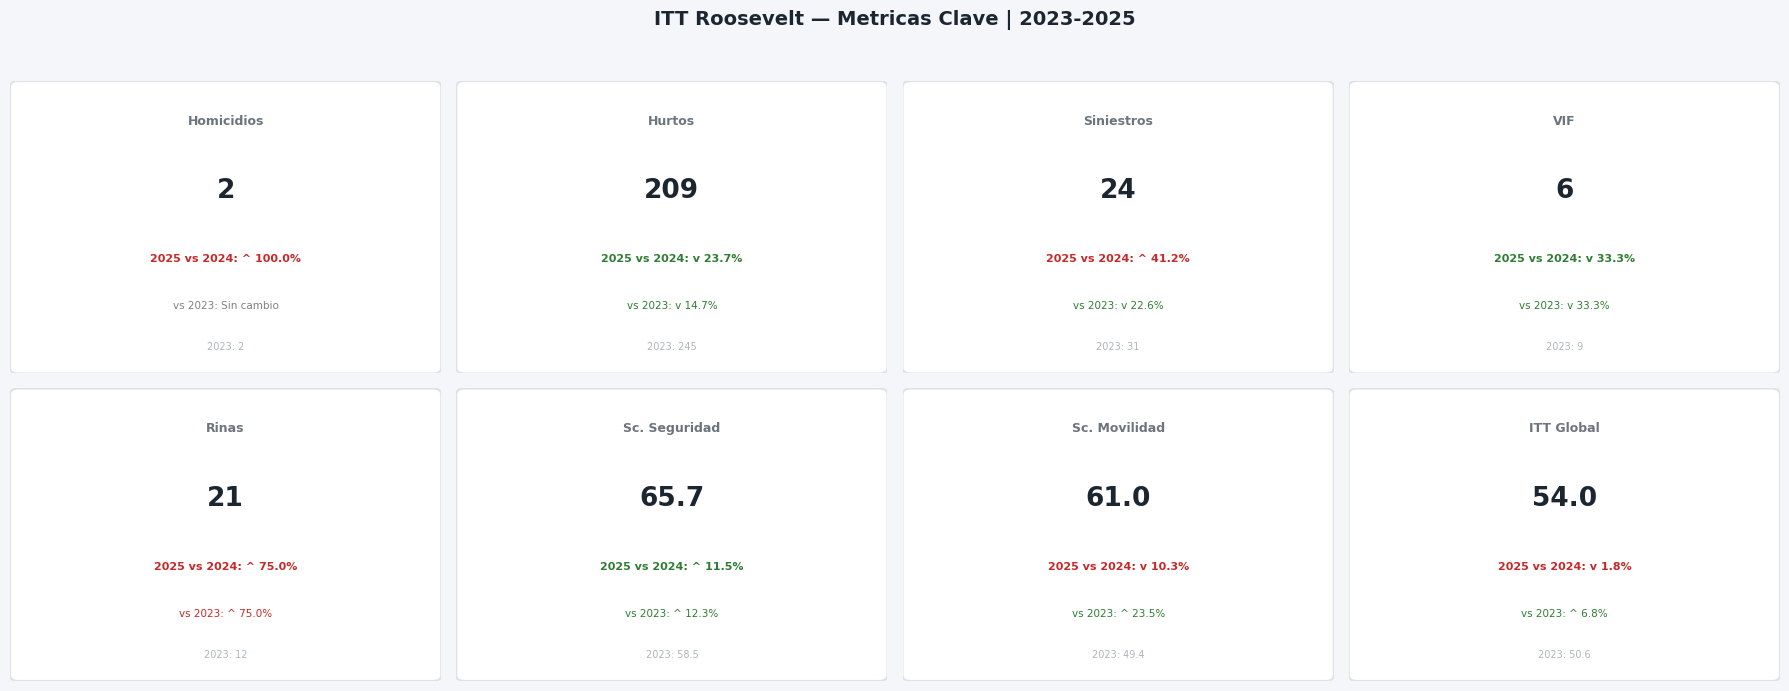

In [9]:
def safe_pct(new, old):
    if old == 0: return 0.0
    return (new - old) / old * 100

def arrow(pct, inv=True):
    if abs(pct) < 1: return 'Sin cambio', 'gray'
    if inv: return (f'v {abs(pct):.1f}%','#2E7D32') if pct<0 else (f'^ {abs(pct):.1f}%','#C62828')
    else:  return (f'^ {abs(pct):.1f}%','#2E7D32') if pct>0 else (f'v {abs(pct):.1f}%','#C62828')

ANIOS_3 = [2023, 2024, 2025]
d_ini = base[base['año']==2023].iloc[0]
d_ant = base[base['año']==2024].iloc[0]
d_ult = base[base['año']==2025].iloc[0]

cards = [
    ('Homicidios',     int(d_ini['homicidios']),    int(d_ant['homicidios']),    int(d_ult['homicidios']),    True),
    ('Hurtos',         int(d_ini['hurtos']),         int(d_ant['hurtos']),         int(d_ult['hurtos']),         True),
    ('Siniestros',     int(d_ini['siniestralidad']), int(d_ant['siniestralidad']), int(d_ult['siniestralidad']), True),
    ('VIF',            int(d_ini['vif']),            int(d_ant['vif']),            int(d_ult['vif']),            True),
    ('Rinas',          int(d_ini['rinas']),          int(d_ant['rinas']),          int(d_ult['rinas']),          True),
    ('Sc. Seguridad',  d_ini['score_seguridad'],     d_ant['score_seguridad'],     d_ult['score_seguridad'],     False),
    ('Sc. Movilidad',  d_ini['score_movilidad'],     d_ant['score_movilidad'],     d_ult['score_movilidad'],     False),
    ('ITT Global',     d_ini['ITT'],                 d_ant['ITT'],                 d_ult['ITT'],                 False),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 7), facecolor=BG)
fig.suptitle(f'ITT Roosevelt — Metricas Clave | 2023-2025',
             fontsize=14, fontweight='bold', color='#1B2631', y=0.98)
for i, (titulo, v_ini, v_ant, v_ult, inv) in enumerate(cards):
    ax = axes[i//4][i%4]; ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    rect = mpatches.FancyBboxPatch((0.02,0.02),0.96,0.96, boxstyle='round,pad=0.02',
        linewidth=1.5, edgecolor='#DEE2E6', facecolor='white')
    ax.add_patch(rect)
    ax.text(0.5,0.85, titulo, ha='center', fontsize=9, color='#6C757D', fontweight='bold')
    val_d = f'{v_ult:.1f}' if isinstance(v_ult,float) else str(v_ult)
    ax.text(0.5,0.60, val_d, ha='center', fontsize=19, fontweight='bold', color='#1B2631')
    pct1 = safe_pct(v_ult, v_ant)
    ar1, col1 = arrow(pct1, inv)
    ax.text(0.5,0.38, f'2025 vs 2024: {ar1}', ha='center', fontsize=8, color=col1, fontweight='bold')
    pct2 = safe_pct(v_ult, v_ini)
    ar2, col2 = arrow(pct2, inv)
    ax.text(0.5,0.22, f'vs 2023: {ar2}', ha='center', fontsize=7.5, color=col2)
    ref = f'{v_ini:.1f}' if isinstance(v_ini,float) else str(v_ini)
    ax.text(0.5,0.08, f'2023: {ref}', ha='center', fontsize=7, color='#ADB5BD')
plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig('itt_roosevelt_cards.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

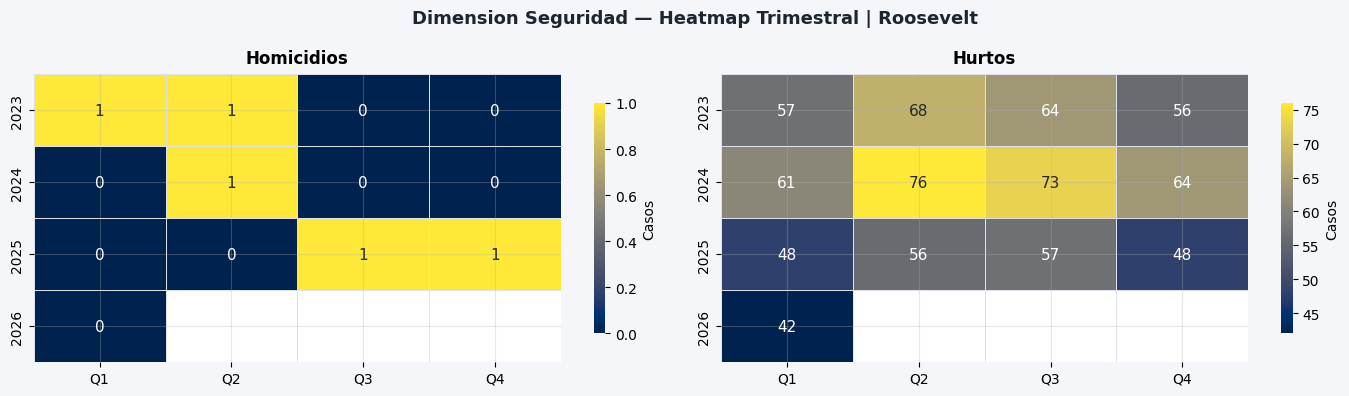

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor=BG)
fig.suptitle('Dimension Seguridad — Heatmap Trimestral | Roosevelt',
             fontsize=13, fontweight='bold', color='#1B2631')
for ax, col, titulo in [(axes[0],'homicidios','Homicidios'),(axes[1],'hurtos','Hurtos')]:
    pivot = corr_trim.pivot(index='año', columns='trimestre', values=col)
    pivot.columns = ['Q1','Q2','Q3','Q4']
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='cividis',
        linewidths=0.5, linecolor='#DEE2E6', ax=ax, annot_kws={'size':11},
        cbar_kws={'label':'Casos','shrink':0.8})
    ax.set_title(titulo, fontweight='bold', pad=8)
    ax.set_ylabel(''); ax.set_xlabel('')
plt.tight_layout()
plt.savefig('itt_roosevelt_heatmap_seg.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

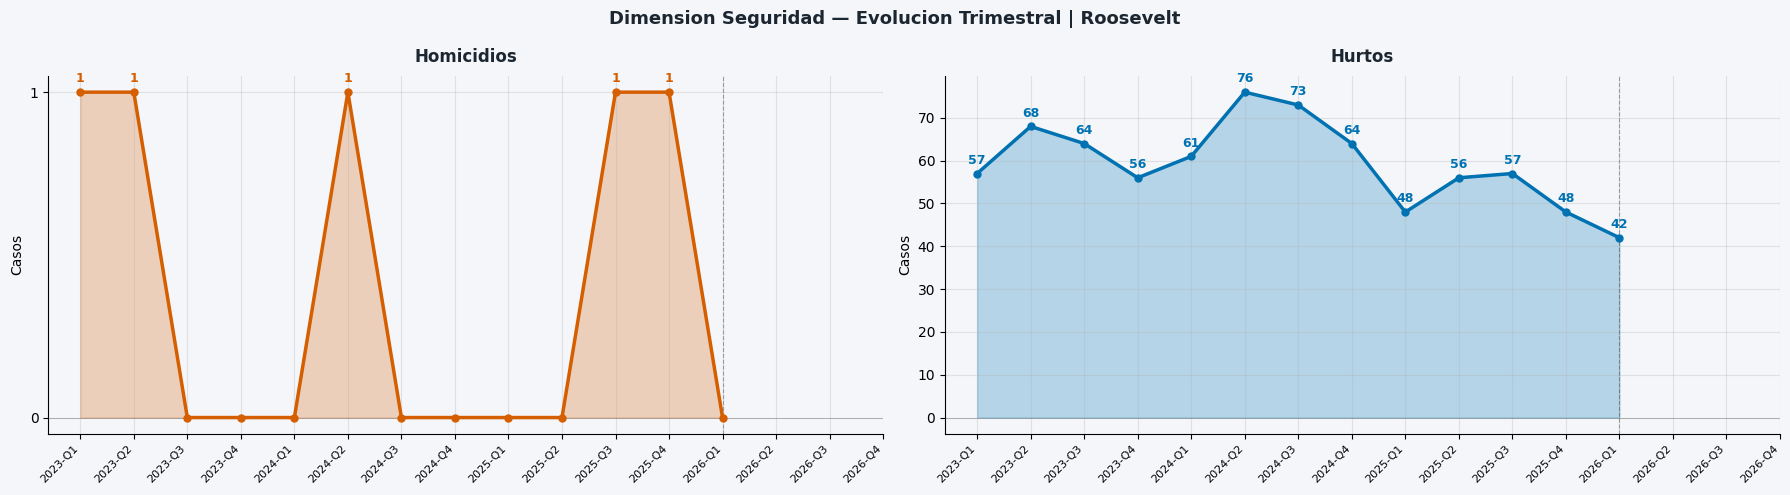

In [11]:
periodos = corr_trim['periodo'].values
x = list(range(len(periodos)))

def plot_linefill(ax, col, titulo, color):
    vals  = corr_trim[col].values.astype(float)
    valid = ~pd.isna(vals)
    ax.fill_between(x, np.where(valid, vals, np.nan), alpha=0.25, color=color)
    ax.plot(x, np.where(valid, vals, np.nan), color=color,
            linewidth=2.5, marker='o', markersize=5, zorder=3)
    for i, v in enumerate(vals):
        if pd.notna(v) and v > 0:
            ax.annotate(str(int(v)), (i, v),
                textcoords='offset points', xytext=(0, 7),
                ha='center', fontsize=9, fontweight='bold', color=color)
    ultimo_valido = max(i for i, v in enumerate(vals) if pd.notna(v))
    ax.axvline(ultimo_valido, color=OKI_GRIS, linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels(periodos, rotation=45, ha='right', fontsize=8)
    ax.set_title(titulo, fontweight='bold', pad=10, color='#1B2631')
    ax.set_ylabel('Casos')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
    ax.set_facecolor(BG)

fig, axes = plt.subplots(1, 2, figsize=(18, 5), facecolor=BG)
fig.suptitle('Dimension Seguridad — Evolucion Trimestral | Roosevelt',
             fontsize=13, fontweight='bold', color='#1B2631')
plot_linefill(axes[0], 'homicidios', 'Homicidios', OKI_BERMELL)
plot_linefill(axes[1], 'hurtos',     'Hurtos',      OKI_AZUL)
plt.tight_layout()
plt.savefig('itt_roosevelt_seg_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

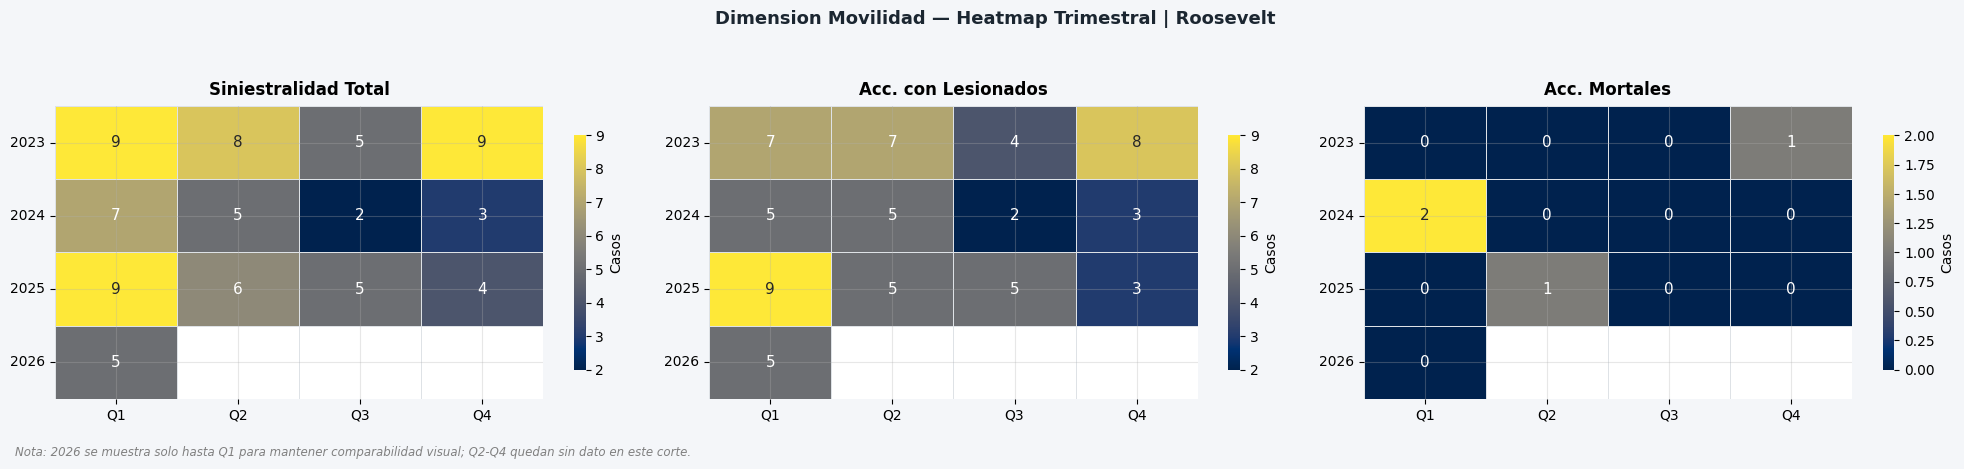

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4.6), facecolor=BG)
fig.suptitle(
    'Dimension Movilidad — Heatmap Trimestral | Roosevelt',
    fontsize=13, fontweight='bold', color='#1B2631'
)

for ax, col, titulo in [
    (axes[0], 'siniestralidad', 'Siniestralidad Total'),
    (axes[1], 'lesionados',     'Acc. con Lesionados'),
    (axes[2], 'mortales',       'Acc. Mortales')
]:
    ct_mov = corr_trim[corr_trim['año'].isin([2023, 2024, 2025, 2026])].copy()

    pivot = ct_mov.pivot(index='año', columns='trimestre', values=col)
    pivot = pivot.reindex(index=[2023, 2024, 2025, 2026], columns=[1, 2, 3, 4])

    # Mostrar 2026 solo hasta Q1
    pivot.loc[2026, [2, 3, 4]] = np.nan

    pivot.columns = ['Q1', 'Q2', 'Q3', 'Q4']
    mask_nan = pivot.isna()

    sns.heatmap(
        pivot,
        annot=True,
        fmt='.0f',
        cmap='cividis',
        linewidths=0.5,
        linecolor='#DEE2E6',
        ax=ax,
        annot_kws={'size': 11},
        cbar_kws={'label': 'Casos', 'shrink': 0.8},
        mask=mask_nan
    )

    ax.set_title(titulo, fontweight='bold', pad=8)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

fig.text(
    0.01, 0.01,
    'Nota: 2026 se muestra solo hasta Q1 para mantener comparabilidad visual; Q2-Q4 quedan sin dato en este corte.',
    fontsize=8.5, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig('itt_roosevelt_heatmap_mov.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


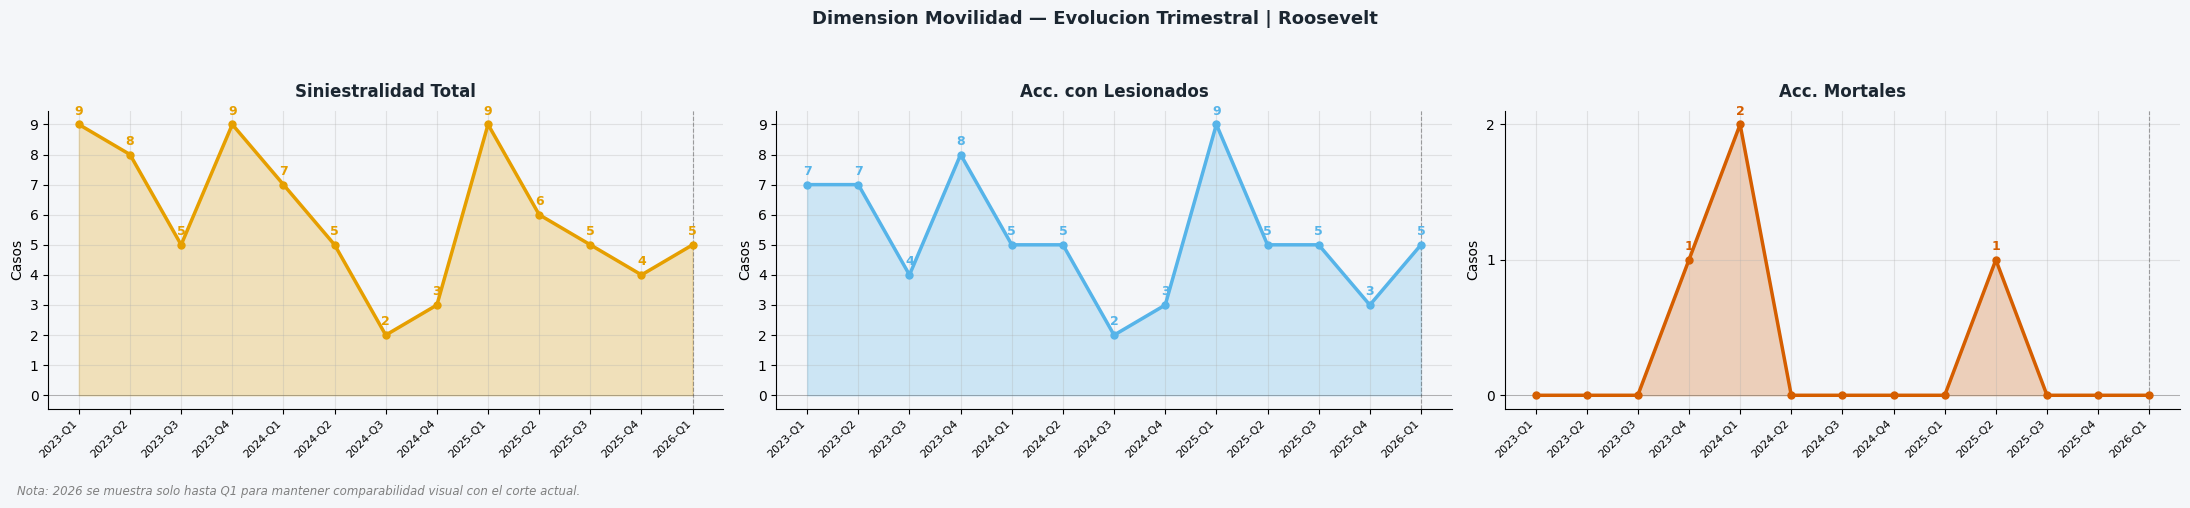

In [13]:
_ct_mov = corr_trim[
    (corr_trim['año'].isin([2023, 2024, 2025])) |
    ((corr_trim['año'] == 2026) & (corr_trim['trimestre'] == 1))
].reset_index(drop=True)

_periodos = _ct_mov['periodo'].tolist()
_x = np.arange(len(_periodos))

fig, axes = plt.subplots(1, 3, figsize=(22, 5), facecolor=BG)
fig.suptitle(
    'Dimension Movilidad — Evolucion Trimestral | Roosevelt',
    fontsize=13, fontweight='bold', color='#1B2631'
)

cfg_mov = [
    (axes[0], 'siniestralidad', 'Siniestralidad Total', OKI_NARANJA),
    (axes[1], 'lesionados',     'Acc. con Lesionados',  OKI_AZUL_C),
    (axes[2], 'mortales',       'Acc. Mortales',        OKI_BERMELL),
]

for ax, col, titulo, color in cfg_mov:
    vals = _ct_mov[col].values.astype(float)
    valid = ~pd.isna(vals)

    ax.fill_between(_x, np.where(valid, vals, np.nan), alpha=0.25, color=color)
    ax.plot(
        _x, np.where(valid, vals, np.nan),
        color=color, linewidth=2.5, marker='o', markersize=5, zorder=3
    )

    for i, v in enumerate(vals):
        if pd.notna(v) and v > 0:
            ax.annotate(
                str(int(v)), (i, v),
                textcoords='offset points', xytext=(0, 7),
                ha='center', fontsize=9, fontweight='bold', color=color
            )

    ultimo = max(i for i, v in enumerate(vals) if pd.notna(v))
    ax.axvline(ultimo, color=OKI_GRIS, linewidth=0.8, linestyle='--', alpha=0.4)

    ax.set_xticks(_x)
    ax.set_xticklabels(_periodos, rotation=45, ha='right', fontsize=8)
    ax.set_title(titulo, fontweight='bold', pad=10, color='#1B2631')
    ax.set_ylabel('Casos')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
    ax.set_facecolor(BG)

fig.text(
    0.01, 0.01,
    'Nota: 2026 se muestra solo hasta Q1 para mantener comparabilidad visual con el corte actual.',
    fontsize=8.5, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig('itt_roosevelt_mov_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


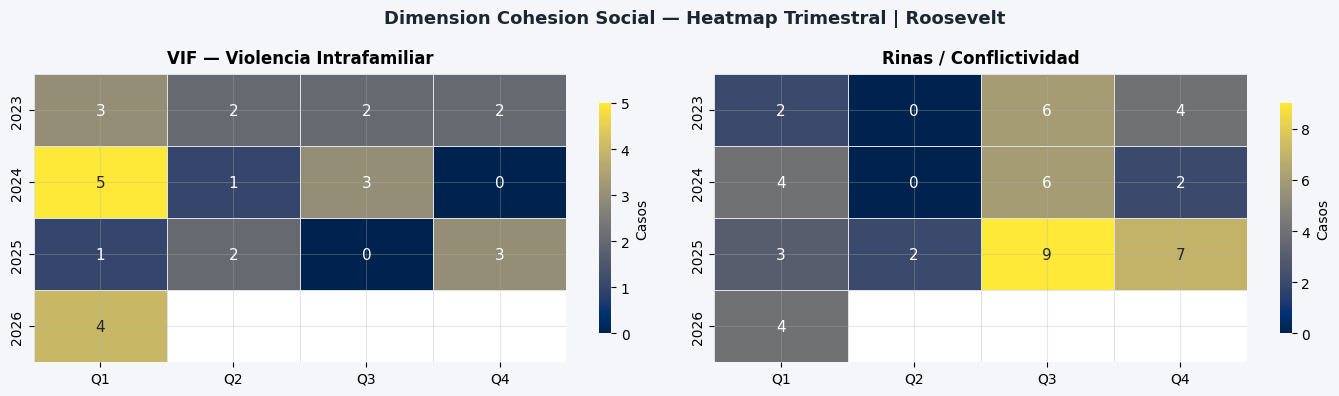

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), facecolor=BG)
fig.suptitle('Dimension Cohesion Social — Heatmap Trimestral | Roosevelt',
             fontsize=13, fontweight='bold', color='#1B2631')
for ax, col, titulo in [
    (axes[0],'vif','VIF — Violencia Intrafamiliar'),
    (axes[1],'rinas','Rinas / Conflictividad')]:
    pivot = corr_trim.pivot(index='año', columns='trimestre', values=col)
    pivot.columns = ['Q1','Q2','Q3','Q4']
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='cividis',
        linewidths=0.5, linecolor='#DEE2E6', ax=ax, annot_kws={'size':11},
        cbar_kws={'label':'Casos','shrink':0.8})
    ax.set_title(titulo, fontweight='bold', pad=8)
    ax.set_ylabel(''); ax.set_xlabel('')
plt.tight_layout()
plt.savefig('itt_roosevelt_heatmap_coh.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

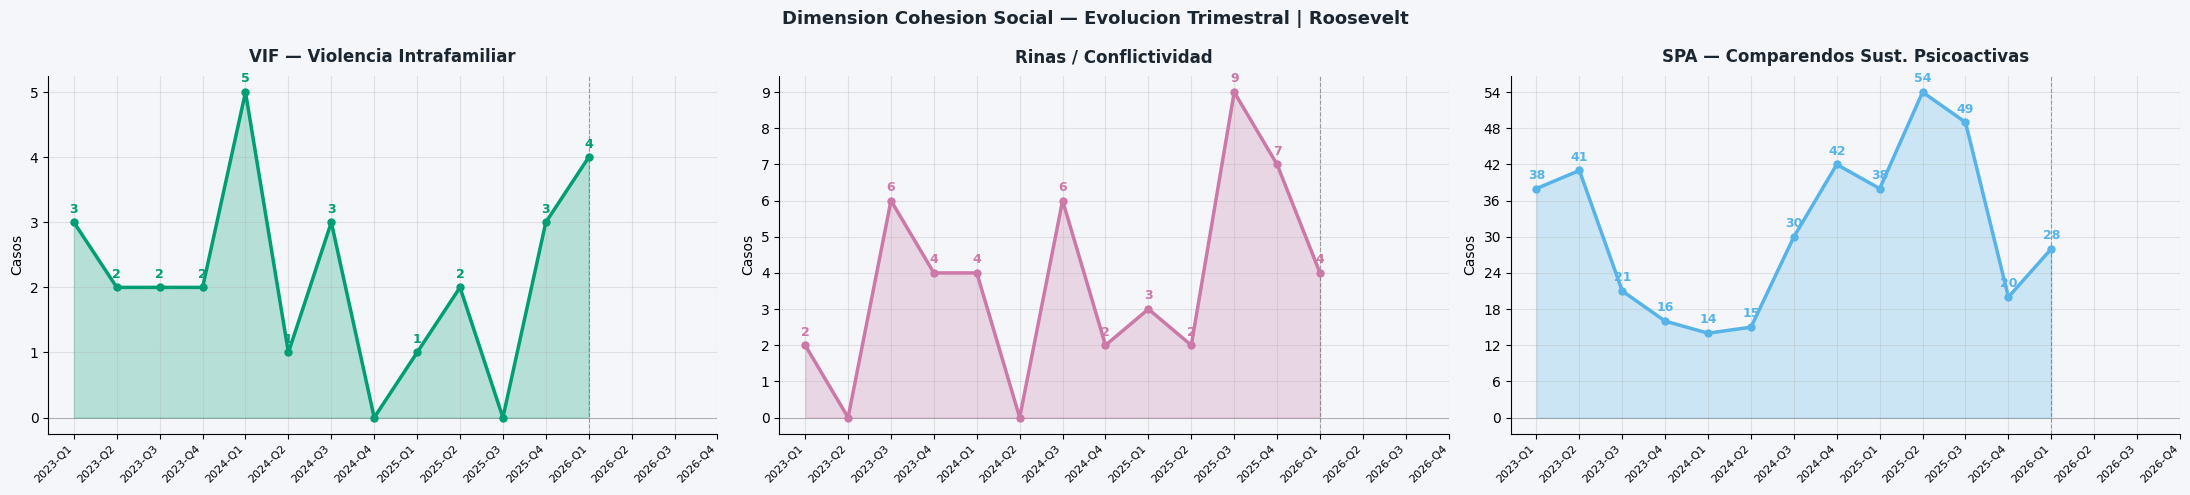

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5), facecolor=BG)
fig.suptitle('Dimension Cohesion Social — Evolucion Trimestral | Roosevelt',
             fontsize=13, fontweight='bold', color='#1B2631')

# SPA trimestral: agregar desde raw_comp si no está en corr_trim
if 'spa' not in corr_trim.columns:
    _df_spa_q = pd.DataFrame([f['properties'] for f in raw_comp['features']])
    _df_spa_q = _df_spa_q[_df_spa_q['agrupado'] == 'SUSTANCIAS PSICOACTIVAS'].copy()
    _df_spa_q['_fecha']    = pd.to_datetime(_df_spa_q['fecha_hech'], errors='coerce')
    _df_spa_q['año']       = _df_spa_q['_fecha'].dt.year
    _df_spa_q['trimestre'] = _df_spa_q['_fecha'].dt.quarter
    _spa_q = _df_spa_q.groupby(['año','trimestre']).size().reset_index(name='spa')
    corr_trim = corr_trim.merge(_spa_q, on=['año','trimestre'], how='left')
    corr_trim['spa'] = corr_trim['spa'].fillna(0)
    mask_q2p = (corr_trim['año'] == 2026) & (corr_trim['trimestre'] > 1)
    corr_trim.loc[mask_q2p, 'spa'] = np.nan

# VIF, Riñas y SPA: timeline completo (plot_linefill definida en roo_ev_seg)
plot_linefill(axes[0], 'vif',   'VIF — Violencia Intrafamiliar',       OKI_VERDE)
plot_linefill(axes[1], 'rinas', 'Rinas / Conflictividad',              OKI_MORADO)
plot_linefill(axes[2], 'spa',   'SPA — Comparendos Sust. Psicoactivas', OKI_AZUL_C)

plt.tight_layout()
plt.savefig('itt_roosevelt_coh_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


Conteo SPA por año y trimestre:
        Q1    Q2    Q3    Q4
año                         
2023  38.0  41.0  21.0  16.0
2024  14.0  15.0  30.0  42.0
2025  38.0  54.0  49.0  20.0
2026  28.0   NaN   NaN   NaN

Total: 406 eventos  |  2023=116  |  2024=101  |  2025=161  |  2026=28


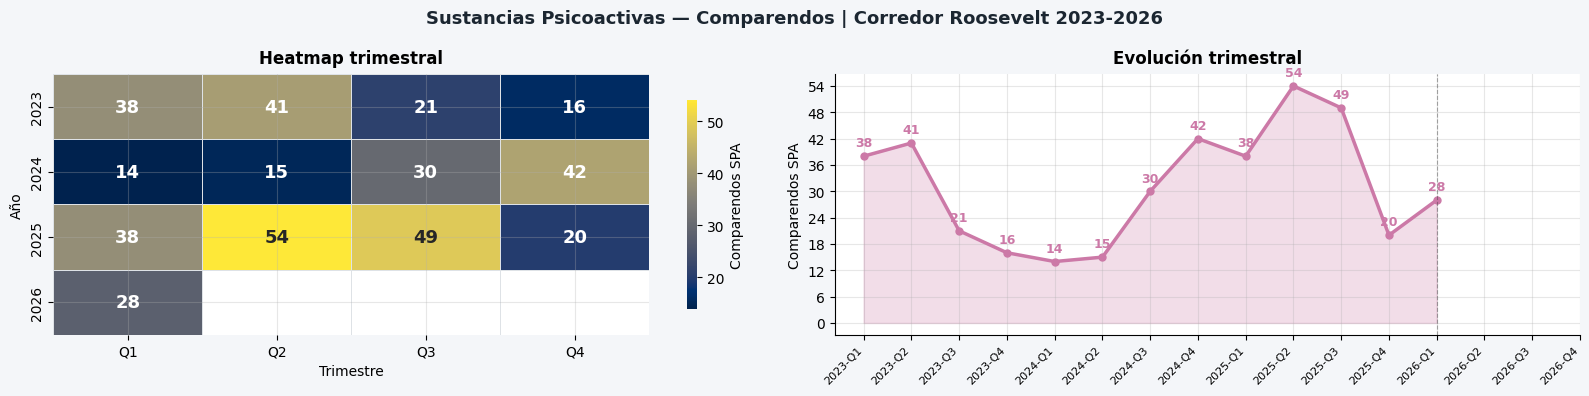


Sitios de ocurrencia:
sitio_hech
SITIOS PÚBLICOS O ABIERTOS AL PÚBLICO    405
MEDIO DE TRANSPORTE                        1


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar SPA desde comparendos ya cargados
df_comp = pd.DataFrame([f['properties'] for f in raw_comp['features']])
df_spa = df_comp[df_comp['agrupado'] == 'SUSTANCIAS PSICOACTIVAS'].copy()
df_spa['_fecha']    = pd.to_datetime(df_spa['fecha_hech'], errors='coerce')
df_spa['año']       = df_spa['_fecha'].dt.year
df_spa['trimestre'] = df_spa['_fecha'].dt.quarter

ANIOS_SPA = [2023, 2024, 2025, 2026]
pivot_spa = (
    df_spa.groupby(['año','trimestre']).size()
    .unstack(fill_value=0)
    .reindex(index=ANIOS_SPA, fill_value=0)
    .reindex(columns=[1,2,3,4], fill_value=0)
    .astype(float)
)
pivot_spa.columns = ['Q1','Q2','Q3','Q4']

# Marcar trimestres sin dato para 2026 dinámicamente
_q_max_spa = int(df_spa[df_spa['año']==2026]['trimestre'].max()) if len(df_spa[df_spa['año']==2026]) > 0 else 0
_cols_nan   = [f'Q{q}' for q in range(_q_max_spa+1, 5)]
if _cols_nan:
    pivot_spa.loc[2026, _cols_nan] = np.nan

print('Conteo SPA por año y trimestre:')
print(pivot_spa.to_string())
totales = {a: pivot_spa.loc[a].sum() for a in ANIOS_SPA}
print(f'\nTotal: {df_spa.shape[0]} eventos  |  ' +
      '  |  '.join(f'{a}={int(totales[a]) if not pd.isna(totales[a]) else "?"}' for a in ANIOS_SPA))

fig, axes = plt.subplots(1, 2, figsize=(16, 4), facecolor=BG)
fig.suptitle('Sustancias Psicoactivas — Comparendos | Corredor Roosevelt 2023-2026',
             fontsize=13, fontweight='bold', color='#1B2631')

# Heatmap
mask_nan = pivot_spa.isna()
sns.heatmap(pivot_spa, annot=True, fmt='.0f', cmap='cividis',
    linewidths=0.5, linecolor='#DEE2E6', ax=axes[0],
    annot_kws={'size': 13, 'weight': 'bold'},
    cbar_kws={'label': 'Comparendos SPA', 'shrink': 0.8},
    mask=mask_nan)
axes[0].set_title('Heatmap trimestral', fontweight='bold', pad=8)
axes[0].set_xlabel('Trimestre'); axes[0].set_ylabel('Año')

# Línea trimestral
periodos_spa = [f'{a}-Q{t}' for a in ANIOS_SPA for t in [1,2,3,4]]
x_spa        = list(range(len(periodos_spa)))
vals_spa     = [pivot_spa.loc[a, f'Q{t}'] for a in ANIOS_SPA for t in [1,2,3,4]]
vals_spa     = [v if not pd.isna(v) else np.nan for v in vals_spa]

axes[1].fill_between(x_spa, vals_spa, alpha=0.25, color=OKI_MORADO)
axes[1].plot(x_spa, vals_spa, color=OKI_MORADO, linewidth=2.5, marker='o', markersize=5)
for i, v in enumerate(vals_spa):
    if pd.notna(v) and v > 0:
        axes[1].annotate(str(int(v)), (i, v),
            textcoords='offset points', xytext=(0, 7),
            ha='center', fontsize=9, fontweight='bold', color=OKI_MORADO)
ultimo_spa = max(i for i, v in enumerate(vals_spa) if pd.notna(v))
axes[1].axvline(ultimo_spa, color=OKI_GRIS, linewidth=0.8, linestyle='--', alpha=0.4)
axes[1].set_xticks(x_spa)
axes[1].set_xticklabels(periodos_spa, rotation=45, ha='right', fontsize=8)
axes[1].set_title('Evolución trimestral', fontweight='bold', pad=8)
axes[1].set_ylabel('Comparendos SPA')
axes[1].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('itt_roosevelt_spa.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('\nSitios de ocurrencia:')
print(df_spa['sitio_hech'].value_counts().to_string())


── Vulnerabilidad activa | Corredor Roosevelt (Sub PyE 2025) ──
  Barrios proxy : EL CEDRO, 3 DE JULIO, EUCARISTICO, BARRIO EUCARISTICO, SAN FERNANDO NUEVO, SAN FERNANDO VIEJO, CHAMPAGNAT
  Personas      : 16  |  Tasa: 5.0/1.000 hab  |  Score: 95.0


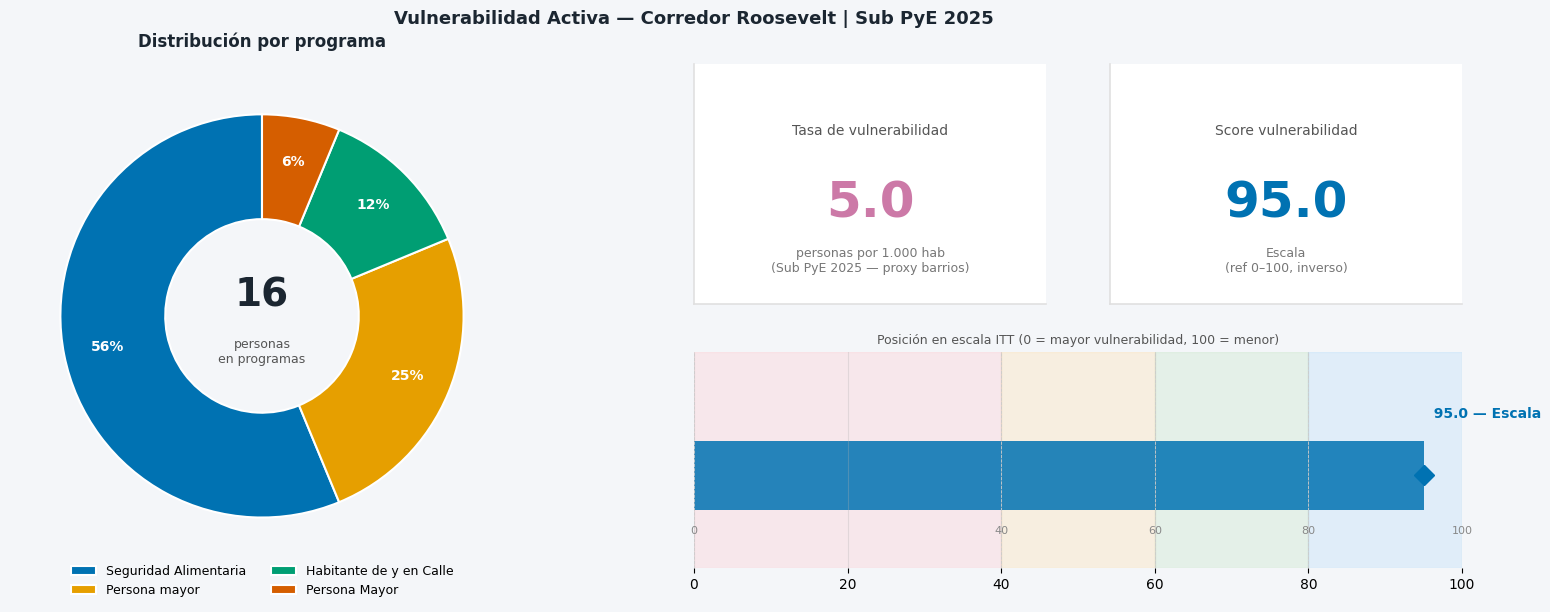

In [17]:
# ── Vulnerabilidad activa: Sub PyE 2025 ─────────────────────────────────────
# PROXY: el corredor Roosevelt (buffer 100 m, ~29.5 ha) atraviesa varios barrios
# de la Comuna 19. Se filtra Sub PyE por los barrios cuya huella se superpone
# mayoritariamente con el polígono. Ajustar la lista si es necesario.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PATH_SUBPYE = str(REPO / 'data' / 'referencia' / 'bienestar' /
                  'Caracterización Personas Sub PyE (2025).xlsx')
COL_BARRIO = "[Barrio de residencia] ¿En cuál barrio reside?"
COL_PROG   = "¿En cuál programa está siendo atendida la persona?"

# Barrios con superposición sobre el corredor Roosevelt (Comuna 19)
# Verificar / ampliar con GIS si es necesario
BARRIOS_ROO = ['EL CEDRO', '3 DE JULIO', 'EUCARISTICO',
               'BARRIO EUCARISTICO', 'SAN FERNANDO NUEVO',
               'SAN FERNANDO VIEJO', 'CHAMPAGNAT']

# Población estimada en el buffer del corredor (100 m × 1641 m ≈ 29.5 ha)
# Proxy: densidad media Comuna 19 (~109 hab/ha) × área buffer
POB_ROOSEVELT = 3200   # ajustar si se dispone de cifra censal más precisa
VULN_REF_MIN  = 0
VULN_REF_MAX  = 100

df_sub   = pd.read_excel(PATH_SUBPYE)
col_barr = df_sub[COL_BARRIO].astype(str).str.upper().str.strip()
mask_roo = col_barr.apply(
    lambda b: any(nb in b for nb in BARRIOS_ROO)
)
df_roo   = df_sub[mask_roo].copy()

n_personas = len(df_roo)
tasa_vuln  = n_personas / POB_ROOSEVELT * 1000
raw        = np.clip((tasa_vuln - VULN_REF_MIN) / (VULN_REF_MAX - VULN_REF_MIN) * 100, 0, 100)
score_vuln = round(100 - raw, 1)
REF_VULNERABILIDAD = score_vuln

print("── Vulnerabilidad activa | Corredor Roosevelt (Sub PyE 2025) ──")
print(f"  Barrios proxy : {', '.join(BARRIOS_ROO)}")
print(f"  Personas      : {n_personas}  |  Tasa: {tasa_vuln:.1f}/1.000 hab  |  Score: {score_vuln}")

# ── Preparar datos donut ──────────────────────────────────────────────────────
progs    = df_roo[COL_PROG].value_counts()
total_p  = progs.sum()
mask_peq = progs / total_p < 0.05
otros_n  = progs[mask_peq].sum()
progs_clean = progs[~mask_peq].copy()
if otros_n > 0:
    progs_clean['Otros'] = otros_n

colores_donut = [OKI_AZUL, OKI_NARANJA, OKI_VERDE, OKI_BERMELL, OKI_MORADO][:len(progs_clean)]

# ── Layout: 1 donut + 2 cards + barra de contexto ────────────────────────────
fig = plt.figure(figsize=(16, 6), facecolor=BG)
fig.suptitle('Vulnerabilidad Activa — Corredor Roosevelt | Sub PyE 2025',
             fontsize=13, fontweight='bold', color='#1B2631', y=1.01)

ax_donut = fig.add_axes([0.02, 0.08, 0.42, 0.84])
ax_card1 = fig.add_axes([0.50, 0.52, 0.22, 0.40])
ax_card2 = fig.add_axes([0.76, 0.52, 0.22, 0.40])
ax_bar   = fig.add_axes([0.50, 0.08, 0.48, 0.36])

# ── Donut ────────────────────────────────────────────────────────────────────
wedges, texts, autotexts = ax_donut.pie(
    progs_clean.values,
    labels=None,
    autopct='%1.0f%%',
    colors=colores_donut,
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight('bold'); at.set_color('white')
ax_donut.legend(
    wedges, progs_clean.index,
    loc='lower center', bbox_to_anchor=(0.5, -0.08),
    ncol=2, fontsize=9, frameon=False
)
ax_donut.text(0, 0.1, str(n_personas), ha='center', va='center',
              fontsize=28, fontweight='bold', color='#1B2631')
ax_donut.text(0, -0.18, 'personas\nen programas', ha='center', va='center',
              fontsize=9, color='#555555')
ax_donut.set_title('Distribución por programa', fontweight='bold',
                   color='#1B2631', pad=12)

# ── Cards ─────────────────────────────────────────────────────────────────────
for ax_c in [ax_card1, ax_card2]:
    ax_c.set_facecolor('white')
    ax_c.set_xticks([]); ax_c.set_yticks([])
    for spine in ax_c.spines.values():
        spine.set_edgecolor('#E0E0E0'); spine.set_linewidth(1.2)

ax_card1.text(0.5, 0.72, 'Tasa de vulnerabilidad',
              ha='center', va='center', fontsize=10, color='#555555',
              transform=ax_card1.transAxes)
ax_card1.text(0.5, 0.42, f'{tasa_vuln:.1f}',
              ha='center', va='center', fontsize=36, fontweight='bold',
              color=OKI_MORADO, transform=ax_card1.transAxes)
ax_card1.text(0.5, 0.18, 'personas por 1.000 hab\n(Sub PyE 2025 — proxy barrios)',
              ha='center', va='center', fontsize=9, color='#777777',
              transform=ax_card1.transAxes)

nivel_color = (OKI_BERMELL if score_vuln < 40 else
               OKI_NARANJA if score_vuln < 60 else
               OKI_VERDE   if score_vuln < 80 else OKI_AZUL)
nivel_lbl   = ('Activación'    if score_vuln < 40 else
               'Consolidación' if score_vuln < 60 else
               'Transformación' if score_vuln < 80 else 'Escala')

ax_card2.text(0.5, 0.72, 'Score vulnerabilidad',
              ha='center', va='center', fontsize=10, color='#555555',
              transform=ax_card2.transAxes)
ax_card2.text(0.5, 0.42, f'{score_vuln}',
              ha='center', va='center', fontsize=36, fontweight='bold',
              color=nivel_color, transform=ax_card2.transAxes)
ax_card2.text(0.5, 0.18, f'{nivel_lbl}\n(ref 0–100, inverso)',
              ha='center', va='center', fontsize=9, color='#777777',
              transform=ax_card2.transAxes)

# ── Barra de contexto ─────────────────────────────────────────────────────────
ax_bar.set_facecolor(BG)
for spine in ax_bar.spines.values(): spine.set_visible(False)
for x0, x1, c in [(0,40,'#FFCDD2'),(40,60,'#FFE0B2'),(60,80,'#C8E6C9'),(80,100,'#BBDEFB')]:
    ax_bar.axvspan(x0, x1, alpha=0.35, color=c)
ax_bar.barh([0], [score_vuln], color=nivel_color, alpha=0.85, height=0.45)
ax_bar.plot(score_vuln, 0, marker='D', ms=10, color=nivel_color, zorder=5)
ax_bar.text(score_vuln, 0.35, f'  {score_vuln} — {nivel_lbl}',
            va='bottom', fontsize=10, fontweight='bold', color=nivel_color)
for x, lbl in [(0,'0'),(40,'40'),(60,'60'),(80,'80'),(100,'100')]:
    ax_bar.axvline(x, color='#CCCCCC', linewidth=0.6, linestyle='--')
    ax_bar.text(x, -0.38, lbl, ha='center', fontsize=8, color='#888888')
ax_bar.set_xlim(0, 100); ax_bar.set_ylim(-0.6, 0.8)
ax_bar.set_yticks([])
ax_bar.set_title('Posición en escala ITT (0 = mayor vulnerabilidad, 100 = menor)',
                 fontsize=9, color='#555555', pad=6)

plt.savefig('itt_roosevelt_vulnerabilidad.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()

## Dimension Entorno Urbano — Corredor Roosevelt

Calcula el score de Entorno Urbano desde dos indicadores con datos reales del buffer 100 m:

- **NDVI / Area verde** (rasters TIF 2023-2026): % del corredor con NDVI >= 0.20.
- **Arboles** (CENSO_ARBOREO DAGMA): densidad arb/ha estatica 2025.

Composite: 50% score area verde + 50% score arboles. Reemplaza `REF_ENTORNO_U = 39.2` en `base`.
Umbrales: area_verde [0-30%], arboles [0-50 arb/ha] — mismos que Barrio Obrero.

In [18]:
import subprocess, importlib.util
if importlib.util.find_spec('rasterio') is None:
    subprocess.run(['pip','install','rasterio','-q'], check=False)
import rasterio

NDVI_DIR    = DATA_DIR / '5_Entorno_Urbano' / 'NVDI'
NDVI_UMBRAL = 0.20
ARBOLES_N   = len(raw_arb['features'])

ndvi_stats = {}
AREA_HA    = None

for año in ANIOS:
    tif = NDVI_DIR / f'Roosevelt_ndvi_{año}.tif'
    if not tif.exists():
        print(f'  {año}: raster no encontrado — {tif.name}')
        ndvi_stats[año] = {'ndvi_mean': np.nan, 'verde_m2': np.nan, 'pct_verde': np.nan}
        continue
    with rasterio.open(tif) as src:
        data = src.read(1).astype(float)
        if src.nodata is not None: data[data == src.nodata] = np.nan
        px_lon_m = abs(src.transform.a) * 111320 * np.cos(np.radians(3.44))
        px_lat_m = abs(src.transform.e) * 110540
        px_area  = px_lon_m * px_lat_m
        total_px  = int(np.sum(~np.isnan(data)))
        verde_px  = int(np.sum(data >= NDVI_UMBRAL))
        ndvi_mean = round(float(np.nanmean(data)), 4)
        verde_m2  = round(verde_px * px_area)
        total_m2  = round(total_px * px_area)
        pct_verde = round(verde_px / total_px * 100, 1) if total_px > 0 else 0
        ndvi_stats[año] = {'ndvi_mean': ndvi_mean, 'verde_m2': verde_m2,
                           'pct_verde': pct_verde, 'total_m2': total_m2}
        if AREA_HA is None: AREA_HA = round(total_m2 / 10000, 2)
    print(f'{año}: NDVI_medio={ndvi_mean}  |  area_verde={verde_m2} m2 ({pct_verde}%)')

dens_arboles_ha = round(ARBOLES_N / AREA_HA, 1) if AREA_HA else np.nan
print(f'\nArboles: {ARBOLES_N}  |  Area corredor: {AREA_HA} ha  |  Densidad: {dens_arboles_ha} arb/ha')

2023: NDVI_medio=0.1282  |  area_verde=99914 m2 (22.2%)
2024: NDVI_medio=0.1727  |  area_verde=144221 m2 (32.1%)
2025: NDVI_medio=0.1704  |  area_verde=138274 m2 (30.8%)
2026: NDVI_medio=0.1637  |  area_verde=131435 m2 (29.2%)

Arboles: 1776  |  Area corredor: 44.96 ha  |  Densidad: 39.5 arb/ha


In [19]:
REF_VERDE_MIN,   REF_VERDE_MAX   = 0, 30
REF_ARBOLES_MIN, REF_ARBOLES_MAX = 0, 50

score_arboles_fijo = round(score_ref(dens_arboles_ha, REF_ARBOLES_MIN, REF_ARBOLES_MAX, False), 1)
print(f'Score arboles (estatico): {score_arboles_fijo}  ({dens_arboles_ha} arb/ha, ref 0-50)')

rows_eu = []
for año in ANIOS:
    st  = ndvi_stats.get(año, {})
    pct = st.get('pct_verde', np.nan)
    sc_verde = score_ref(pct, REF_VERDE_MIN, REF_VERDE_MAX, False) if not np.isnan(pct) else np.nan
    sc_eu    = round((sc_verde + score_arboles_fijo) / 2, 1) if not np.isnan(sc_verde) else score_arboles_fijo
    rows_eu.append(dict(
        año=año, ndvi_mean=st.get('ndvi_mean',np.nan), pct_verde=pct,
        verde_m2=st.get('verde_m2',np.nan), score_verde=sc_verde,
        score_arboles=score_arboles_fijo, score_entorno_u=sc_eu))

df_eu = pd.DataFrame(rows_eu)

print()
print('Entorno Urbano: indicadores y scores')
print(df_eu[['año','ndvi_mean','pct_verde','verde_m2','score_verde','score_arboles','score_entorno_u']].round(2).to_string(index=False))

for _, row in df_eu.iterrows():
    base.loc[base['año'] == int(row['año']), 'score_entorno_u'] = row['score_entorno_u']

FUENTE_ENTORNO_U = 'NDVI real + arboles DAGMA (Corredor Roosevelt)'

base['ITT'] = base.apply(_itt_row, axis=1)
base['nivel'] = base['ITT'].apply(clasificar)
print()
print('ITT actualizado — EntornoU real:')
print(base[['año','score_entorno_u','ITT','nivel']].round(1).to_string(index=False))

Score arboles (estatico): 79.0  (39.5 arb/ha, ref 0-50)

Entorno Urbano: indicadores y scores
 año  ndvi_mean  pct_verde  verde_m2  score_verde  score_arboles  score_entorno_u
2023       0.13       22.2     99914        74.00           79.0             76.5
2024       0.17       32.1    144221       100.00           79.0             89.5
2025       0.17       30.8    138274       100.00           79.0             89.5
2026       0.16       29.2    131435        97.33           79.0             88.2

ITT actualizado — EntornoU real:
 año  score_entorno_u  ITT          nivel
2023             76.5 57.0  Consolidacion
2024             89.5 63.6 Transformacion
2025             89.5 62.6 Transformacion
2026             88.2 68.3 Transformacion


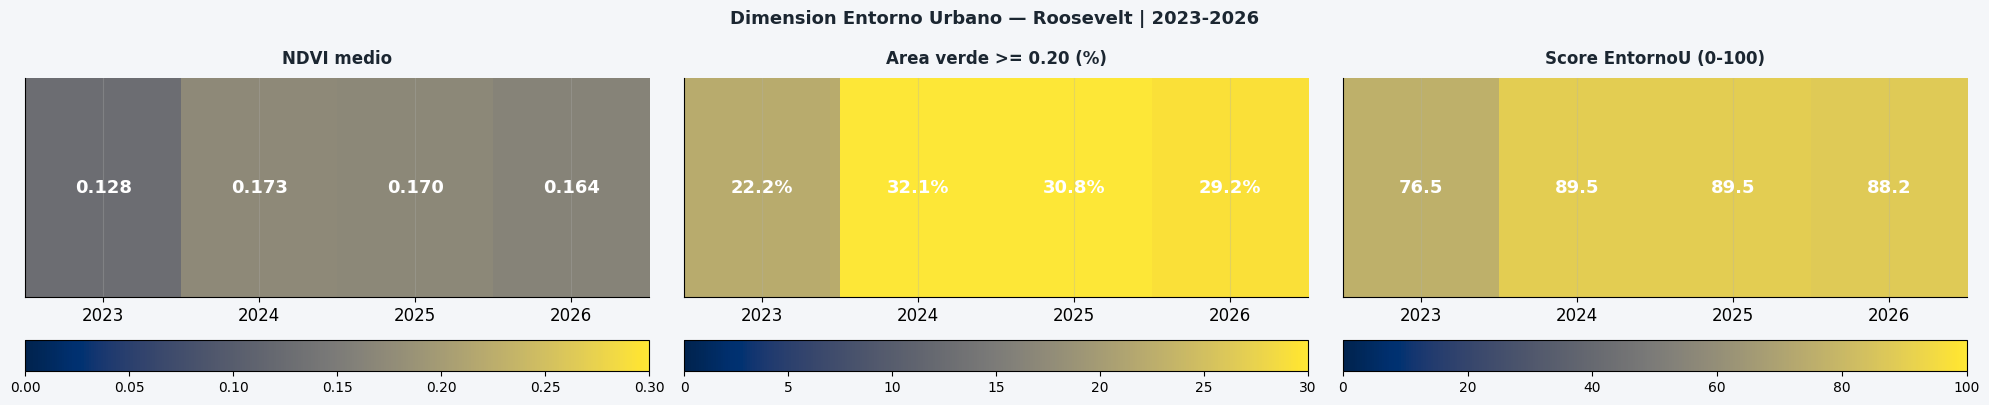

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4), facecolor=BG)
fig.suptitle('Dimension Entorno Urbano — Roosevelt | 2023-2026',
             fontsize=13, fontweight='bold', color='#1B2631')

df_e = df_eu.set_index('año').reindex(ANIOS)
configs_hm = [
    ('ndvi_mean',       'NDVI medio',            'cividis', 0,   0.30, ''),
    ('pct_verde',       'Area verde >= 0.20 (%)', 'cividis', 0,   30,  '%'),
    ('score_entorno_u', 'Score EntornoU (0-100)', 'cividis', 0,  100,  ''),
]
for ax, (col, titulo, cmap, vmin, vmax, sfx) in zip(axes, configs_hm):
    vals = df_e[col].values.astype(float).reshape(1, -1)
    im = ax.imshow(vals, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(ANIOS))); ax.set_xticklabels(ANIOS, fontsize=12)
    ax.set_yticks([])
    ax.set_title(titulo, fontweight='bold', pad=10, color='#1B2631')
    for j, v in enumerate(vals[0]):
        fmt = f'{v:.3f}' if col == 'ndvi_mean' else f'{v:.1f}{sfx}'
        txt = fmt if not np.isnan(v) else 'S/D'
        ax.text(j, 0, txt, ha='center', va='center', fontsize=13, fontweight='bold', color='white')
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.14)
plt.tight_layout()
plt.savefig('itt_roosevelt_entorno_heatmap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

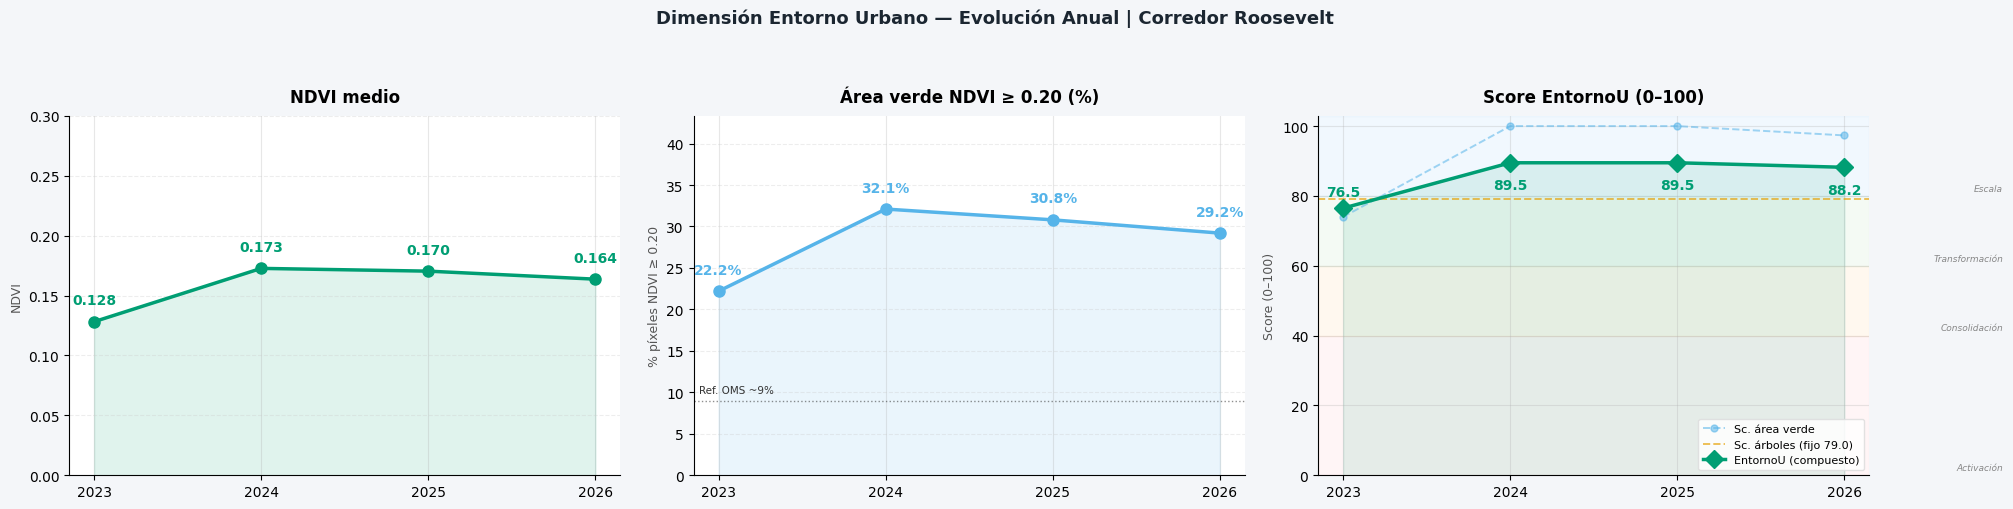

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor=BG)
fig.suptitle('Dimensión Entorno Urbano — Evolución Anual | Corredor Roosevelt',
             fontsize=13, fontweight='bold', color='#1B2631', y=1.01)

df_e = df_eu.set_index('año').reindex(ANIOS)
x    = list(range(len(ANIOS)))
xlbls = [str(a) for a in ANIOS]

# ── Panel 1: NDVI medio ───────────────────────────────────────────────────────
ax = axes[0]; ax.set_facecolor('white')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.35, color='#CCCCCC')

vals = df_e['ndvi_mean'].values.astype(float)
vmax_real = float(np.nanmax(vals)) if not np.all(np.isnan(vals)) else 0.25
ymax = max(0.30, vmax_real * 1.30)

ax.fill_between(x, vals, alpha=0.12, color=OKI_VERDE)
ax.plot(x, vals, color=OKI_VERDE, linewidth=2.5, marker='o', markersize=8, zorder=3)
for xi, v in zip(x, vals):
    if np.isnan(v): continue
    offset = -ymax * 0.07 if v > ymax * 0.82 else ymax * 0.04
    va = 'top' if offset < 0 else 'bottom'
    ax.text(xi, v + offset, f'{v:.3f}', ha='center', va=va,
            fontsize=10, fontweight='bold', color=OKI_VERDE)
ax.set_xticks(x); ax.set_xticklabels(xlbls)
ax.set_ylim(0, ymax)
ax.set_ylabel('NDVI', fontsize=9, color='#555555')
ax.set_title('NDVI medio', fontweight='bold', pad=10)

# ── Panel 2: % área verde ─────────────────────────────────────────────────────
ax = axes[1]; ax.set_facecolor('white')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.35, color='#CCCCCC')

vals = df_e['pct_verde'].values.astype(float)
vmax_real = float(np.nanmax(vals)) if not np.all(np.isnan(vals)) else 15
ymax = max(15, vmax_real * 1.35)

ax.fill_between(x, vals, alpha=0.12, color=OKI_AZUL_C)
ax.plot(x, vals, color=OKI_AZUL_C, linewidth=2.5, marker='o', markersize=8, zorder=3)

# Ref OMS — siempre debajo de los datos
ax.axhline(9, color=OKI_GRIS, linewidth=1, linestyle=':', alpha=0.55)
ax.text(0.01, 9 + ymax * 0.02, 'Ref. OMS ~9%',
        fontsize=7.5, color=OKI_GRIS, transform=ax.get_yaxis_transform())

for xi, v in zip(x, vals):
    if np.isnan(v): continue
    offset = -ymax * 0.07 if v > ymax * 0.82 else ymax * 0.04
    va = 'top' if offset < 0 else 'bottom'
    ax.text(xi, v + offset, f'{v:.1f}%', ha='center', va=va,
            fontsize=10, fontweight='bold', color=OKI_AZUL_C)
ax.set_xticks(x); ax.set_xticklabels(xlbls)
ax.set_ylim(0, ymax)
ax.set_ylabel('% píxeles NDVI ≥ 0.20', fontsize=9, color='#555555')
ax.set_title('Área verde NDVI ≥ 0.20 (%)', fontweight='bold', pad=10)

# ── Panel 3: Score EntornoU ───────────────────────────────────────────────────
ax = axes[2]; ax.set_facecolor('white')
for sp in ['top','right']: ax.spines[sp].set_visible(False)

sc_eu = df_e['score_entorno_u'].values.astype(float)
sc_v  = df_e['score_verde'].values.astype(float)

vmax_real = float(np.nanmax(sc_eu)) if not np.all(np.isnan(sc_eu)) else 80
ymax = min(105, max(85, vmax_real * 1.15))

# Bandas de nivel ITT
for y0, y1, color, lbl in [
    (0,  40, '#FFCDD2', 'Activación'),
    (40, 60, '#FFE0B2', 'Consolidación'),
    (60, 80, '#C8E6C9', 'Transformación'),
    (80, 105,'#BBDEFB', 'Escala'),
]:
    ax.axhspan(y0, min(y1, ymax), alpha=0.20, color=color)
    if y0 < ymax:
        ax.text(len(x) - 0.05, min(y0 + 1.5, ymax - 2), lbl,
                ha='right', fontsize=6.5, color='#888888', style='italic')

# Score área verde (referencia secundaria)
ax.plot(x, sc_v, color=OKI_AZUL_C, linewidth=1.4, linestyle='--',
        marker='o', markersize=5, alpha=0.55, label=f'Sc. área verde')

# Línea árboles fija
ax.axhline(score_arboles_fijo, color=OKI_NARANJA, linewidth=1.4,
           linestyle='--', alpha=0.65,
           label=f'Sc. árboles (fijo {score_arboles_fijo})')

# Score EntornoU compuesto
ax.fill_between(x, sc_eu, alpha=0.10, color=OKI_VERDE)
ax.plot(x, sc_eu, color=OKI_VERDE, linewidth=2.5, marker='D',
        markersize=9, label='EntornoU (compuesto)', zorder=3)

for xi, v in zip(x, sc_eu):
    if np.isnan(v): continue
    offset = -4.5 if v > ymax * 0.84 else 2.5
    va = 'top' if offset < 0 else 'bottom'
    ax.text(xi, v + offset, f'{v:.1f}', ha='center', va=va,
            fontsize=10, fontweight='bold', color=OKI_VERDE)

ax.set_xticks(x); ax.set_xticklabels(xlbls)
ax.set_ylim(0, ymax)
ax.set_ylabel('Score (0–100)', fontsize=9, color='#555555')
ax.set_title('Score EntornoU (0–100)', fontweight='bold', pad=10)
ax.legend(fontsize=8, frameon=True, framealpha=0.85,
          loc='lower right', edgecolor='#DDDDDD')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('itt_roosevelt_entorno_evol.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()


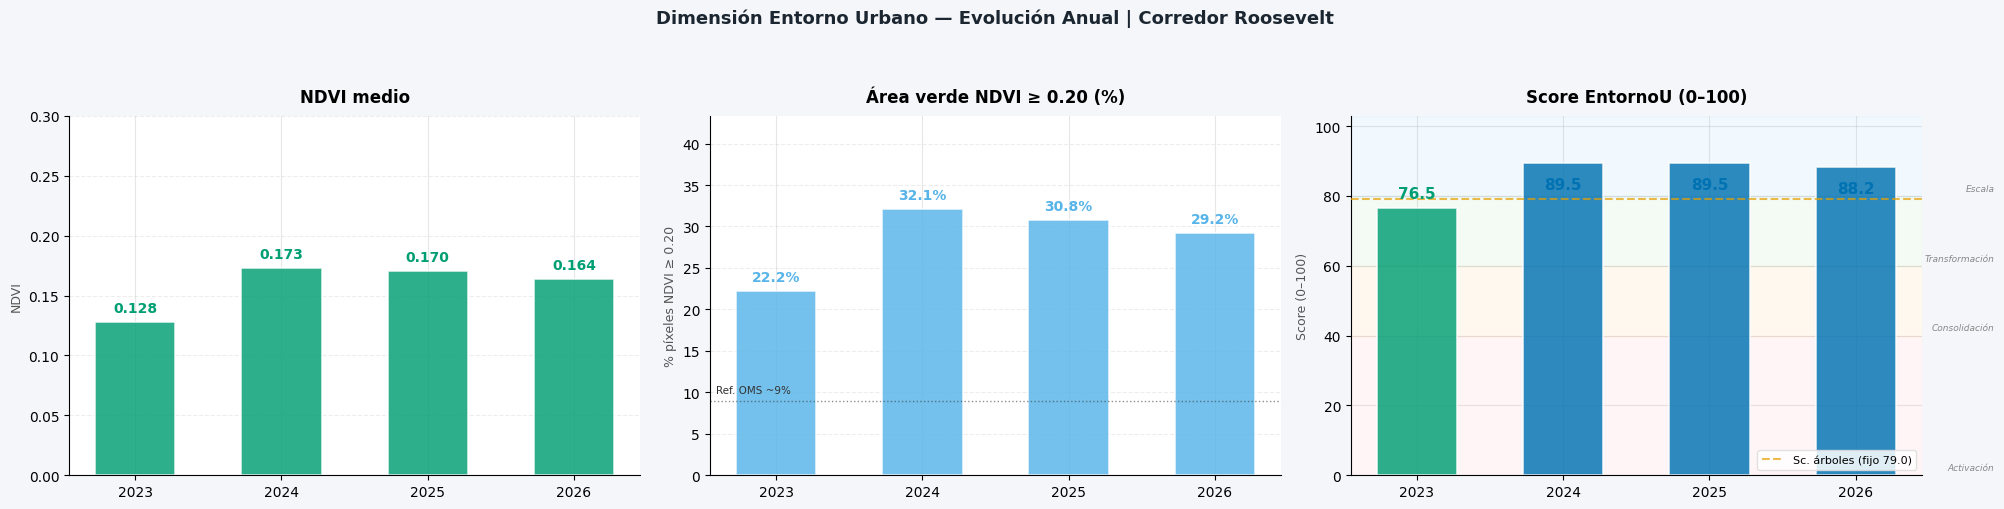

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor=BG)
fig.suptitle('Dimensión Entorno Urbano — Evolución Anual | Corredor Roosevelt',
             fontsize=13, fontweight='bold', color='#1B2631', y=1.01)

df_e  = df_eu.set_index('año').reindex(ANIOS)
x     = list(range(len(ANIOS)))
xlbls = [str(a) for a in ANIOS]
ancho = 0.55

# ── Panel 1: NDVI medio ───────────────────────────────────────────────────────
ax = axes[0]; ax.set_facecolor('white')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.35, color='#CCCCCC', zorder=0)

vals  = df_e['ndvi_mean'].values.astype(float)
vmax_real = float(np.nanmax(vals)) if not np.all(np.isnan(vals)) else 0.25
ymax  = max(0.30, vmax_real * 1.35)
colores = [OKI_VERDE if not np.isnan(v) else '#CCCCCC' for v in vals]

bars = ax.bar(x, np.nan_to_num(vals), width=ancho, color=colores,
              alpha=0.82, edgecolor='white', linewidth=1.2, zorder=2)
for xi, v in zip(x, vals):
    if np.isnan(v): continue
    ax.text(xi, v + ymax * 0.02, f'{v:.3f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=OKI_VERDE)
ax.set_xticks(x); ax.set_xticklabels(xlbls)
ax.set_ylim(0, ymax)
ax.set_ylabel('NDVI', fontsize=9, color='#555555')
ax.set_title('NDVI medio', fontweight='bold', pad=10)

# ── Panel 2: % área verde ─────────────────────────────────────────────────────
ax = axes[1]; ax.set_facecolor('white')
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.35, color='#CCCCCC', zorder=0)

vals  = df_e['pct_verde'].values.astype(float)
vmax_real = float(np.nanmax(vals)) if not np.all(np.isnan(vals)) else 15
ymax  = max(15, vmax_real * 1.35)
colores = [OKI_AZUL_C if not np.isnan(v) else '#CCCCCC' for v in vals]

bars = ax.bar(x, np.nan_to_num(vals), width=ancho, color=colores,
              alpha=0.82, edgecolor='white', linewidth=1.2, zorder=2)
ax.axhline(9, color=OKI_GRIS, linewidth=1, linestyle=':', alpha=0.55, zorder=3)
ax.text(0.01, 9 + ymax * 0.02, 'Ref. OMS ~9%',
        fontsize=7.5, color=OKI_GRIS, transform=ax.get_yaxis_transform())
for xi, v in zip(x, vals):
    if np.isnan(v): continue
    ax.text(xi, v + ymax * 0.02, f'{v:.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=OKI_AZUL_C)
ax.set_xticks(x); ax.set_xticklabels(xlbls)
ax.set_ylim(0, ymax)
ax.set_ylabel('% píxeles NDVI ≥ 0.20', fontsize=9, color='#555555')
ax.set_title('Área verde NDVI ≥ 0.20 (%)', fontweight='bold', pad=10)

# ── Panel 3: Score EntornoU ───────────────────────────────────────────────────
ax = axes[2]; ax.set_facecolor('white')
for sp in ['top','right']: ax.spines[sp].set_visible(False)

sc_eu = df_e['score_entorno_u'].values.astype(float)
vmax_real = float(np.nanmax(sc_eu)) if not np.all(np.isnan(sc_eu)) else 80
ymax  = min(105, max(85, vmax_real * 1.15))

# Bandas de nivel ITT
for y0, y1, color, lbl in [
    (0,  40, '#FFCDD2', 'Activación'),
    (40, 60, '#FFE0B2', 'Consolidación'),
    (60, 80, '#C8E6C9', 'Transformación'),
    (80, 105,'#BBDEFB', 'Escala'),
]:
    ax.axhspan(y0, min(y1, ymax), alpha=0.20, color=color)
    if y0 < ymax:
        ax.text(len(x) - 0.05, min(y0 + 1.5, ymax - 2), lbl,
                ha='right', fontsize=6.5, color='#888888', style='italic')

# Color barra según nivel
def nivel_color(v):
    if np.isnan(v): return '#CCCCCC'
    if v < 40:  return OKI_BERMELL
    if v < 60:  return OKI_NARANJA
    if v < 80:  return OKI_VERDE
    return OKI_AZUL

colores = [nivel_color(v) for v in sc_eu]
bars = ax.bar(x, np.nan_to_num(sc_eu), width=ancho, color=colores,
              alpha=0.82, edgecolor='white', linewidth=1.2, zorder=2)

# Línea árboles fija
ax.axhline(score_arboles_fijo, color=OKI_NARANJA, linewidth=1.5,
           linestyle='--', alpha=0.7, zorder=3,
           label=f'Sc. árboles (fijo {score_arboles_fijo})')

for xi, v in zip(x, sc_eu):
    if np.isnan(v): continue
    offset = -4.0 if v > ymax * 0.84 else ymax * 0.02
    va = 'top' if offset < 0 else 'bottom'
    ax.text(xi, v + offset, f'{v:.1f}', ha='center', va=va,
            fontsize=11, fontweight='bold', color=nivel_color(v))

ax.set_xticks(x); ax.set_xticklabels(xlbls)
ax.set_ylim(0, ymax)
ax.set_ylabel('Score (0–100)', fontsize=9, color='#555555')
ax.set_title('Score EntornoU (0–100)', fontweight='bold', pad=10)
ax.legend(fontsize=8, frameon=True, framealpha=0.85,
          loc='lower right', edgecolor='#DDDDDD')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('itt_roosevelt_entorno_evol_barras.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()


Déficit cualitativo Comuna 19: 1,325 / 1,506 = 88.0%


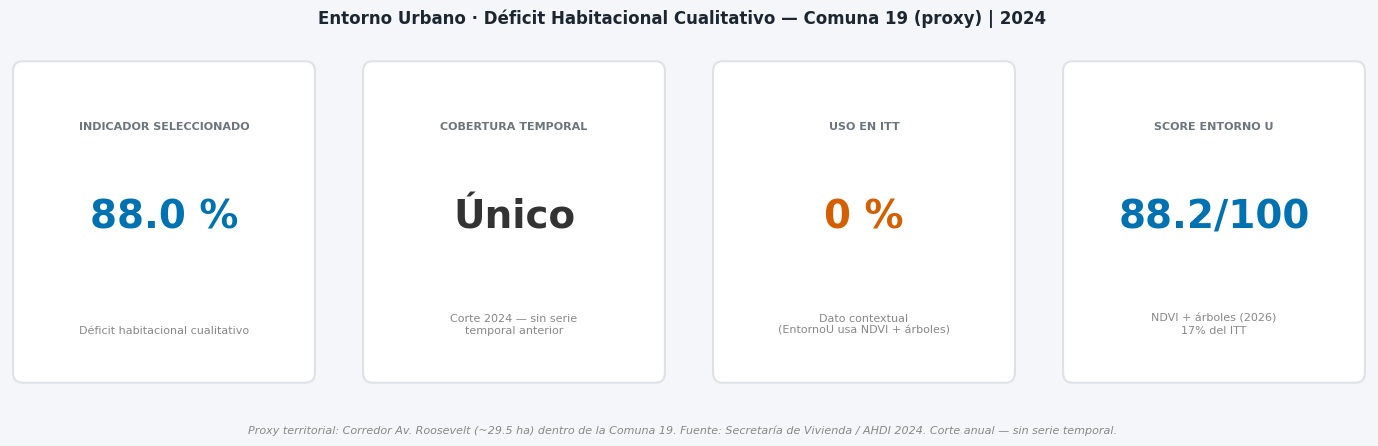

In [23]:
# ── Celda EU-3b: card Déficit Habitacional — formato dashboard (Roosevelt) ─────
import matplotlib.patches as mpatches
from pathlib import Path

# ── Déficit habitacional para Comuna 19 (proxy del corredor Roosevelt) ─────────
_deficit_paths = [
    REPO / 'data' / 'referencia' / 'vivienda' / 'BD_DEFICIT_HABITACIONAL_COM_CORREG_2024 (1).xlsx',
    Path('data/referencia/vivienda/BD_DEFICIT_HABITACIONAL_COM_CORREG_2024 (1).xlsx'),
]
deficit_pct = None
for _p in _deficit_paths:
    if _p.exists():
        _df_def  = pd.read_excel(_p, sheet_name='Hoja1', header=0)
        _fila_19 = _df_def[_df_def.iloc[:, 0].astype(str).str.strip() == '19']
        if not _fila_19.empty:
            _def_total = float(_fila_19.iloc[0, 1])   # Déficit Habitacional
            _def_cual  = float(_fila_19.iloc[0, 3])   # Déficit Cualitativo
            deficit_pct = (_def_cual / _def_total * 100) if _def_total else np.nan
            print(f'Déficit cualitativo Comuna 19: {_def_cual:,.0f} / {_def_total:,.0f} = {deficit_pct:.1f}%')
        break
if deficit_pct is None:
    print('Archivo de déficit no encontrado — mostrando N/D')

# Score EntornoU real (último año disponible en df_eu)
_eu_row = df_eu.dropna(subset=['score_entorno_u']) if 'df_eu' in dir() else pd.DataFrame()
sc_eu_val = float(_eu_row.iloc[-1]['score_entorno_u']) if not _eu_row.empty else globals().get('REF_ENTORNO_U', 39.2)
_eu_año   = int(_eu_row.iloc[-1]['año']) if not _eu_row.empty else 2025

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 4), facecolor=BG)
fig.suptitle('Entorno Urbano · Déficit Habitacional Cualitativo — Comuna 19 (proxy) | 2024',
             fontsize=12, fontweight='bold', color='#1B2631', y=1.02)

posiciones = [
    [0.02, 0.08, 0.22, 0.82],
    [0.27, 0.08, 0.22, 0.82],
    [0.52, 0.08, 0.22, 0.82],
    [0.77, 0.08, 0.22, 0.82],
]

def card(ax, etiqueta_top, valor_str, etiqueta_bot, color_val):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    rect = mpatches.FancyBboxPatch(
        (0.04, 0.04), 0.92, 0.92,
        boxstyle='round,pad=0.03',
        linewidth=1.5, edgecolor='#DEE2E6', facecolor='white'
    )
    ax.add_patch(rect)
    ax.text(0.5, 0.78, etiqueta_top, ha='center', fontsize=8,
            color='#6C757D', fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.48, valor_str,    ha='center', fontsize=28,
            color=color_val, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.16, etiqueta_bot, ha='center', fontsize=8,
            color='#888888', transform=ax.transAxes)

axes_c = [fig.add_axes(p) for p in posiciones]

card(axes_c[0],
     'INDICADOR SELECCIONADO',
     f'{deficit_pct:.1f} %' if deficit_pct is not None else 'N/D',
     'Déficit habitacional cualitativo',
     OKI_AZUL)

card(axes_c[1],
     'COBERTURA TEMPORAL',
     'Único',
     'Corte 2024 — sin serie\ntemporal anterior',
     OKI_GRIS)

card(axes_c[2],
     'USO EN ITT',
     '0 %',
     'Dato contextual\n(EntornoU usa NDVI + árboles)',
     OKI_BERMELL)

card(axes_c[3],
     'SCORE ENTORNO U',
     f'{sc_eu_val:.1f}/100',
     f'NDVI + árboles ({_eu_año})\n17% del ITT',
     OKI_AZUL)

fig.text(0.5, -0.04,
    'Proxy territorial: Corredor Av. Roosevelt (~29.5 ha) dentro de la Comuna 19. '
    'Fuente: Secretaría de Vivienda / AHDI 2024. Corte anual — sin serie temporal.',
    ha='center', fontsize=8, color='#888888', style='italic')

plt.savefig('itt_roosevelt_deficit_card.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Dimension Educacion y Desarrollo — Corredor Roosevelt

IE: **Liceo Departamental** (DANE `176001001745`) — 2 sedes dentro del buffer:
- Sede La Presentacion (barrio Julio 3, Comuna 19)
- Sede La Gran Colombia (barrio El Cedro, Comuna 19)

**Fuentes:** SIMPADE (local, grados 0-11 + aceleracion, sin adultos) + SIMAT 6A dic (Drive).
Sin SIMAT, el score queda NaN — NO se usa referencial para anios 2023-2025.

In [24]:
import os, subprocess, importlib.util

DANE_IE   = '176001001745'   # Liceo Departamental
AÑOS_EDUC = [2023, 2024, 2025]

EDUC_DIR = REPO / 'data' / 'referencia' / 'educacion'
SIMPADE_FILES = {
    2023: (EDUC_DIR / 'SIMPADE' / 'SIMPADE_2023-11.xlsx', 'xlsx'),
    2024: (EDUC_DIR / 'SIMPADE' / 'SIMPADE_2024-11.xlsx', 'xlsx'),
    2025: (EDUC_DIR / 'SIMPADE' / 'SIMPADE_2025-11.csv',  'csv'),
}

# Carpeta Google Drive con SIMAT Anexo 6A diciembre — Liceo Departamental
SIMAT_DRIVE_FOLDER_ID = '1bzP9_uWaJ4dGfwWx18Di3flPQb3hOB6s'

REF_DES_MIN, REF_DES_MAX = 0, 15
REF_REP_MIN, REF_REP_MAX = 0, 20

def cargar_simpade(año, path, fmt):
    try:
        df = pd.read_excel(path, dtype=str) if fmt == 'xlsx' \
             else pd.read_csv(path, sep=';', encoding='utf-8-sig', dtype=str)
        df.columns = [c.strip() for c in df.columns]
        mask_ie  = df['DANE_EE'].str.strip() == DANE_IE
        mask_sec = df['SECTOR'].str.strip().str.upper() == 'OFICIAL'
        df_ie    = df[mask_ie & mask_sec]
        mask_adu = df_ie['GRADO'].astype(str).str.upper().str.contains('CICLO|ADULTO', na=False)
        return len(df_ie[~mask_adu])
    except Exception as e:
        print(f'  ERROR SIMPADE {año}: {e}')
        return np.nan

desertores_educ = {}
for año, (path, fmt) in SIMPADE_FILES.items():
    n = cargar_simpade(año, path, fmt)
    desertores_educ[año] = n
    status = f'{n} desertores' if not (isinstance(n, float) and np.isnan(n)) else 'no encontrado'
    print(f'SIMPADE {año}: {status}  (IE Liceo Departamental, grados 0-11+acel, oficial)')

SIMPADE 2023: 77 desertores  (IE Liceo Departamental, grados 0-11+acel, oficial)
SIMPADE 2024: 45 desertores  (IE Liceo Departamental, grados 0-11+acel, oficial)
SIMPADE 2025: 53 desertores  (IE Liceo Departamental, grados 0-11+acel, oficial)


In [25]:
matricula_simat  = {}
repitentes_simat = {}

def procesar_simat_6a(path_xlsx, año):
    df = pd.read_excel(path_xlsx, dtype=str)
    df.columns = [c.strip().upper().replace(' ', '_') for c in df.columns]
    col_dane = next((c for c in df.columns if 'CODIGO_DANE' in c and 'SEDE' not in c), None)
    if col_dane is None:
        print(f'  {año}: columna CODIGO_DANE no encontrada'); return np.nan, np.nan
    mask_ie  = df[col_dane].str.strip() == DANE_IE
    mask_sec = df['SECTOR'].str.strip().str.upper() == 'OFICIAL'
    df_ie    = df[mask_ie & mask_sec].copy()
    GRADOS_EFIC = list(range(0, 12)) + [99]
    df_ie['_G'] = pd.to_numeric(df_ie['GRADO'], errors='coerce')
    df_ef        = df_ie[df_ie['_G'].isin(GRADOS_EFIC)]
    matricula    = len(df_ef)
    repitentes   = int((df_ef['REPITENTE'].str.strip().str.upper() == 'S').sum())
    return matricula, repitentes

if os.path.exists('/content'):
    if importlib.util.find_spec('gdown') is None:
        subprocess.run(['pip', 'install', 'gdown', '-q'], check=False)
    import gdown

    SIMAT_LOCAL_DIR = Path('/content/simat_liceo_dep')
    if not SIMAT_LOCAL_DIR.exists():
        print('Descargando carpeta SIMAT Liceo Departamental desde Drive...')
        gdown.download_folder(
            f'https://drive.google.com/drive/folders/{SIMAT_DRIVE_FOLDER_ID}',
            output=str(SIMAT_LOCAL_DIR), quiet=False, use_cookies=False
        )
    else:
        print(f'Carpeta ya descargada: {SIMAT_LOCAL_DIR}')

    # Anexo 6A diciembre = corte anual de matricula
    # Nombre patron: '12.1 Anexo 6a Diciembre {año}.xlsx'
    SIMAT_6A_DIR = SIMAT_LOCAL_DIR / 'Anexo 6A'
    if not SIMAT_6A_DIR.exists():
        SIMAT_6A_DIR = SIMAT_LOCAL_DIR  # fallback si la estructura cambia
        print('Advertencia: subcarpeta Anexo 6A no encontrada, buscando en raiz')

    print(f'Archivos Anexo 6A disponibles: {[f.name for f in SIMAT_6A_DIR.glob("*.xlsx")]}')

    for año in AÑOS_EDUC:
        # Prioridad: Diciembre (corte anual) en Anexo 6A
        candidates = (
            list(SIMAT_6A_DIR.glob(f'*[Dd]iciembre*{año}*.xlsx')) +
            list(SIMAT_6A_DIR.glob(f'*12*{año}*.xlsx'))
        )
        if candidates:
            path = candidates[0]
            m, r = procesar_simat_6a(path, año)
            matricula_simat[año]  = m
            repitentes_simat[año] = r
            print(f'  SIMAT 6A {año}: matricula={m}, repitentes={r}  [{path.name}]')
        else:
            print(f'  {año}: Anexo 6A Diciembre no encontrado en {SIMAT_6A_DIR}')
            print(f'         Archivos disponibles: {[f.name for f in SIMAT_6A_DIR.glob("*.xlsx")]}')
else:
    print('No estamos en Colab — SIMAT 6A no disponible.')
    print('Las tasas requieren el archivo como denominador.')

print()
for año in AÑOS_EDUC:
    m = matricula_simat.get(año, 'NaN'); r = repitentes_simat.get(año, 'NaN'); d = desertores_educ.get(año, 'NaN')
    print(f'  {año} — desertores(SIMPADE): {d}  |  matricula(SIMAT): {m}  |  repitentes(SIMAT): {r}')

Carpeta ya descargada: /content/simat_liceo_dep
Archivos Anexo 6A disponibles: ['6.1 Anexo 6a Junio 2025.xlsx', '9.1 Anexo 6a Septiembre 2023.xlsx', '12.1 Anexo 6a Diciembre 2024.xlsx', '12.1 Anexo 6a Diciembre 2023.xlsx', '9.1 Anexo 6a Septiembre 2025.xlsx', '3.1 Anexo 6a Marzo 2026.xlsx', '9.1 Anexo 6a Septiembre 2024.xlsx', '3.1 Anexo 6a Marzo 2024.xlsx', '3.1 Anexo 6a Marzo 2025.xlsx', '6.1 Anexo 6a Junio 2023.xlsx', '3.1 Anexo 6a Marzo 2023.xlsx', '6.1 Anexo 6a Junio 2024.xlsx', '12.1 Anexo 6a Diciembre 2025.xlsx']
  SIMAT 6A 2023: matricula=2172, repitentes=140  [12.1 Anexo 6a Diciembre 2023.xlsx]
  SIMAT 6A 2024: matricula=2112, repitentes=106  [12.1 Anexo 6a Diciembre 2024.xlsx]
  SIMAT 6A 2025: matricula=2087, repitentes=98  [12.1 Anexo 6a Diciembre 2025.xlsx]

  2023 — desertores(SIMPADE): 77  |  matricula(SIMAT): 2172  |  repitentes(SIMAT): 140
  2024 — desertores(SIMPADE): 45  |  matricula(SIMAT): 2112  |  repitentes(SIMAT): 106
  2025 — desertores(SIMPADE): 53  |  matricul

In [26]:
rows_educ = []
for año in AÑOS_EDUC:
    m = matricula_simat.get(año, np.nan)
    r = repitentes_simat.get(año, np.nan)
    d = desertores_educ.get(año, np.nan)

    def _safe(v):
        try: return float(v)
        except: return np.nan

    m_f, r_f, d_f = _safe(m), _safe(r), _safe(d)
    tasa_des = round(d_f/m_f*100, 2) if (not np.isnan(d_f) and not np.isnan(m_f) and m_f>0) else np.nan
    tasa_rep = round(r_f/m_f*100, 2) if (not np.isnan(r_f) and not np.isnan(m_f) and m_f>0) else np.nan
    sc_des = score_ref(tasa_des, REF_DES_MIN, REF_DES_MAX, True) if not np.isnan(tasa_des) else np.nan
    sc_rep = score_ref(tasa_rep, REF_REP_MIN, REF_REP_MAX, True) if not np.isnan(tasa_rep) else np.nan
    sc_disp = [s for s in [sc_des, sc_rep] if not np.isnan(s)]
    sc_educ = round(sum(sc_disp)/len(sc_disp), 1) if sc_disp else np.nan

    rows_educ.append(dict(año=año, matricula=m, desertores=d, repitentes=r,
        tasa_desercion=tasa_des, tasa_repitencia=tasa_rep,
        score_desercion=sc_des, score_repitencia=sc_rep, score_educ_des=sc_educ))

df_educ = pd.DataFrame(rows_educ)

sin_simat = [r['año'] for _, r in df_educ.iterrows() if pd.isna(r['score_educ_des'])]
if sin_simat:
    print(f'SIMAT no disponible para {sin_simat} — ejecutar en Colab para scores reales.')
else:
    print('SIMAT cargado — scores de educacion calculados con datos reales.')

print()
cols_show = ['año','matricula','desertores','tasa_desercion','repitentes','tasa_repitencia','score_educ_des']
print(df_educ[cols_show].to_string(index=False))

for _, row in df_educ.iterrows():
    base.loc[base['año'] == int(row['año']), 'score_educ_des'] = row['score_educ_des']
# 2026: carry-forward del ultimo year con datos reales (no hay SIMAT anual)
_sc_educ_last = base.loc[base["año"].isin(AÑOS_EDUC), "score_educ_des"].dropna()
if not _sc_educ_last.empty:
    _sc_educ_2026 = float(_sc_educ_last.iloc[-1])
    base.loc[base["año"]==2026, "score_educ_des"] = _sc_educ_2026
    print(f"2026 EducDes provisional: carry-forward {AÑOS_EDUC[-1]} = {_sc_educ_2026:.1f}")


base['score_des_social'] = (base['score_cohesion'] + base['score_educ_des']) / 2
base['ITT'] = base.apply(_itt_row, axis=1)
base['nivel'] = base['ITT'].apply(clasificar)
print()
print('ITT actualizado — EducDes real:')
print(base[['año','score_educ_des','ITT','nivel']].round(1).to_string(index=False))

SIMAT cargado — scores de educacion calculados con datos reales.

 año  matricula  desertores  tasa_desercion  repitentes  tasa_repitencia  score_educ_des
2023       2172          77            3.55         140             6.45            72.0
2024       2112          45            2.13         106             5.02            80.4
2025       2087          53            2.54          98             4.70            79.8
2026 EducDes provisional: carry-forward 2025 = 79.8

ITT actualizado — EducDes real:
 año  score_educ_des  ITT          nivel
2023            72.0 58.6  Consolidacion
2024            80.4 66.0 Transformacion
2025            79.8 65.0 Transformacion
2026            79.8 70.7 Transformacion


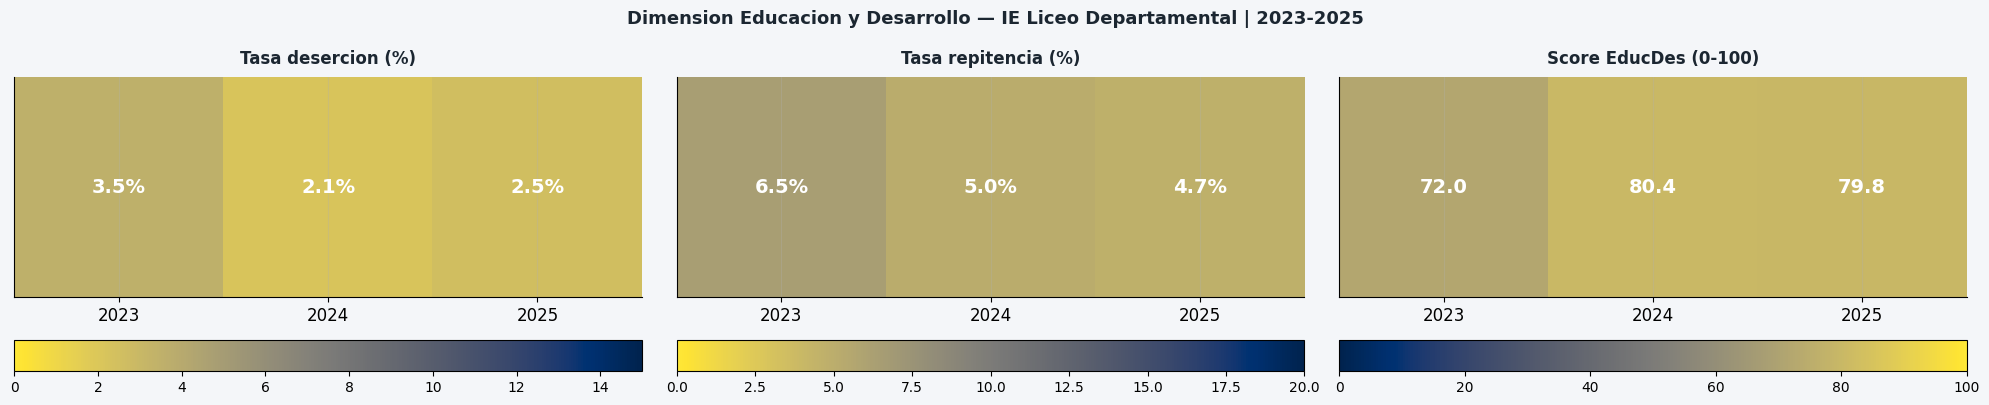

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4), facecolor=BG)
fig.suptitle('Dimension Educacion y Desarrollo — IE Liceo Departamental | 2023-2025',
             fontsize=13, fontweight='bold', color='#1B2631')

df_e = df_educ.set_index('año').reindex(AÑOS_EDUC)
configs_hm = [
    ('tasa_desercion',  'Tasa desercion (%)',    'cividis_r', 0, 15,  '%'),
    ('tasa_repitencia', 'Tasa repitencia (%)',   'cividis_r', 0, 20,  '%'),
    ('score_educ_des',  'Score EducDes (0-100)', 'cividis',   0, 100, ''),
]
for ax, (col, titulo, cmap, vmin, vmax, sfx) in zip(axes, configs_hm):
    vals = df_e[col].values.astype(float).reshape(1, -1)
    im = ax.imshow(vals, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(AÑOS_EDUC))); ax.set_xticklabels(AÑOS_EDUC, fontsize=12)
    ax.set_yticks([])
    ax.set_title(titulo, fontweight='bold', pad=10, color='#1B2631')
    for j, v in enumerate(vals[0]):
        txt = f'{v:.1f}{sfx}' if not np.isnan(v) else 'S/D'
        ax.text(j, 0, txt, ha='center', va='center', fontsize=14, fontweight='bold', color='white')
    plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.14)
plt.tight_layout()
plt.savefig('itt_roosevelt_educacion_heatmap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

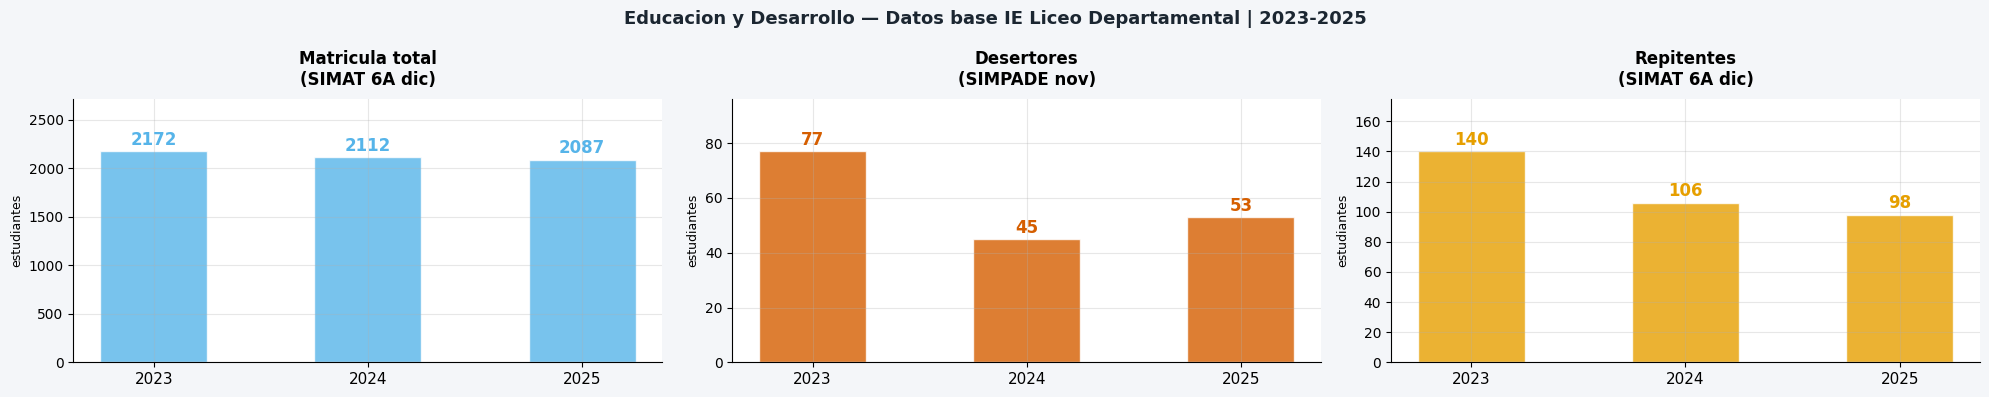

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4), facecolor=BG)
fig.suptitle('Educacion y Desarrollo — Datos base IE Liceo Departamental | 2023-2025',
             fontsize=13, fontweight='bold', color='#1B2631')

df_e = df_educ.set_index('año').reindex(AÑOS_EDUC)
configs = [
    ('matricula',  'Matricula total\n(SIMAT 6A dic)',  OKI_AZUL_C,  'estudiantes'),
    ('desertores', 'Desertores\n(SIMPADE nov)',         OKI_BERMELL, 'estudiantes'),
    ('repitentes', 'Repitentes\n(SIMAT 6A dic)',        OKI_NARANJA, 'estudiantes'),
]
x = list(range(len(AÑOS_EDUC)))
for ax, (col, titulo, color, unidad) in zip(axes, configs):
    ax.set_facecolor('white')
    vals = df_e[col].values.astype(float)
    bars = ax.bar(x, vals, color=color, alpha=0.80, width=0.5, edgecolor='white')
    vmax = np.nanmax(vals) if not np.all(np.isnan(vals)) else 1
    for xi, v in zip(x, vals):
        if not np.isnan(v):
            ax.text(xi, v + vmax*0.03, f'{int(v)}', ha='center', fontsize=12, fontweight='bold', color=color)
    ax.set_xticks(x); ax.set_xticklabels(AÑOS_EDUC, fontsize=11)
    ax.set_ylim(0, vmax*1.25); ax.set_title(titulo, fontweight='bold', pad=10)
    ax.set_ylabel(unidad, fontsize=9); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('itt_roosevelt_educacion_base.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

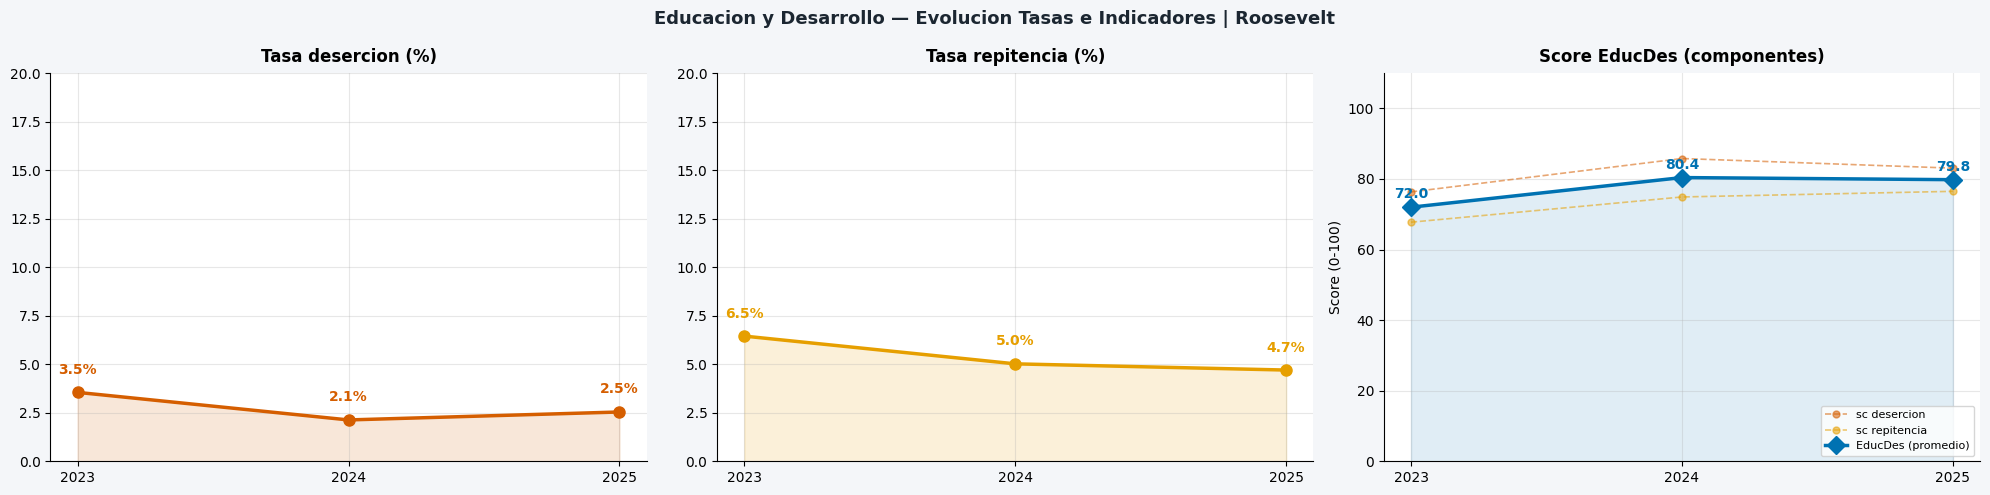

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor=BG)
fig.suptitle('Educacion y Desarrollo — Evolucion Tasas e Indicadores | Roosevelt',
             fontsize=13, fontweight='bold', color='#1B2631')

df_e = df_educ.set_index('año').reindex(AÑOS_EDUC)
x    = list(range(len(AÑOS_EDUC)))

cfg_lin = [
    ('tasa_desercion',  'Tasa desercion (%)',  OKI_BERMELL),
    ('tasa_repitencia', 'Tasa repitencia (%)', OKI_NARANJA),
]
for ax, (col, titulo, color) in zip(axes[:2], cfg_lin):
    ax.set_facecolor('white')
    vals = df_e[col].values.astype(float)
    vmax_data = np.nanmax(vals) if not np.all(np.isnan(vals)) else 20
    ymax = max(20, round(vmax_data * 1.3 + 2, 0))
    ax.plot(x, vals, color=color, linewidth=2.5, marker='o', markersize=8, zorder=3)
    ax.fill_between(x, vals, alpha=0.15, color=color)
    for xi, v in zip(x, vals):
        if not np.isnan(v):
            offset  = ymax * 0.04
            va_pos  = 'bottom'
            if v + offset > ymax * 0.92:
                offset = -ymax * 0.06; va_pos = 'top'
            ax.text(xi, v + offset, f'{v:.1f}%', ha='center', va=va_pos,
                    fontsize=10, fontweight='bold', color=color)
    ax.set_xticks(x); ax.set_xticklabels(AÑOS_EDUC)
    ax.set_ylim(0, ymax); ax.set_title(titulo, fontweight='bold', pad=8)
    ax.spines[['top', 'right']].set_visible(False)

ax = axes[2]; ax.set_facecolor('white')
sc_vals = df_e['score_educ_des'].values.astype(float)
sc_des  = df_e['score_desercion'].values.astype(float)
sc_rep  = df_e['score_repitencia'].values.astype(float)
ax.plot(x, sc_des, color=OKI_BERMELL, linewidth=1.2, linestyle='--',
        marker='o', markersize=5, alpha=0.55, label='sc desercion', zorder=2)
ax.plot(x, sc_rep, color=OKI_NARANJA, linewidth=1.2, linestyle='--',
        marker='o', markersize=5, alpha=0.55, label='sc repitencia', zorder=2)
ax.plot(x, sc_vals, color=OKI_AZUL, linewidth=2.5, marker='D', markersize=9,
        label='EducDes (promedio)', zorder=3)
ax.fill_between(x, sc_vals, alpha=0.12, color=OKI_AZUL)
for xi, v in zip(x, sc_vals):
    if not np.isnan(v):
        ax.text(xi, v + 2.5, f'{v:.1f}', ha='center', fontsize=10, fontweight='bold', color=OKI_AZUL)
ax.set_xticks(x); ax.set_xticklabels(AÑOS_EDUC)
ax.set_ylim(0, 110); ax.set_ylabel('Score (0-100)')
ax.set_title('Score EducDes (componentes)', fontweight='bold', pad=8)
ax.legend(fontsize=8, loc='lower right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('itt_roosevelt_educacion_evol_tasas.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

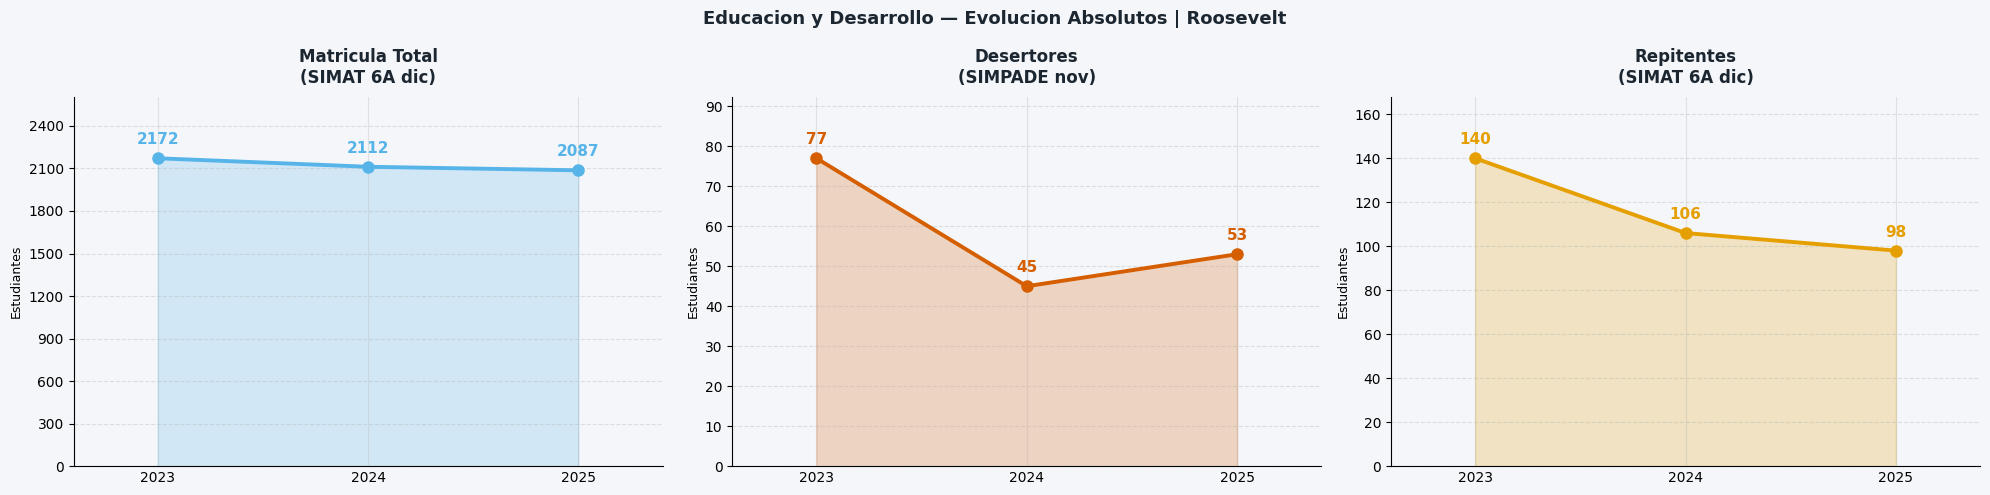

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor=BG)
fig.suptitle('Educacion y Desarrollo — Evolucion Absolutos | Roosevelt',
             fontsize=13, fontweight='bold', color='#1B2631')

df_ep    = df_educ.set_index('año').reindex(AÑOS_EDUC)
anos_lbl = [str(a) for a in AÑOS_EDUC]
x_e      = np.arange(len(AÑOS_EDUC))

cfg_ed = [
    ('matricula',  'Matricula Total\n(SIMAT 6A dic)',  OKI_AZUL_C,  'estudiantes'),
    ('desertores', 'Desertores\n(SIMPADE nov)',          OKI_BERMELL, 'estudiantes'),
    ('repitentes', 'Repitentes\n(SIMAT 6A dic)',         OKI_NARANJA, 'estudiantes'),
]

for ax, (col, titulo, color, unidad) in zip(axes, cfg_ed):
    vals  = df_ep[col].values.astype(float)
    valid = ~np.isnan(vals)
    ax.fill_between(x_e, 0, np.where(valid, vals, np.nan), alpha=0.22, color=color)
    ax.plot(x_e, np.where(valid, vals, np.nan),
            color=color, linewidth=2.8, marker='o', markersize=8, zorder=3)
    for i, v in enumerate(vals):
        if not np.isnan(v):
            ax.annotate(str(int(v)), (i, v), textcoords='offset points', xytext=(0, 10),
                        ha='center', fontsize=11, fontweight='bold', color=color)
    ax.set_xticks(x_e); ax.set_xticklabels(anos_lbl, fontsize=10)
    ax.set_title(titulo, fontweight='bold', pad=10, color='#1B2631')
    ax.set_ylabel(unidad.capitalize(), fontsize=9)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.set_xlim(-0.4, len(AÑOS_EDUC) - 0.6)
    ax.set_ylim(0, np.nanmax(vals) * 1.2 if not np.all(np.isnan(vals)) else 1)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.set_facecolor(BG); ax.tick_params(axis='x', length=0)
plt.tight_layout()
plt.savefig('itt_roosevelt_educacion_evol_abs.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

Archivo 2026 detectado: 3.1 Anexo 6a Marzo 2026.xlsx
Historico anual comparable 2023-2025:


,ano,matricula,desertores,repitentes,tasa_desercion,tasa_repitencia,score_educ_des
0,2023,2172,77,140,3.55,6.45,72.0
1,2024,2112,45,106,2.13,5.02,80.4
2,2025,2087,53,98,2.54,4.70,79.8



Educacion 2026 corte marzo (complementario):


,ano,corte,matricula_observada,repitentes_observados,tasa_repitencia_observada,nota
0,2026,Marzo,2057,138,6.71,Corte parcial marzo 2026. No comparable con ci...


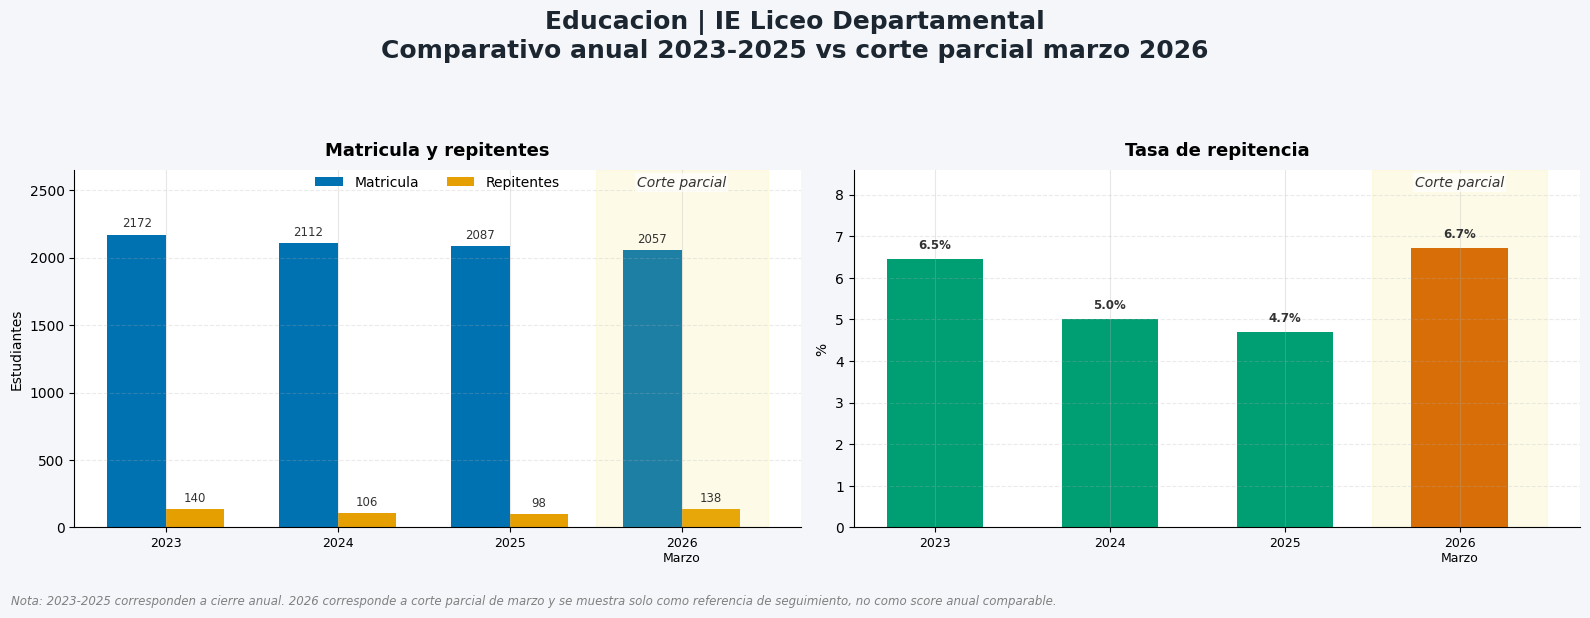

In [31]:
# ── Celda ED-2026V: Educacion 2026 corte marzo | Roosevelt ──────────────────
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# Requiere haber ejecutado antes:
# - Celda ED-1 (define procesar_simat_6a, AÑOS_EDUC, SIMAT_LOCAL_DIR, etc.)
# - Celda ED-3 (crea df_educ con 2023-2025)

if 'procesar_simat_6a' not in globals():
    raise RuntimeError("Primero ejecuta la celda ED-1 donde se define procesar_simat_6a().")

if 'df_educ' not in globals():
    raise RuntimeError("Primero ejecuta la celda ED-3 para crear df_educ.")

if 'SIMAT_LOCAL_DIR' not in globals():
    raise RuntimeError("No existe SIMAT_LOCAL_DIR. Ejecuta primero la descarga/carga SIMAT en Colab.")

# ── Buscar archivo marzo 2026 dentro de la carpeta descargada ───────────────
simat_dir = Path(SIMAT_LOCAL_DIR)
simat_6a_dir = simat_dir / 'Anexo 6A'
if not simat_6a_dir.exists():
    simat_6a_dir = simat_dir

candidates_2026 = (
    list(simat_6a_dir.glob('*[Mm]arzo*2026*.xlsx')) +
    list(simat_6a_dir.glob('*3.1*2026*.xlsx')) +
    list(simat_6a_dir.glob('*2026*.xlsx'))
)

if not candidates_2026:
    raise FileNotFoundError(
        f"No encontré archivo SIMAT marzo 2026 en {simat_6a_dir}. "
        "Revisa el nombre dentro de la carpeta descargada."
    )

simat_2026_path = candidates_2026[0]
print(f'Archivo 2026 detectado: {simat_2026_path.name}')

# ── Extraer matrícula y repitentes observados al corte marzo ────────────────
mat_2026_mar, rep_2026_mar = procesar_simat_6a(simat_2026_path, 2026)

df_educ_2026_marzo = pd.DataFrame([{
    'ano': 2026,
    'corte': 'Marzo',
    'matricula_observada': mat_2026_mar,
    'repitentes_observados': rep_2026_mar,
    'tasa_repitencia_observada': round(rep_2026_mar / mat_2026_mar * 100, 2) if mat_2026_mar and mat_2026_mar > 0 else np.nan,
    'nota': 'Corte parcial marzo 2026. No comparable con cierre anual 2023-2025. No entra al score anual.'
}])

# ── Base histórica comparable 2023-2025 ─────────────────────────────────────
df_hist_educ = df_educ.copy().rename(columns={'año': 'ano'})
df_hist_educ = df_hist_educ[df_hist_educ['ano'].isin([2023, 2024, 2025])].copy()
df_hist_educ['label'] = df_hist_educ['ano'].astype(str)

row_2026 = df_educ_2026_marzo.iloc[0]
df_plot_2026 = pd.DataFrame([{
    'label': '2026\nMarzo',
    'matricula_anual': row_2026['matricula_observada'],
    'repitentes_anual': row_2026['repitentes_observados'],
    'tasa_repitencia_anual': row_2026['tasa_repitencia_observada'],
}])

df_hist_plot = df_hist_educ.rename(columns={
    'matricula': 'matricula_anual',
    'repitentes': 'repitentes_anual',
    'tasa_repitencia': 'tasa_repitencia_anual'
})

df_all = pd.concat([
    df_hist_plot[['label', 'matricula_anual', 'repitentes_anual', 'tasa_repitencia_anual']],
    df_plot_2026
], ignore_index=True)

print('Historico anual comparable 2023-2025:')
display(df_hist_educ[['ano', 'matricula', 'desertores', 'repitentes', 'tasa_desercion', 'tasa_repitencia', 'score_educ_des']])

print('\nEducacion 2026 corte marzo (complementario):')
display(df_educ_2026_marzo)

# ── Visualización comparativa ────────────────────────────────────────────────
# Paleta Okabe-Ito
OKI_AZUL     = "#0072B2"
OKI_NARANJA  = "#E69F00"
OKI_VERDE    = "#009E73"
OKI_AMARILLO = "#F0E442"
OKI_BERMELL  = "#D55E00"
OKI_GRIS     = "#333333"
BG           = "#F4F6F9"

x = np.arange(len(df_all))
w = 0.34

titulo_general = (
    "Educacion | IE Liceo Departamental\n"
    "Comparativo anual 2023-2025 vs corte parcial marzo 2026"
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6.2), facecolor=BG)
fig.suptitle(
    titulo_general,
    fontsize=18, fontweight="bold", color="#1B2631", y=0.98
)

# ── Panel 1 ────────────────────────────────────────────────────────────────
ax = axes[0]
bars1 = ax.bar(x - w/2, df_all["matricula_anual"], width=w, color=OKI_AZUL, label="Matricula")
bars2 = ax.bar(x + w/2, df_all["repitentes_anual"], width=w, color=OKI_NARANJA, label="Repitentes")

ymax1 = float(df_all["matricula_anual"].fillna(0).max()) * 1.22
ax.set_ylim(0, ymax1)

ax.axvspan(len(df_all)-1 - 0.5, len(df_all)-1 + 0.5, color=OKI_AMARILLO, alpha=0.12)

ax.text(
    len(df_all)-1,
    ymax1 * 0.985,
    "Corte parcial",
    ha="center", va="top",
    fontsize=10, color=OKI_GRIS, style="italic",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5)
)

for b in list(bars1) + list(bars2):
    h = b.get_height()
    if pd.notna(h):
        ax.text(
            b.get_x() + b.get_width()/2,
            h + ymax1 * 0.012,
            f"{int(h)}",
            ha="center", va="bottom",
            fontsize=8.5, color=OKI_GRIS
        )

ax.set_title("Matricula y repitentes", fontweight="bold", pad=10, fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(df_all["label"], fontsize=9)
ax.set_ylabel("Estudiantes")
ax.grid(axis="y", linestyle="--", alpha=0.25)

# Leyenda fuera del panel
ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    fontsize=10
)

# ── Panel 2 ────────────────────────────────────────────────────────────────
ax2 = axes[1]
colors = [OKI_VERDE, OKI_VERDE, OKI_VERDE, OKI_BERMELL]
bars3 = ax2.bar(x, df_all["tasa_repitencia_anual"], color=colors, width=0.55)

ymax2 = float(df_all["tasa_repitencia_anual"].fillna(0).max()) * 1.28
ax2.set_ylim(0, ymax2)

ax2.axvspan(len(df_all)-1 - 0.5, len(df_all)-1 + 0.5, color=OKI_AMARILLO, alpha=0.12)

ax2.text(
    len(df_all)-1,
    ymax2 * 0.985,
    "Corte parcial",
    ha="center", va="top",
    fontsize=10, color=OKI_GRIS, style="italic",
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5)
)

for b in bars3:
    h = b.get_height()
    if pd.notna(h):
        ax2.text(
            b.get_x() + b.get_width()/2,
            h + ymax2 * 0.02,
            f"{h:.1f}%",
            ha="center", va="bottom",
            fontsize=8.5, color=OKI_GRIS, fontweight="bold"
        )

ax2.set_title("Tasa de repitencia", fontweight="bold", pad=10, fontsize=13)
ax2.set_xticks(x)
ax2.set_xticklabels(df_all["label"], fontsize=9)
ax2.set_ylabel("%")
ax2.grid(axis="y", linestyle="--", alpha=0.25)

fig.text(
    0.01, 0.02,
    "Nota: 2023-2025 corresponden a cierre anual. 2026 corresponde a corte parcial de marzo y se muestra solo como referencia de seguimiento, no como score anual comparable.",
    fontsize=8.5, color="gray", style="italic"
)

plt.tight_layout(rect=[0, 0.06, 1, 0.90])
plt.show()


## Dimension Desarrollo Economico — Corredor Roosevelt

**Fuente:** Registro Mercantil 2025 — 493 empresas dentro del buffer 100 m (snapshot).
Construccion de serie 2023-2025 desde campo `Mes_Dia_An` (fecha matricula en espanol).
**Umbrales calibrados al corredor** (escala mayor que un barrio):

| Indicador | ref_min | ref_max |
|---|---:|---:|
| Negocios nuevos/ano | 0 | 75 |
| Personal negocios nuevos | 0 | 80 |
| Ingresos log1p | 0 | 25.0 |

In [32]:
MESES_ES = {'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,
            'julio':7,'agosto':8,'septiembre':9,'setiembre':9,
            'octubre':10,'noviembre':11,'diciembre':12}

def parse_fecha_es_de(v):
    if not v or str(v) in ('nan','None',''): return pd.NaT
    m = re.search(r'(\d{1,2})\s+de\s+([a-z\xe1\xe9\xed\xf3\xfa]+)\s+de\s+(\d{4})', str(v).lower())
    if not m: return pd.NaT
    try: return pd.Timestamp(int(m.group(3)), MESES_ES.get(m.group(2),0) or 1, int(m.group(1)))
    except: return pd.NaT

with open(PATHS['registro_mercantil'], encoding='utf-8') as f:
    raw_de = json.load(f)

df_de = pd.DataFrame([feat['properties'] for feat in raw_de['features']])
for col in ['INGRESOS_A','PERSONAL_O']:
    df_de[col] = pd.to_numeric(df_de[col], errors='coerce')

df_de['fecha_mat']       = df_de['Mes_Dia_An'].apply(parse_fecha_es_de)
df_de['anio_mat']        = df_de['fecha_mat'].dt.year
df_de['trim_mat']        = df_de['fecha_mat'].dt.quarter
df_de['ingresos_limpio'] = df_de['INGRESOS_A'].where(df_de['INGRESOS_A'] > 0, np.nan)
df_de['personal_limpio'] = df_de['PERSONAL_O'].where(df_de['PERSONAL_O'] >= 0, np.nan)

es_micro = df_de['TAMANO957'].str.upper().str.contains('MICRO', na=False) if 'TAMANO957' in df_de.columns else pd.Series([False]*len(df_de))
print(f'Registro Mercantil cargado: {len(df_de)} negocios (snapshot renovacion 2025)')
print(f'  Micro: {es_micro.sum()} ({es_micro.mean()*100:.1f}%)')
print(f'  Personal total stock 2025: {df_de["personal_limpio"].sum():.0f} personas')
print(f'  Ingresos positivos total stock: ${df_de["ingresos_limpio"].sum():,.0f}')

Registro Mercantil cargado: 493 negocios (snapshot renovacion 2025)
  Micro: 444 (90.1%)
  Personal total stock 2025: 3826 personas
  Ingresos positivos total stock: $676,325,745,918


In [33]:
ANIOS_DE = [2023, 2024, 2025]
REF_NEG_MIN,  REF_NEG_MAX  = 0, 75
REF_PERS_MIN, REF_PERS_MAX = 0, 80
REF_ING_MIN,  REF_ING_MAX  = 0, 25.0

rows_de_trim = []
for ano in ANIOS_DE:
    for trim in [1,2,3,4]:
        sub = df_de[(df_de['anio_mat']==ano) & (df_de['trim_mat']==trim)]
        rows_de_trim.append({'periodo': f'{ano}-Q{trim}', 'año': ano, 'trimestre': trim,
            'negocios_nuevos': len(sub),
            'personal_nuevos': sub['personal_limpio'].sum(),
            'ingresos_nuevos': sub['ingresos_limpio'].sum()})
df_de_trim = pd.DataFrame(rows_de_trim)

rows_de_anual = []
for ano in ANIOS_DE:
    sub = df_de[df_de['anio_mat']==ano]
    rows_de_anual.append({'año': ano,
        'negocios_nuevos': len(sub),
        'personal_nuevos': sub['personal_limpio'].sum(),
        'ingresos_nuevos': sub['ingresos_limpio'].sum()})
df_de_anual = pd.DataFrame(rows_de_anual)

REF_EST_MIN = 0
REF_EST_MAX = int(len(df_de))
REF_PERS_STOCK_MIN = 0
REF_PERS_STOCK_MAX = float(df_de['personal_limpio'].sum(skipna=True))
REF_ING_STOCK_MIN = 0
REF_ING_STOCK_MAX = float(np.log1p(df_de['ingresos_limpio'].sum(skipna=True)))

rows_de_stock = []
for ano in [2023, 2024, 2025, 2026]:
    if ano <= 2025:
        sub_stock = df_de[df_de['anio_mat'] <= ano].copy()
        tipo = 'Real' if ano == 2025 else 'Proxy retrospectivo'
    else:
        sub_stock = df_de[df_de['anio_mat'] <= 2025].copy()
        tipo = 'Proxy referencial = 2025'

    est = float(len(sub_stock))
    pers = float(sub_stock['personal_limpio'].sum(skipna=True)) if len(sub_stock) > 0 else np.nan
    ing = float(sub_stock['ingresos_limpio'].sum(skipna=True)) if len(sub_stock) > 0 else np.nan
    n_ing = int(sub_stock['ingresos_limpio'].notna().sum()) if len(sub_stock) > 0 else 0
    ing_log = float(np.log1p(ing)) if pd.notna(ing) and ing > 0 else 0.0

    rows_de_stock.append({
        'año': ano,
        'tipo_dato': tipo,
        'establecimientos_activos': est,
        'empleabilidad_total': pers,
        'ingresos_operacionales': ing,
        'negocios_con_ingreso': n_ing,
        'ingresos_log1p': ing_log,
    })

df_de_stock = pd.DataFrame(rows_de_stock)

print('Actividad Económica — cohorte exploratoria 2023-2025:')
print(df_de_anual.to_string(index=False))
print()
print('Actividad Económica — stock activo oficial/proxy para ITT')
print(df_de_stock[['año','tipo_dato','establecimientos_activos','empleabilidad_total','ingresos_operacionales','negocios_con_ingreso']].to_string(index=False))

Actividad Económica — cohorte exploratoria 2023-2025:
 año  negocios_nuevos  personal_nuevos  ingresos_nuevos
2023               36             67.0     1.154358e+10
2024               50             62.0     6.236528e+10
2025               58             49.0     1.805000e+07

Actividad Económica — stock activo oficial/proxy para ITT
 año                tipo_dato  establecimientos_activos  empleabilidad_total  ingresos_operacionales  negocios_con_ingreso
2023      Proxy retrospectivo                     385.0               3715.0            6.139424e+11                   189
2024      Proxy retrospectivo                     435.0               3777.0            6.763077e+11                   202
2025                     Real                     493.0               3826.0            6.763257e+11                   206
2026 Proxy referencial = 2025                     493.0               3826.0            6.763257e+11                   206


In [34]:
rows_de_sc = []
for _, row in df_de_stock.iterrows():
    ano = int(row['año'])
    neg = float(row['establecimientos_activos'])
    pers = float(row['empleabilidad_total'])
    ing = float(row['ingresos_operacionales'])
    ing_log = float(row['ingresos_log1p']) if pd.notna(row['ingresos_log1p']) else np.nan

    sc_neg  = score_ref(neg,     REF_EST_MIN,        REF_EST_MAX,        False) if not pd.isna(neg)     else np.nan
    sc_pers = score_ref(pers,    REF_PERS_STOCK_MIN, REF_PERS_STOCK_MAX, False) if not pd.isna(pers)    else np.nan
    sc_ing  = score_ref(ing_log, REF_ING_STOCK_MIN,  REF_ING_STOCK_MAX,  False) if not pd.isna(ing_log) else np.nan
    vals    = [x for x in [sc_neg, sc_pers, sc_ing] if not pd.isna(x)]
    sc_de   = float(np.mean(vals)) if vals else np.nan

    rows_de_sc.append({
        'año': ano,
        'tipo_dato': row['tipo_dato'],
        'establecimientos_activos': neg,
        'empleabilidad_total': pers,
        'ingresos_operacionales': ing,
        'negocios_con_ingreso': float(row['negocios_con_ingreso']),
        'ingresos_log1p': ing_log,
        'score_establecimientos': sc_neg,
        'score_empleabilidad': sc_pers,
        'score_ingresos': sc_ing,
        'score_des_eco': sc_de,
    })

df_de_scores = pd.DataFrame(rows_de_sc)

for _, r in df_de_scores.iterrows():
    if not pd.isna(r['score_des_eco']):
        base.loc[base['año']==int(r['año']), 'score_des_eco'] = r['score_des_eco']

base['ITT'] = base.apply(_itt_row, axis=1)
base['nivel'] = base['ITT'].apply(clasificar)

print('Scores Desarrollo Economico — oficial ITT (stock activo/proxy):')
cols_sc = ['año','tipo_dato','establecimientos_activos','empleabilidad_total','ingresos_operacionales','negocios_con_ingreso','score_establecimientos','score_empleabilidad','score_ingresos','score_des_eco']
print(df_de_scores[cols_sc].round(2).to_string(index=False))
print()
print('ITT final — 5 dimensiones:')
cols_b = ['año','score_seguridad','score_movilidad','score_des_social','score_entorno_u','score_des_eco','ITT','nivel']
print(base[cols_b].round(1).to_string(index=False))

Scores Desarrollo Economico — oficial ITT (stock activo/proxy):
 año                tipo_dato  establecimientos_activos  empleabilidad_total  ingresos_operacionales  negocios_con_ingreso  score_establecimientos  score_empleabilidad  score_ingresos  score_des_eco
2023      Proxy retrospectivo                     385.0               3715.0            6.139424e+11                 189.0                   78.09                97.10           99.64          91.61
2024      Proxy retrospectivo                     435.0               3777.0            6.763077e+11                 202.0                   88.24                98.72          100.00          95.65
2025                     Real                     493.0               3826.0            6.763257e+11                 206.0                  100.00               100.00          100.00         100.00
2026 Proxy referencial = 2025                     493.0               3826.0            6.763257e+11                 206.0                  

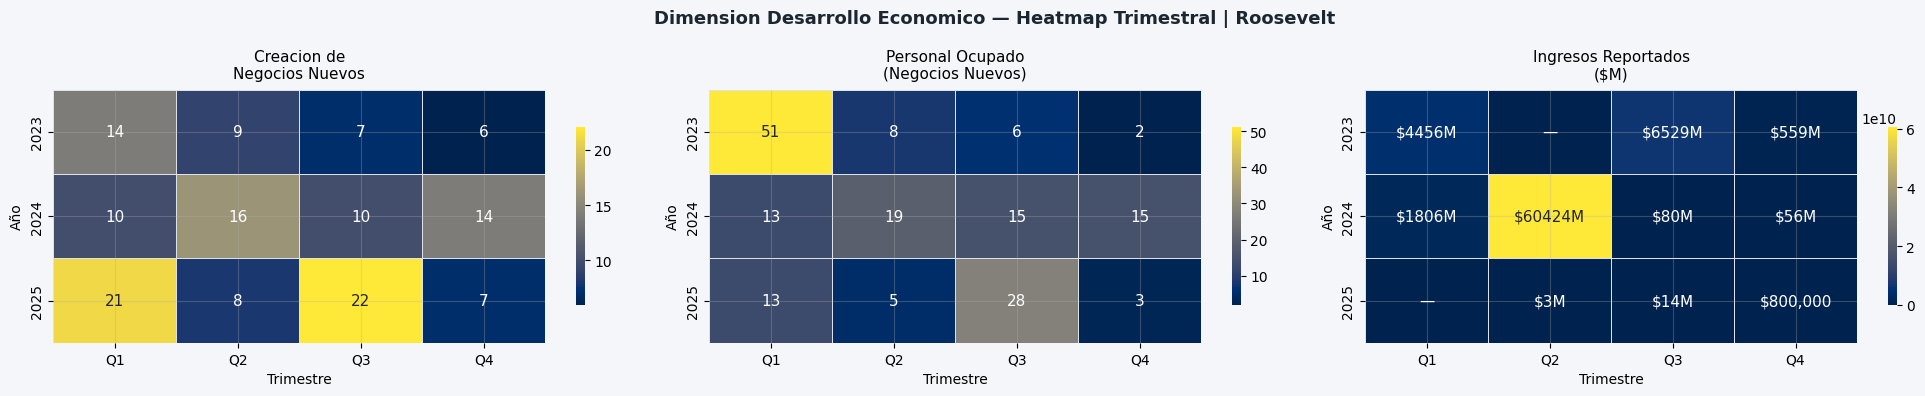

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(20, 4), facecolor=BG)
fig.suptitle('Dimension Desarrollo Economico — Heatmap Trimestral | Roosevelt',
             fontsize=13, fontweight='bold', color='#1B2631')

for ax, col, titulo, fmt_fn in [
    (axes[0], 'negocios_nuevos', 'Creacion de\nNegocios Nuevos', lambda x: f'{int(x)}'),
    (axes[1], 'personal_nuevos', 'Personal Ocupado\n(Negocios Nuevos)', lambda x: f'{int(x)}'),
    (axes[2], 'ingresos_nuevos', 'Ingresos Reportados\n($M)',
     lambda x: f'${x/1e6:.0f}M' if x >= 1e6 else ('—' if x == 0 else f'${x:,.0f}')),
]:
    pivot = df_de_trim.pivot(index='año', columns='trimestre', values=col).fillna(0)
    pivot.columns = ['Q1','Q2','Q3','Q4']
    annot = pivot.applymap(fmt_fn)
    sns.heatmap(pivot, annot=annot, fmt='', cmap='cividis',
        linewidths=0.5, linecolor='#DEE2E6', ax=ax, annot_kws={'size':11},
        cbar_kws={'shrink':0.7})
    ax.set_title(titulo, fontsize=11, pad=8)
    ax.set_xlabel('Trimestre'); ax.set_ylabel('Año')
plt.tight_layout()
plt.savefig('itt_roosevelt_de_heatmap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

KeyError: 'negocios_nuevos'

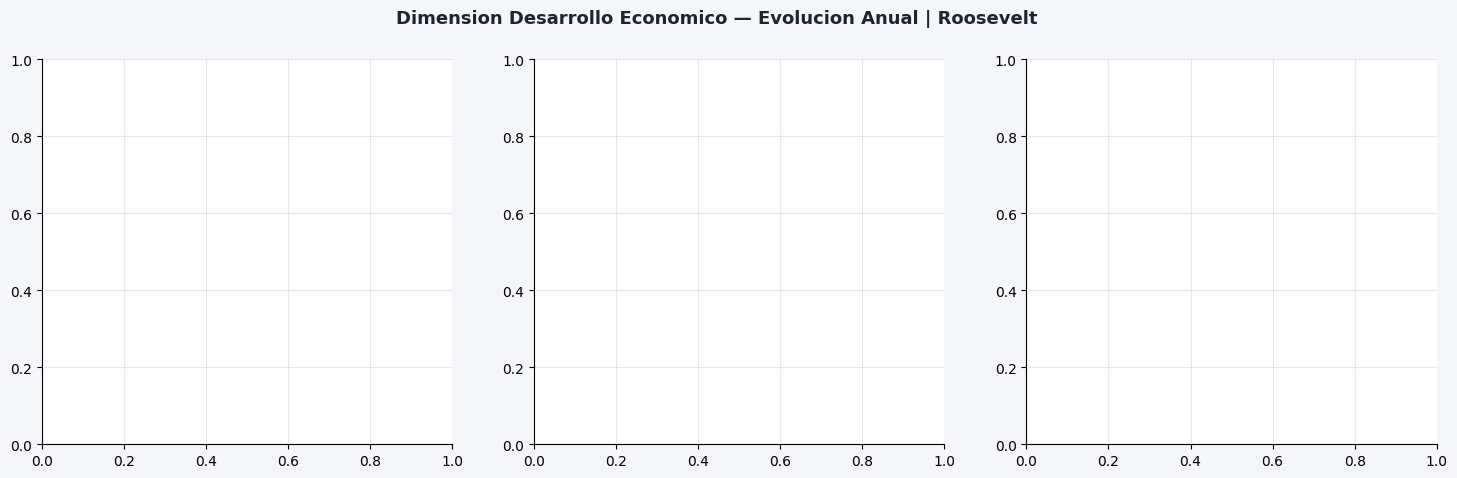

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)
fig.suptitle('Dimension Desarrollo Economico — Evolucion Anual | Roosevelt',
             fontsize=13, fontweight='bold', color='#1B2631')

df_e = df_de_scores.set_index('año').reindex(ANIOS_DE)
x    = np.arange(len(ANIOS_DE))
W    = 0.5

cfg = [
    ('negocios_nuevos', 'Creacion de Negocios Nuevos',      OKI_AZUL,    'Negocios', None),
    ('personal_nuevos', 'Personal Ocupado (Nuevos Negocios)',OKI_VERDE,   'Personas', None),
    ('ingresos_nuevos', 'Ingresos Reportados ($M)',          OKI_NARANJA, 'Pesos',    1e6),
]

for ax, (col, titulo, color, ylabel, divisor) in zip(axes, cfg):
    ax.set_facecolor('white')
    vals = df_e[col].values.astype(float)
    display_vals = vals / divisor if divisor else vals
    bars = ax.bar(x, display_vals, color=color, alpha=0.85, edgecolor='white', width=W)
    for bar, v in zip(bars, display_vals):
        if not np.isnan(v) and v > 0:
            label = f'${v:.0f}M' if divisor else f'{int(v)}'
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(display_vals)*0.02,
                    label, ha='center', va='bottom', fontsize=11, fontweight='bold', color=color)
    ax.set_xticks(x); ax.set_xticklabels([str(a) for a in ANIOS_DE], fontsize=11, fontweight='bold')
    ax.set_title(titulo, fontweight='bold', pad=10)
    ax.set_ylabel('$M COP' if divisor else ylabel)
    ax.spines[['top','right']].set_visible(False)
    ax.set_ylim(0, max(display_vals)*1.25 if max(display_vals) > 0 else 1)
    if col == 'ingresos_nuevos':
        ax.text(0.5, -0.12, '* Ingresos autodeclarados al momento del registro — $0 no implica inactividad',
                transform=ax.transAxes, ha='center', fontsize=7.5, color='#888888', style='italic')
plt.tight_layout()
plt.savefig('itt_roosevelt_de_evolucion.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

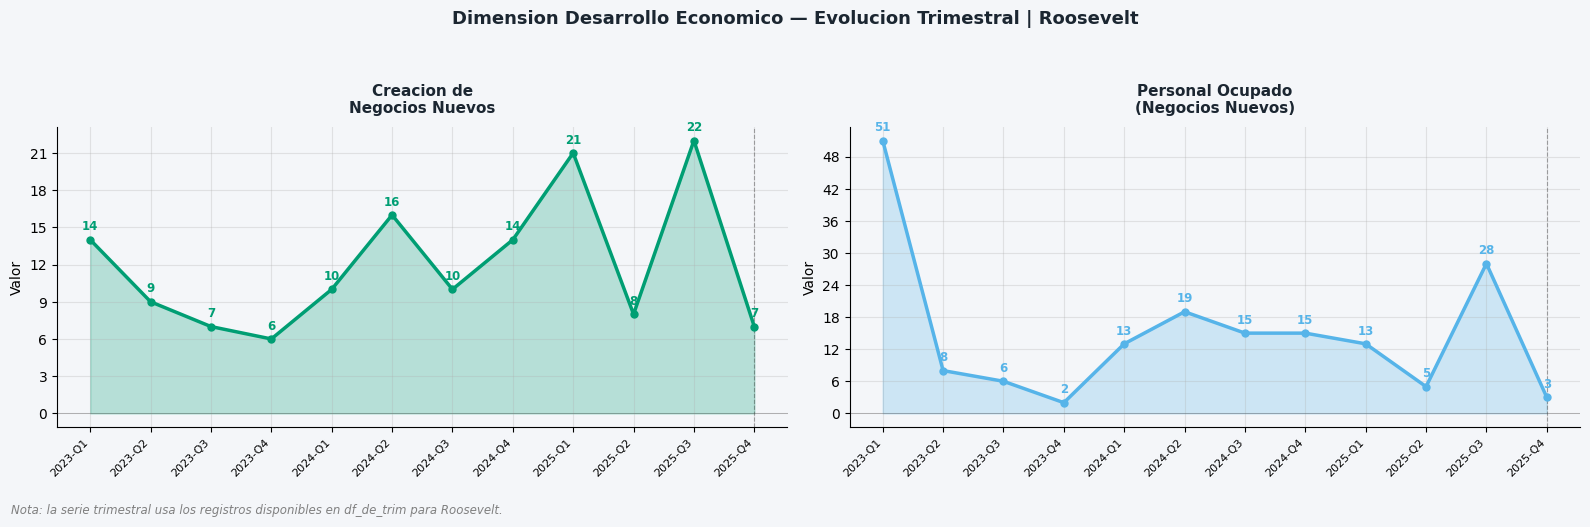

In [ ]:
_de_trim = df_de_trim.copy()
_de_trim = _de_trim.sort_values(['año', 'trimestre']).reset_index(drop=True)
_periodos = _de_trim['periodo'].tolist()
_x = np.arange(len(_periodos))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.2), facecolor=BG)
fig.suptitle(
    'Dimension Desarrollo Economico — Evolucion Trimestral | Roosevelt',
    fontsize=13, fontweight='bold', color='#1B2631'
)

cfg_de = [
    (axes[0], 'negocios_nuevos', 'Creacion de\nNegocios Nuevos', OKI_VERDE,  lambda v: f'{int(v)}'),
    (axes[1], 'personal_nuevos', 'Personal Ocupado\n(Negocios Nuevos)', OKI_AZUL_C, lambda v: f'{int(v)}'),
]

for ax, col, titulo, color, fmt_fn in cfg_de:
    vals = _de_trim[col].values.astype(float)
    valid = ~pd.isna(vals)

    ax.fill_between(_x, np.where(valid, vals, np.nan), alpha=0.25, color=color)
    ax.plot(
        _x, np.where(valid, vals, np.nan),
        color=color, linewidth=2.5, marker='o', markersize=5, zorder=3
    )

    for i, v in enumerate(vals):
        if pd.notna(v) and v > 0:
            ax.annotate(
                fmt_fn(v), (i, v),
                textcoords='offset points', xytext=(0, 7),
                ha='center', fontsize=8.5, fontweight='bold', color=color
            )

    ultimo = max(i for i, v in enumerate(vals) if pd.notna(v))
    ax.axvline(ultimo, color=OKI_GRIS, linewidth=0.8, linestyle='--', alpha=0.4)

    ax.set_xticks(_x)
    ax.set_xticklabels(_periodos, rotation=45, ha='right', fontsize=8)
    ax.set_title(titulo, fontsize=11, pad=10, fontweight='bold', color='#1B2631')
    ax.set_ylabel('Valor')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
    ax.set_facecolor(BG)

fig.text(
    0.01, 0.01,
    'Nota: la serie trimestral usa los registros disponibles en df_de_trim para Roosevelt.',
    fontsize=8.5, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig('itt_roosevelt_de_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


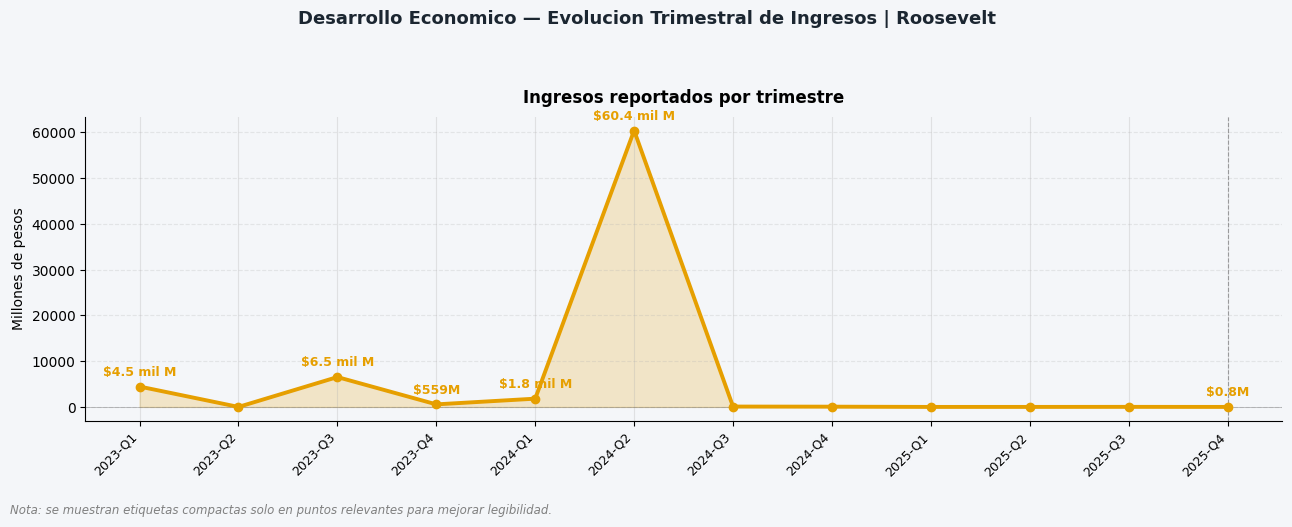

In [ ]:
_ing = df_de_trim.copy()
_ing = _ing.sort_values(['año', 'trimestre']).reset_index(drop=True)
_ing['ingresos_m'] = _ing['ingresos_nuevos'] / 1e6

_periodos = _ing['periodo'].tolist()
_x = np.arange(len(_periodos))
_vals = _ing['ingresos_m'].values.astype(float)
_valid = ~pd.isna(_vals)

def fmt_compacto(v):
    if v >= 1000:
        return f'${v/1000:.1f} mil M'
    if v >= 100:
        return f'${v:.0f}M'
    if v >= 10:
        return f'${v:.1f}M'
    if v >= 1:
        return f'${v:.1f}M'
    return f'${v:.1f}M'

fig, ax = plt.subplots(figsize=(13, 5.2), facecolor=BG)
fig.suptitle(
    'Desarrollo Economico — Evolucion Trimestral de Ingresos | Roosevelt',
    fontsize=13, fontweight='bold', color='#1B2631'
)

ax.fill_between(_x, np.where(_valid, _vals, np.nan), alpha=0.20, color=OKI_NARANJA)
ax.plot(
    _x, np.where(_valid, _vals, np.nan),
    color=OKI_NARANJA, linewidth=2.8, marker='o', markersize=6, zorder=3
)

# Etiquetar solo puntos visibles/relevantes
for i, v in enumerate(_vals):
    if not pd.notna(v) or v <= 0:
        continue

    es_max = v == np.nanmax(_vals)
    es_relevante = v >= 100
    es_ultimo = i == len(_vals) - 1

    if es_max or es_relevante or es_ultimo:
        ax.annotate(
            fmt_compacto(v), (i, v),
            textcoords='offset points', xytext=(0, 8),
            ha='center', fontsize=9, fontweight='bold', color=OKI_NARANJA
        )

ultimo = max(i for i, v in enumerate(_vals) if pd.notna(v))
ax.axvline(ultimo, color=OKI_GRIS, linewidth=0.8, linestyle='--', alpha=0.4)

ax.set_xticks(_x)
ax.set_xticklabels(_periodos, rotation=45, ha='right', fontsize=9)
ax.set_title('Ingresos reportados por trimestre', pad=10, fontweight='bold')
ax.set_ylabel('Millones de pesos')
ax.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.set_facecolor(BG)

fig.text(
    0.01, 0.01,
    'Nota: se muestran etiquetas compactas solo en puntos relevantes para mejorar legibilidad.',
    fontsize=8.5, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.savefig('itt_roosevelt_ingresos_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


In [ ]:
# ── Celda DE-3B: verificacion del score oficial de Actividad Economica ──────
# Requiere:
# - df_de_scores ya creado en DE-3
# - base ya actualizado

# Recalcular ITT con los 5 scores definitivos
def _itt_row(row):
    dims = {
        'Seguridad': row.get('score_seguridad', np.nan),
        'Movilidad': row.get('score_movilidad', np.nan),
        'DesSocial': row.get('score_des_social', np.nan),
        'EntornoU':  row.get('score_entorno_u', np.nan),
        'DesEco':    row.get('score_des_eco',   np.nan),
    }
    disponibles = {k: v for k, v in dims.items() if not pd.isna(v)}
    if len(disponibles) == 0:
        return np.nan
    wsum = sum(PESOS[k] for k in disponibles.keys())
    return sum(PESOS[k] * disponibles[k] for k in disponibles.keys()) / wsum

base['ITT'] = base.apply(_itt_row, axis=1)
base['nivel'] = base['ITT'].apply(clasificar)

print("Scores Desarrollo Economico por año — verificacion oficial ITT:")
cols_sc = [
    'año', 'tipo_dato', 'establecimientos_activos', 'empleabilidad_total',
    'ingresos_operacionales', 'negocios_con_ingreso', 'score_establecimientos',
    'score_empleabilidad', 'score_ingresos', 'score_des_eco'
]
print(df_de_scores[cols_sc].round(2).to_string(index=False))
print()

print("ITT actualizado — 5 dimensiones:")
cols_b = [
    'año', 'score_seguridad', 'score_movilidad', 'score_des_social',
    'score_entorno_u', 'score_des_eco', 'ITT', 'nivel'
]
print(base[cols_b].round(1).to_string(index=False))

2026 DesEco provisional: carry-forward 2025 = 92.4
Scores Desarrollo Economico por año (flujo + stock activo proxy):
 año  negocios_nuevos  personal_stock  ingresos_stock  personal_log1p  ingresos_log1p  score_negocios  score_personal  score_ingresos  score_des_eco
2023             36.0          3715.0    6.139424e+11            8.22           27.14           48.00           100.0           100.0          82.67
2024             50.0          3777.0    6.763077e+11            8.24           27.24           66.67           100.0           100.0          88.89
2025             58.0          3826.0    6.763257e+11            8.25           27.24           77.33           100.0           100.0          92.44

ITT actualizado — 5 dimensiones:
 año  score_seguridad  score_movilidad  score_des_social  score_entorno_u  score_des_eco  ITT          nivel
2023             58.5             49.4              60.0             76.5           82.7 63.5 Transformacion
2024             59.0             6

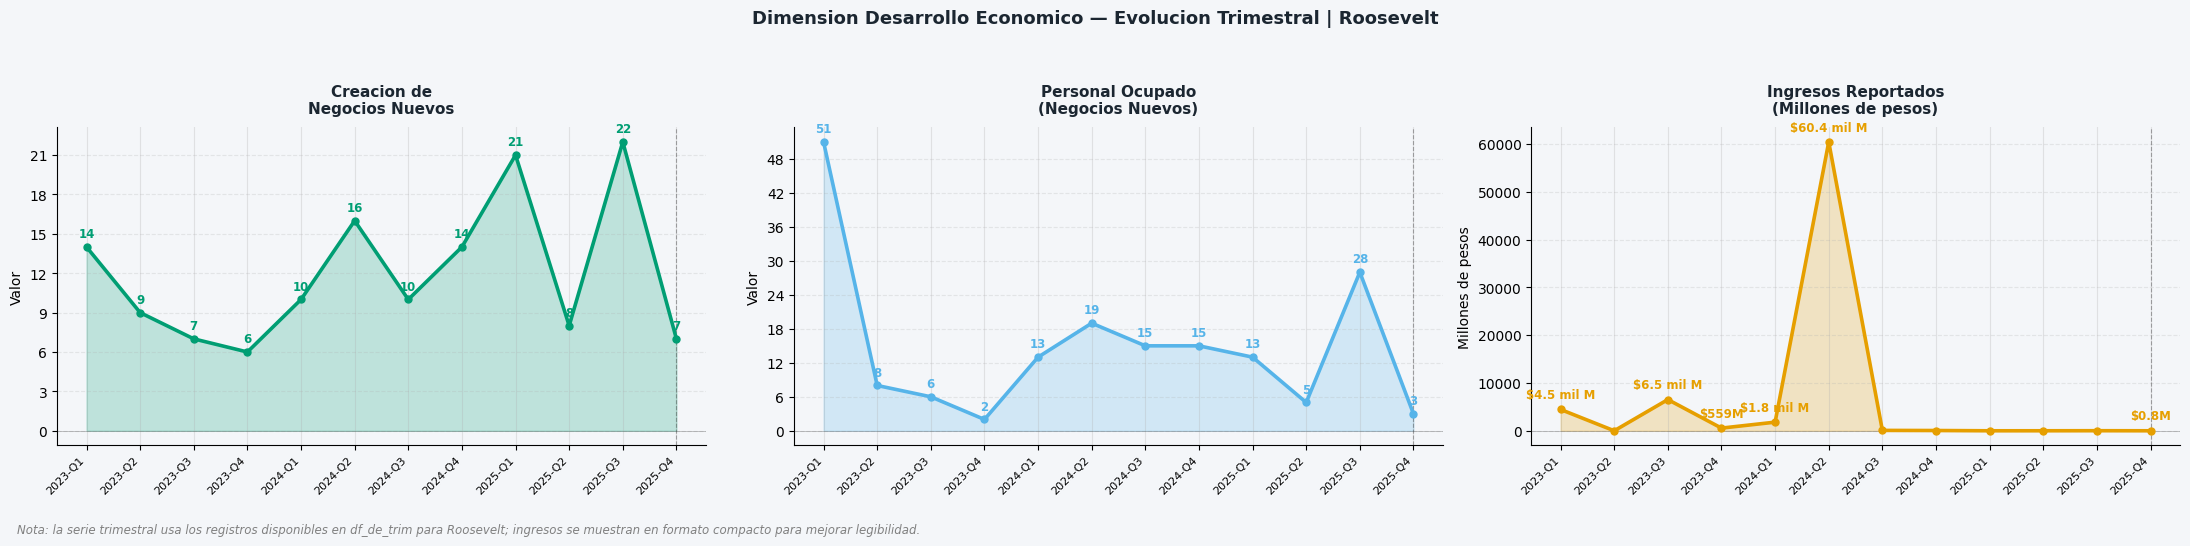

In [ ]:
_de_trim = df_de_trim.copy()
_de_trim = _de_trim.sort_values(['año', 'trimestre']).reset_index(drop=True)
_de_trim['ingresos_m'] = _de_trim['ingresos_nuevos'] / 1e6

_periodos = _de_trim['periodo'].tolist()
_x = np.arange(len(_periodos))

def fmt_ing_compacto(v):
    if v >= 1000:
        return f'${v/1000:.1f} mil M'
    if v >= 100:
        return f'${v:.0f}M'
    if v >= 10:
        return f'${v:.1f}M'
    if v >= 1:
        return f'${v:.1f}M'
    return f'${v:.1f}M'

fig, axes = plt.subplots(1, 3, figsize=(22, 5.4), facecolor=BG)
fig.suptitle(
    'Dimension Desarrollo Economico — Evolucion Trimestral | Roosevelt',
    fontsize=13, fontweight='bold', color='#1B2631'
)

cfg_de = [
    (axes[0], 'negocios_nuevos', 'Creacion de\nNegocios Nuevos', OKI_VERDE, lambda v: f'{int(v)}', False),
    (axes[1], 'personal_nuevos', 'Personal Ocupado\n(Negocios Nuevos)', OKI_AZUL_C, lambda v: f'{int(v)}', False),
    (axes[2], 'ingresos_m', 'Ingresos Reportados\n(Millones de pesos)', OKI_NARANJA, fmt_ing_compacto, True),
]

for ax, col, titulo, color, fmt_fn, es_ing in cfg_de:
    vals = _de_trim[col].values.astype(float)
    valid = ~pd.isna(vals)

    ax.fill_between(_x, np.where(valid, vals, np.nan), alpha=0.22, color=color)
    ax.plot(
        _x, np.where(valid, vals, np.nan),
        color=color, linewidth=2.6, marker='o', markersize=5, zorder=3
    )

    for i, v in enumerate(vals):
        if not pd.notna(v) or v <= 0:
            continue

        if es_ing:
            es_max = v == np.nanmax(vals)
            es_relevante = v >= 100
            es_ultimo = i == len(vals) - 1
            if es_max or es_relevante or es_ultimo:
                ax.annotate(
                    fmt_fn(v), (i, v),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=8.5, fontweight='bold', color=color
                )
        else:
            ax.annotate(
                fmt_fn(v), (i, v),
                textcoords='offset points', xytext=(0, 7),
                ha='center', fontsize=8.5, fontweight='bold', color=color
            )

    ultimo = max(i for i, v in enumerate(vals) if pd.notna(v))
    ax.axvline(ultimo, color=OKI_GRIS, linewidth=0.8, linestyle='--', alpha=0.4)

    ax.set_xticks(_x)
    ax.set_xticklabels(_periodos, rotation=45, ha='right', fontsize=8)
    ax.set_title(titulo, fontsize=11, pad=10, fontweight='bold', color='#1B2631')
    ax.set_ylabel('Valor' if not es_ing else 'Millones de pesos')
    ax.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
    ax.grid(axis='y', linestyle='--', alpha=0.25)
    ax.set_facecolor(BG)

    if not es_ing:
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

fig.text(
    0.01, 0.01,
    'Nota: la serie trimestral usa los registros disponibles en df_de_trim para Roosevelt; ingresos se muestran en formato compacto para mejorar legibilidad.',
    fontsize=8.5, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.93])
plt.savefig('itt_roosevelt_de_trim_3series.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

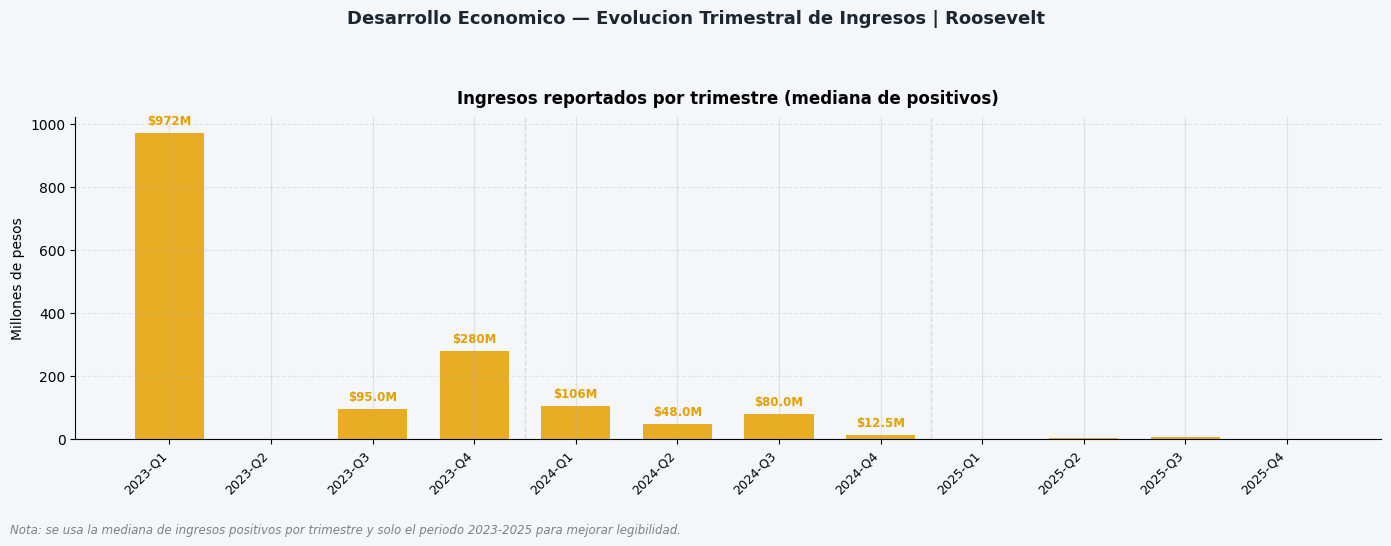

Resumen trimestral de ingresos (mediana positivos):


,periodo,negocios_con_ingreso,ingreso_mediano,ingreso_mediano_m
0,2023-Q1,4,971747292.0,971.747292
1,2023-Q2,0,NaN,NaN
2,2023-Q3,3,95000000.0,95.000000
3,2023-Q4,2,279500000.0,279.500000
4,2024-Q1,3,105807555.0,105.807555
5,2024-Q2,5,48000000.0,48.000000
6,2024-Q3,1,80000000.0,80.000000
7,2024-Q4,4,12500000.0,12.500000
8,2025-Q1,0,NaN,NaN
9,2025-Q2,1,3000000.0,3.000000


In [ ]:
# ── Celda DE-TRIM-ING: Ingresos trimestrales robustos | Roosevelt limpio ────
# Mediana de ingresos positivos por trimestre
# Solo 2023-2025 para mantener legibilidad y comparabilidad

_df_ing = df_de.copy()

if 'trim_mat' not in _df_ing.columns:
    _df_ing['trim_mat'] = _df_ing['fecha_mat'].dt.quarter
if 'anio_mat' not in _df_ing.columns:
    _df_ing['anio_mat'] = _df_ing['fecha_mat'].dt.year

_df_ing['ingresos_pos'] = pd.to_numeric(_df_ing['INGRESOS_A'], errors='coerce')
_df_ing.loc[_df_ing['ingresos_pos'] <= 0, 'ingresos_pos'] = np.nan

ANIOS_ING = [2023, 2024, 2025]

rows_ing_trim = []
for ano in ANIOS_ING:
    for trim in [1, 2, 3, 4]:
        sub = _df_ing[(_df_ing['anio_mat'] == ano) & (_df_ing['trim_mat'] == trim)].copy()
        med = float(sub['ingresos_pos'].median()) if sub['ingresos_pos'].notna().any() else np.nan
        n_pos = int(sub['ingresos_pos'].notna().sum())

        rows_ing_trim.append({
            'periodo': f'{ano}-Q{trim}',
            'año': ano,
            'trimestre': trim,
            'negocios_con_ingreso': n_pos,
            'ingreso_mediano': med,
            'ingreso_mediano_m': med / 1e6 if pd.notna(med) else np.nan
        })

df_ing_trim = pd.DataFrame(rows_ing_trim)

_periodos = df_ing_trim['periodo'].tolist()
_x = np.arange(len(_periodos))
_vals = df_ing_trim['ingreso_mediano_m'].values.astype(float)

def fmt_compacto(v):
    if v >= 1000:
        return f'${v/1000:.1f} mil M'
    if v >= 100:
        return f'${v:.0f}M'
    if v >= 10:
        return f'${v:.1f}M'
    return f'${v:.1f}M'

fig, ax = plt.subplots(figsize=(14, 5.4), facecolor=BG)
fig.suptitle(
    'Desarrollo Economico — Evolucion Trimestral de Ingresos | Roosevelt',
    fontsize=13, fontweight='bold', color='#1B2631'
)

# Barras por trimestre
bars = ax.bar(_x, np.nan_to_num(_vals, nan=0.0), color=OKI_NARANJA, alpha=0.85, width=0.68)

# Etiquetar solo valores relevantes
for i, v in enumerate(_vals):
    if not pd.notna(v) or v <= 0:
        continue

    es_max = v == np.nanmax(_vals)
    es_relevante = v >= 10

    if es_max or es_relevante:
        ax.annotate(
            fmt_compacto(v),
            (i, v),
            textcoords='offset points',
            xytext=(0, 6),
            ha='center',
            fontsize=8.5,
            fontweight='bold',
            color=OKI_NARANJA
        )

# Separadores por año
for cut in [3.5, 7.5]:
    ax.axvline(cut, color='#D0D7DE', linewidth=1.0, linestyle='--', alpha=0.8)

ax.set_xticks(_x)
ax.set_xticklabels(_periodos, rotation=45, ha='right', fontsize=9)
ax.set_title('Ingresos reportados por trimestre (mediana de positivos)', pad=10, fontweight='bold')
ax.set_ylabel('Millones de pesos')
ax.axhline(0, color=OKI_GRIS, linewidth=0.6, alpha=0.5)
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.set_facecolor(BG)

fig.text(
    0.01, 0.01,
    'Nota: se usa la mediana de ingresos positivos por trimestre y solo el periodo 2023-2025 para mejorar legibilidad.',
    fontsize=8.5, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.05, 1, 0.92])
plt.savefig('itt_roosevelt_ingresos_trim_mediana_limpio.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('Resumen trimestral de ingresos (mediana positivos):')
display(df_ing_trim[['periodo', 'negocios_con_ingreso', 'ingreso_mediano', 'ingreso_mediano_m']])

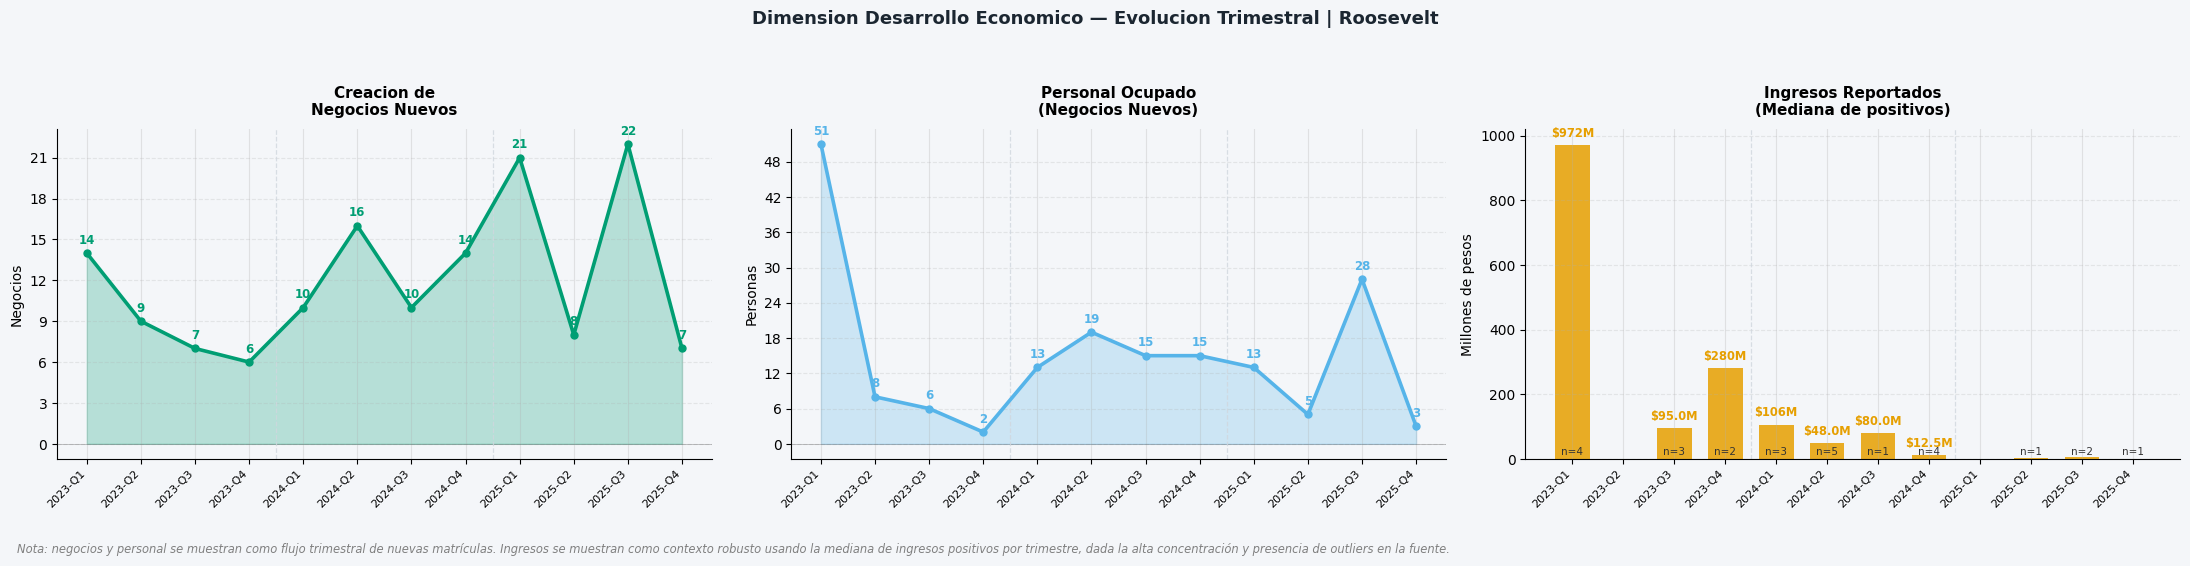

In [ ]:
# ── Celda DE-TRIM-VIS: Desarrollo Economico trimestral | Roosevelt ───────────
# Lógica:
# - Negocios nuevos: flujo trimestral
# - Personal ocupado: flujo trimestral asociado a nuevos negocios
# - Ingresos reportados: contexto trimestral robusto (mediana de ingresos positivos)
# Nota: el panel de ingresos es descriptivo/contextual, no un score trimestral fuerte.

import re

# ---------- Base flujo trimestral (negocios + personal) ----------
_de_trim = df_de_trim.copy()
_de_trim = _de_trim[_de_trim['año'].isin([2023, 2024, 2025])].copy()
_de_trim = _de_trim.sort_values(['año', 'trimestre']).reset_index(drop=True)

_periodos = _de_trim['periodo'].tolist()
_x = np.arange(len(_periodos))

# ---------- Serie robusta para ingresos ----------
_df_ing = df_de.copy()

# Asegurar columnas de fecha
if 'fecha_mat' not in _df_ing.columns:
    meses_es = {
        'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
        'julio': 7, 'agosto': 8, 'septiembre': 9, 'setiembre': 9,
        'octubre': 10, 'noviembre': 11, 'diciembre': 12
    }

    def parse_fecha_es_de_local(txt):
        if pd.isna(txt):
            return pd.NaT
        s = str(txt).strip().lower()
        m = re.search(r'(\d{1,2}) de ([a-záéíóú]+) de (\d{4})', s)
        if not m:
            return pd.NaT
        dia = int(m.group(1))
        mes_txt = (m.group(2)
                   .replace('á', 'a').replace('é', 'e')
                   .replace('í', 'i').replace('ó', 'o').replace('ú', 'u'))
        mes = meses_es.get(mes_txt)
        ano = int(m.group(3))
        if mes is None:
            return pd.NaT
        return pd.Timestamp(year=ano, month=mes, day=dia)

    _df_ing['fecha_mat'] = _df_ing['Mes_Dia_An'].apply(parse_fecha_es_de_local)

if 'anio_mat' not in _df_ing.columns:
    _df_ing['anio_mat'] = _df_ing['fecha_mat'].dt.year

if 'trim_mat' not in _df_ing.columns:
    _df_ing['trim_mat'] = _df_ing['fecha_mat'].dt.quarter

_df_ing['ingresos_pos'] = pd.to_numeric(_df_ing['INGRESOS_A'], errors='coerce')
_df_ing.loc[_df_ing['ingresos_pos'] <= 0, 'ingresos_pos'] = np.nan

rows_ing = []
for ano in [2023, 2024, 2025]:
    for trim in [1, 2, 3, 4]:
        sub = _df_ing[(_df_ing['anio_mat'] == ano) & (_df_ing['trim_mat'] == trim)].copy()
        med = float(sub['ingresos_pos'].median()) if sub['ingresos_pos'].notna().any() else np.nan
        n_pos = int(sub['ingresos_pos'].notna().sum())
        rows_ing.append({
            'periodo': f'{ano}-Q{trim}',
            'año': ano,
            'trimestre': trim,
            'negocios_con_ingreso': n_pos,
            'ingreso_mediano': med,
            'ingreso_mediano_m': med / 1e6 if pd.notna(med) else np.nan
        })

df_ing_trim_ctx = pd.DataFrame(rows_ing).sort_values(['año', 'trimestre']).reset_index(drop=True)

def fmt_ing(v):
    if v >= 1000:
        return f'${v/1000:.1f} mil M'
    if v >= 100:
        return f'${v:.0f}M'
    if v >= 10:
        return f'${v:.1f}M'
    return f'${v:.1f}M'

# ---------- Figura ----------
fig, axes = plt.subplots(1, 3, figsize=(22, 5.6), facecolor=BG)
fig.suptitle(
    'Dimension Desarrollo Economico — Evolucion Trimestral | Roosevelt',
    fontsize=13, fontweight='bold', color='#1B2631'
)

# 1) Negocios nuevos
vals_neg = _de_trim['negocios_nuevos'].values.astype(float)
axes[0].fill_between(_x, vals_neg, alpha=0.25, color=OKI_VERDE)
axes[0].plot(_x, vals_neg, color=OKI_VERDE, linewidth=2.6, marker='o', markersize=5, zorder=3)

for i, v in enumerate(vals_neg):
    if pd.notna(v) and v > 0:
        axes[0].annotate(
            f'{int(v)}', (i, v),
            textcoords='offset points', xytext=(0, 7),
            ha='center', fontsize=8.5, fontweight='bold', color=OKI_VERDE
        )

axes[0].set_title('Creacion de\nNegocios Nuevos', fontsize=11, pad=10, fontweight='bold')
axes[0].set_xticks(_x)
axes[0].set_xticklabels(_periodos, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Negocios')
axes[0].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[0].axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
axes[0].grid(axis='y', linestyle='--', alpha=0.25)
axes[0].set_facecolor(BG)

# 2) Personal nuevos
vals_pers = _de_trim['personal_nuevos'].values.astype(float)
axes[1].fill_between(_x, vals_pers, alpha=0.25, color=OKI_AZUL_C)
axes[1].plot(_x, vals_pers, color=OKI_AZUL_C, linewidth=2.6, marker='o', markersize=5, zorder=3)

for i, v in enumerate(vals_pers):
    if pd.notna(v) and v > 0:
        axes[1].annotate(
            f'{int(v)}', (i, v),
            textcoords='offset points', xytext=(0, 7),
            ha='center', fontsize=8.5, fontweight='bold', color=OKI_AZUL_C
        )

axes[1].set_title('Personal Ocupado\n(Negocios Nuevos)', fontsize=11, pad=10, fontweight='bold')
axes[1].set_xticks(_x)
axes[1].set_xticklabels(_periodos, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Personas')
axes[1].yaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[1].axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
axes[1].grid(axis='y', linestyle='--', alpha=0.25)
axes[1].set_facecolor(BG)

# 3) Ingresos reportados (contexto robusto)
vals_ing = df_ing_trim_ctx['ingreso_mediano_m'].values.astype(float)
bars = axes[2].bar(_x, np.nan_to_num(vals_ing, nan=0.0), color=OKI_NARANJA, alpha=0.85, width=0.68)

for i, v in enumerate(vals_ing):
    if not pd.notna(v) or v <= 0:
        continue
    es_max = v == np.nanmax(vals_ing)
    es_relevante = v >= 10
    if es_max or es_relevante:
        axes[2].annotate(
            fmt_ing(v), (i, v),
            textcoords='offset points', xytext=(0, 6),
            ha='center', fontsize=8.3, fontweight='bold', color=OKI_NARANJA
        )

# Anotar n de negocios con ingreso positivo abajo de cada barra relevante
for i, n in enumerate(df_ing_trim_ctx['negocios_con_ingreso'].values):
    if n > 0:
        axes[2].annotate(
            f'n={int(n)}', (i, 0),
            textcoords='offset points', xytext=(0, 3),
            ha='center', fontsize=7.5, color=OKI_GRIS
        )

axes[2].set_title('Ingresos Reportados\n(Mediana de positivos)', fontsize=11, pad=10, fontweight='bold')
axes[2].set_xticks(_x)
axes[2].set_xticklabels(_periodos, rotation=45, ha='right', fontsize=8)
axes[2].set_ylabel('Millones de pesos')
axes[2].axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
axes[2].grid(axis='y', linestyle='--', alpha=0.25)
axes[2].set_facecolor(BG)

# separadores por año
for ax in axes:
    for cut in [3.5, 7.5]:
        ax.axvline(cut, color='#D0D7DE', linewidth=0.9, linestyle='--', alpha=0.8)

fig.text(
    0.01, 0.01,
    'Nota: negocios y personal se muestran como flujo trimestral de nuevas matrículas. Ingresos se muestran como contexto robusto usando la mediana de ingresos positivos por trimestre, dada la alta concentración y presencia de outliers en la fuente.',
    fontsize=8.3, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.06, 1, 0.93])
plt.savefig('itt_roosevelt_de_trim_contextual.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

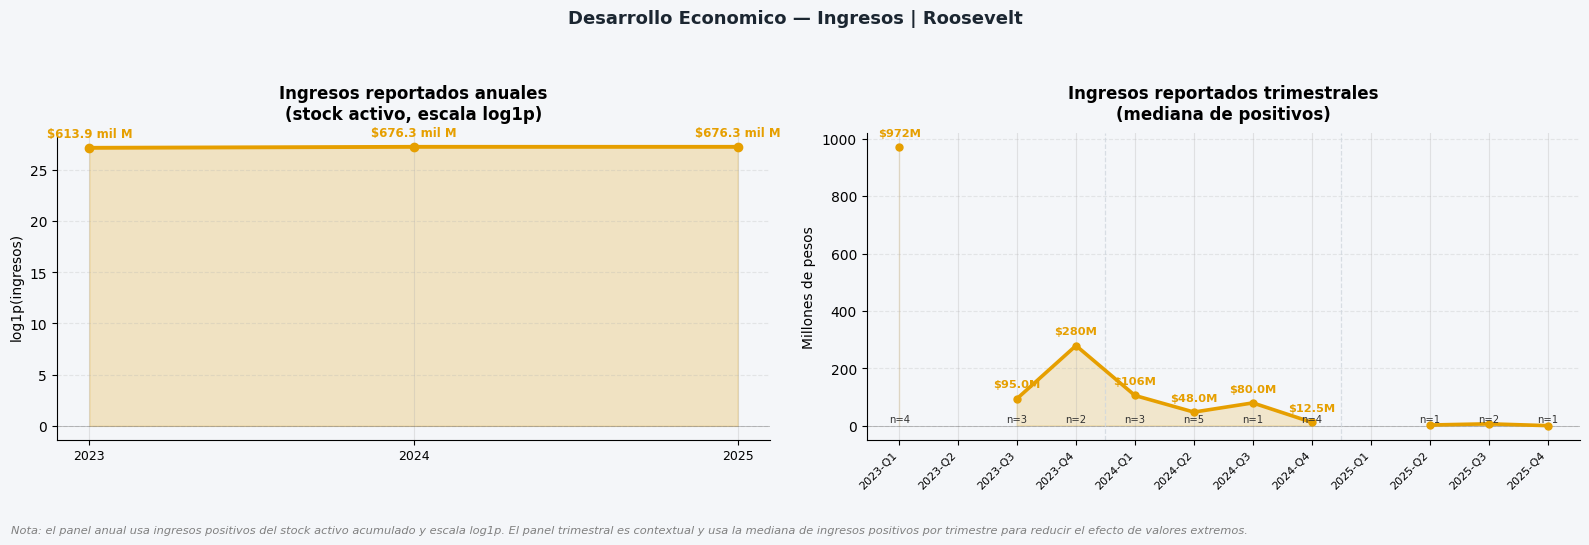

Resumen anual:


,año,ingresos_stock,ingresos_stock_m,ingresos_log1p
0,2023,6.139424e+11,613942.412587,27.143167
1,2024,6.763077e+11,676307.695918,27.239914
2,2025,6.763257e+11,676325.745918,27.239941


Resumen trimestral:


,periodo,negocios_con_ingreso,ingreso_mediano,ingreso_mediano_m
0,2023-Q1,4,971747292.0,971.747292
1,2023-Q2,0,NaN,NaN
2,2023-Q3,3,95000000.0,95.000000
3,2023-Q4,2,279500000.0,279.500000
4,2024-Q1,3,105807555.0,105.807555
5,2024-Q2,5,48000000.0,48.000000
6,2024-Q3,1,80000000.0,80.000000
7,2024-Q4,4,12500000.0,12.500000
8,2025-Q1,0,NaN,NaN
9,2025-Q2,1,3000000.0,3.000000


In [ ]:
# ── Celda DE-ING-VIS: Ingresos | anual robusto + trimestral contextual ──────
# Requiere:
# - df_de ya cargado
# - BG, OKI_NARANJA, OKI_GRIS ya definidos

import re

_df = df_de.copy()

# ---------- Asegurar fecha / año / trimestre ----------
if 'fecha_mat' not in _df.columns:
    meses_es = {
        'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
        'julio': 7, 'agosto': 8, 'septiembre': 9, 'setiembre': 9,
        'octubre': 10, 'noviembre': 11, 'diciembre': 12
    }

    def parse_fecha_es(txt):
        if pd.isna(txt):
            return pd.NaT
        s = str(txt).strip().lower()
        m = re.search(r'(\d{1,2}) de ([a-záéíóú]+) de (\d{4})', s)
        if not m:
            return pd.NaT
        dia = int(m.group(1))
        mes_txt = (m.group(2)
                   .replace('á', 'a').replace('é', 'e')
                   .replace('í', 'i').replace('ó', 'o').replace('ú', 'u'))
        mes = meses_es.get(mes_txt)
        ano = int(m.group(3))
        return pd.Timestamp(year=ano, month=mes, day=dia) if mes else pd.NaT

    _df['fecha_mat'] = _df['Mes_Dia_An'].apply(parse_fecha_es)

if 'anio_mat' not in _df.columns:
    _df['anio_mat'] = _df['fecha_mat'].dt.year

if 'trim_mat' not in _df.columns:
    _df['trim_mat'] = _df['fecha_mat'].dt.quarter

_df['ingresos_pos'] = pd.to_numeric(_df['INGRESOS_A'], errors='coerce')
_df.loc[_df['ingresos_pos'] <= 0, 'ingresos_pos'] = np.nan

# ---------- Serie anual robusta: stock activo acumulado ----------
ANIOS_ING = [2023, 2024, 2025]

rows_anual = []
for ano in ANIOS_ING:
    sub_stock = _df[_df['anio_mat'] <= ano].copy()
    ing_stock = float(sub_stock['ingresos_pos'].sum(skipna=True)) if len(sub_stock) > 0 else np.nan
    ing_log = float(np.log1p(ing_stock)) if pd.notna(ing_stock) and ing_stock > 0 else np.nan
    rows_anual.append({
        'año': ano,
        'ingresos_stock': ing_stock,
        'ingresos_stock_m': ing_stock / 1e6 if pd.notna(ing_stock) else np.nan,
        'ingresos_log1p': ing_log
    })

df_ing_anual = pd.DataFrame(rows_anual)

# ---------- Serie trimestral contextual: mediana de positivos ----------
rows_trim = []
for ano in ANIOS_ING:
    for trim in [1, 2, 3, 4]:
        sub = _df[(_df['anio_mat'] == ano) & (_df['trim_mat'] == trim)].copy()
        med = float(sub['ingresos_pos'].median()) if sub['ingresos_pos'].notna().any() else np.nan
        n_pos = int(sub['ingresos_pos'].notna().sum())
        rows_trim.append({
            'periodo': f'{ano}-Q{trim}',
            'año': ano,
            'trimestre': trim,
            'negocios_con_ingreso': n_pos,
            'ingreso_mediano': med,
            'ingreso_mediano_m': med / 1e6 if pd.notna(med) else np.nan
        })

df_ing_trim = pd.DataFrame(rows_trim)

# ---------- Formatos ----------
def fmt_compacto_m(v):
    if not pd.notna(v):
        return '—'
    if v >= 1000:
        return f'${v/1000:.1f} mil M'
    if v >= 100:
        return f'${v:.0f}M'
    if v >= 10:
        return f'${v:.1f}M'
    return f'${v:.1f}M'

# ---------- Figura ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 5.4), facecolor=BG)
fig.suptitle(
    'Desarrollo Economico — Ingresos | Roosevelt',
    fontsize=13, fontweight='bold', color='#1B2631'
)

# ── Panel 1: anual robusto ───────────────────────────────────────────────────
ax = axes[0]
x1 = np.arange(len(df_ing_anual))
vals1 = df_ing_anual['ingresos_log1p'].values.astype(float)

ax.fill_between(x1, vals1, alpha=0.22, color=OKI_NARANJA)
ax.plot(
    x1, vals1,
    color=OKI_NARANJA, linewidth=2.8, marker='o', markersize=6, zorder=3
)

for i, row in df_ing_anual.iterrows():
    if pd.notna(row['ingresos_log1p']):
        ax.annotate(
            fmt_compacto_m(row['ingresos_stock_m']),
            (i, row['ingresos_log1p']),
            textcoords='offset points', xytext=(0, 8),
            ha='center', fontsize=8.5, fontweight='bold', color=OKI_NARANJA
        )

ax.set_xticks(x1)
ax.set_xticklabels(df_ing_anual['año'].astype(str), fontsize=9)
ax.set_title('Ingresos reportados anuales\n(stock activo, escala log1p)', pad=10, fontweight='bold')
ax.set_ylabel('log1p(ingresos)')
ax.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.set_facecolor(BG)

# ── Panel 2: trimestral contextual ───────────────────────────────────────────
ax2 = axes[1]
x2 = np.arange(len(df_ing_trim))
vals2 = df_ing_trim['ingreso_mediano_m'].values.astype(float)

ax2.fill_between(x2, np.where(~pd.isna(vals2), vals2, np.nan), alpha=0.18, color=OKI_NARANJA)
ax2.plot(
    x2, np.where(~pd.isna(vals2), vals2, np.nan),
    color=OKI_NARANJA, linewidth=2.6, marker='o', markersize=5, zorder=3
)

for i, row in df_ing_trim.iterrows():
    v = row['ingreso_mediano_m']
    if not pd.notna(v) or v <= 0:
        continue
    es_max = v == np.nanmax(vals2)
    es_relevante = v >= 10
    if es_max or es_relevante:
        ax2.annotate(
            fmt_compacto_m(v),
            (i, v),
            textcoords='offset points', xytext=(0, 8),
            ha='center', fontsize=8.2, fontweight='bold', color=OKI_NARANJA
        )

for i, n in enumerate(df_ing_trim['negocios_con_ingreso'].values):
    if n > 0:
        ax2.annotate(
            f'n={int(n)}',
            (i, 0),
            textcoords='offset points', xytext=(0, 3),
            ha='center', fontsize=7.2, color=OKI_GRIS
        )

ax2.set_xticks(x2)
ax2.set_xticklabels(df_ing_trim['periodo'], rotation=45, ha='right', fontsize=8)
ax2.set_title('Ingresos reportados trimestrales\n(mediana de positivos)', pad=10, fontweight='bold')
ax2.set_ylabel('Millones de pesos')
ax2.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
ax2.grid(axis='y', linestyle='--', alpha=0.25)
ax2.set_facecolor(BG)

for cut in [3.5, 7.5]:
    ax2.axvline(cut, color='#D0D7DE', linewidth=0.9, linestyle='--', alpha=0.8)

fig.text(
    0.01, 0.01,
    'Nota: el panel anual usa ingresos positivos del stock activo acumulado y escala log1p. El panel trimestral es contextual y usa la mediana de ingresos positivos por trimestre para reducir el efecto de valores extremos.',
    fontsize=8.2, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.06, 1, 0.93])
plt.savefig('itt_roosevelt_ingresos_anual_trimestral.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('Resumen anual:')
display(df_ing_anual)

print('Resumen trimestral:')
display(df_ing_trim[['periodo', 'negocios_con_ingreso', 'ingreso_mediano', 'ingreso_mediano_m']])

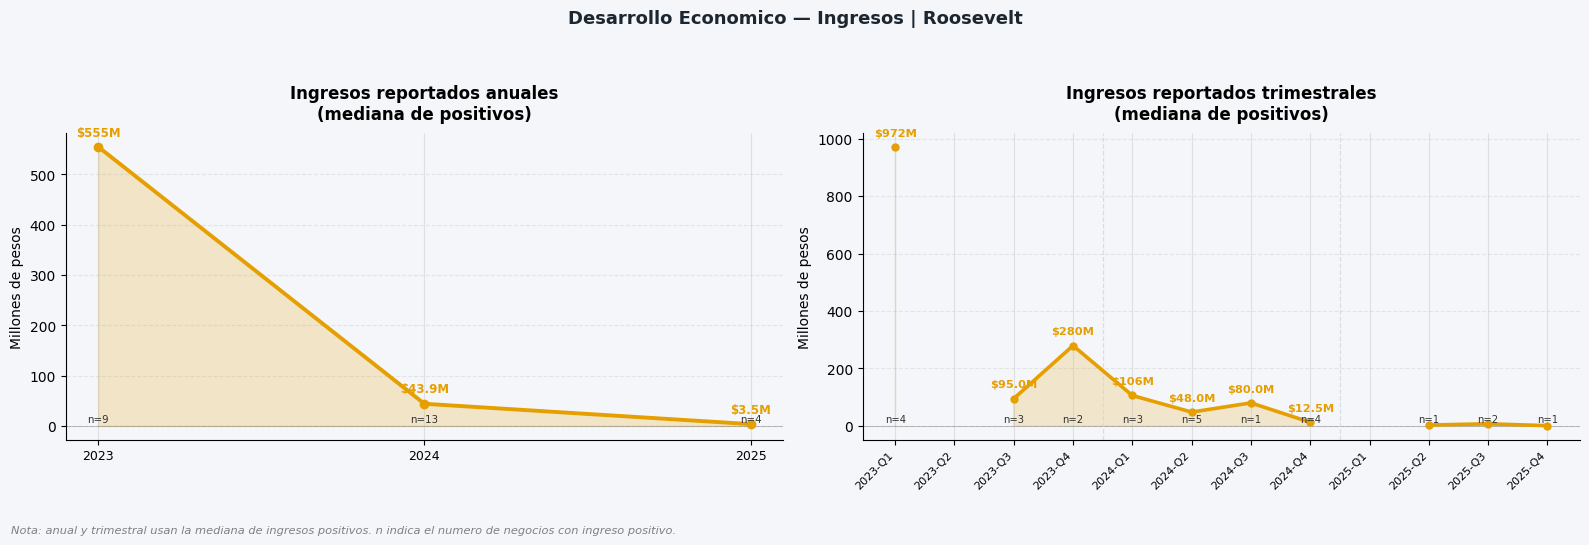

Resumen anual:


,año,negocios_con_ingreso,ingreso_mediano,ingreso_mediano_m
0,2023,9,555000000.0,555.000000
1,2024,13,43942974.0,43.942974
2,2025,4,3500000.0,3.500000


Resumen trimestral:


,periodo,negocios_con_ingreso,ingreso_mediano,ingreso_mediano_m
0,2023-Q1,4,971747292.0,971.747292
1,2023-Q2,0,NaN,NaN
2,2023-Q3,3,95000000.0,95.000000
3,2023-Q4,2,279500000.0,279.500000
4,2024-Q1,3,105807555.0,105.807555
5,2024-Q2,5,48000000.0,48.000000
6,2024-Q3,1,80000000.0,80.000000
7,2024-Q4,4,12500000.0,12.500000
8,2025-Q1,0,NaN,NaN
9,2025-Q2,1,3000000.0,3.000000


In [ ]:
# ── Celda DE-ING-VIS: Ingresos | anual + trimestral robustos ─────────────────
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Fallback por si no existen en la sesion
if 'BG' not in globals():
    BG = '#F4F6F9'
if 'OKI_NARANJA' not in globals():
    OKI_NARANJA = '#E69F00'
if 'OKI_GRIS' not in globals():
    OKI_GRIS = '#333333'

_df = df_de.copy()

# ---------- Resolver columna de fecha ----------
col_fecha = None
for c in _df.columns:
    c_norm = str(c).strip().lower()
    if c_norm in ['mes_dia_an', 'mes_dia_a1', 'fecha_mat']:
        col_fecha = c
        break

if col_fecha is None and 'fecha_mat' not in _df.columns:
    raise KeyError("No encontre una columna de fecha usable: 'Mes_Dia_An', 'Mes_Dia_A1' o 'fecha_mat'.")

# ---------- Asegurar fecha / año / trimestre ----------
if 'fecha_mat' not in _df.columns:
    meses_es = {
        'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
        'julio': 7, 'agosto': 8, 'septiembre': 9, 'setiembre': 9,
        'octubre': 10, 'noviembre': 11, 'diciembre': 12
    }

    def parse_fecha_es(txt):
        if pd.isna(txt):
            return pd.NaT
        s = str(txt).strip().lower()
        m = re.search(r'(\d{1,2}) de ([a-záéíóú]+) de (\d{4})', s)
        if not m:
            return pd.NaT
        dia = int(m.group(1))
        mes_txt = (m.group(2)
                   .replace('á', 'a').replace('é', 'e')
                   .replace('í', 'i').replace('ó', 'o').replace('ú', 'u'))
        mes = meses_es.get(mes_txt)
        ano = int(m.group(3))
        return pd.Timestamp(year=ano, month=mes, day=dia) if mes else pd.NaT

    _df['fecha_mat'] = _df[col_fecha].apply(parse_fecha_es)
else:
    _df['fecha_mat'] = pd.to_datetime(_df['fecha_mat'], errors='coerce')

_df['anio_mat'] = _df['fecha_mat'].dt.year
_df['trim_mat'] = _df['fecha_mat'].dt.quarter

# ---------- Resolver columna de ingresos ----------
col_ing = None
for c in _df.columns:
    if str(c).strip().upper() == 'INGRESOS_A':
        col_ing = c
        break

if col_ing is None:
    raise KeyError("No encontre la columna 'INGRESOS_A' en df_de.")

_df['ingresos_pos'] = pd.to_numeric(_df[col_ing], errors='coerce')
_df.loc[_df['ingresos_pos'] <= 0, 'ingresos_pos'] = np.nan

ANIOS_ING = [2023, 2024, 2025]

# ---------- Serie anual robusta ----------
rows_anual = []
for ano in ANIOS_ING:
    sub = _df[_df['anio_mat'] == ano].copy()
    med = float(sub['ingresos_pos'].median()) if sub['ingresos_pos'].notna().any() else np.nan
    n_pos = int(sub['ingresos_pos'].notna().sum())
    rows_anual.append({
        'año': ano,
        'negocios_con_ingreso': n_pos,
        'ingreso_mediano': med,
        'ingreso_mediano_m': med / 1e6 if pd.notna(med) else np.nan
    })

df_ing_anual = pd.DataFrame(rows_anual)

# ---------- Serie trimestral robusta ----------
rows_trim = []
for ano in ANIOS_ING:
    for trim in [1, 2, 3, 4]:
        sub = _df[(_df['anio_mat'] == ano) & (_df['trim_mat'] == trim)].copy()
        med = float(sub['ingresos_pos'].median()) if sub['ingresos_pos'].notna().any() else np.nan
        n_pos = int(sub['ingresos_pos'].notna().sum())
        rows_trim.append({
            'periodo': f'{ano}-Q{trim}',
            'año': ano,
            'trimestre': trim,
            'negocios_con_ingreso': n_pos,
            'ingreso_mediano': med,
            'ingreso_mediano_m': med / 1e6 if pd.notna(med) else np.nan
        })

df_ing_trim = pd.DataFrame(rows_trim)

def fmt_compacto_m(v):
    if not pd.notna(v):
        return '—'
    if v >= 1000:
        return f'${v/1000:.1f} mil M'
    if v >= 100:
        return f'${v:.0f}M'
    if v >= 10:
        return f'${v:.1f}M'
    return f'${v:.1f}M'

fig, axes = plt.subplots(1, 2, figsize=(16, 5.4), facecolor=BG)
fig.suptitle(
    'Desarrollo Economico — Ingresos | Roosevelt',
    fontsize=13, fontweight='bold', color='#1B2631'
)

# Panel 1
ax = axes[0]
x1 = np.arange(len(df_ing_anual))
vals1 = df_ing_anual['ingreso_mediano_m'].to_numpy(dtype=float)

ax.fill_between(x1, vals1, where=~np.isnan(vals1), alpha=0.20, color=OKI_NARANJA)
ax.plot(x1, vals1, color=OKI_NARANJA, linewidth=2.8, marker='o', markersize=6, zorder=3)

for i, row in df_ing_anual.iterrows():
    v = row['ingreso_mediano_m']
    if pd.notna(v) and v > 0:
        ax.annotate(
            fmt_compacto_m(v), (i, v),
            textcoords='offset points', xytext=(0, 8),
            ha='center', fontsize=8.5, fontweight='bold', color=OKI_NARANJA
        )
        ax.annotate(
            f"n={int(row['negocios_con_ingreso'])}", (i, 0),
            textcoords='offset points', xytext=(0, 3),
            ha='center', fontsize=7.4, color=OKI_GRIS
        )

ax.set_xticks(x1)
ax.set_xticklabels(df_ing_anual['año'].astype(str), fontsize=9)
ax.set_title('Ingresos reportados anuales\n(mediana de positivos)', pad=10, fontweight='bold')
ax.set_ylabel('Millones de pesos')
ax.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.set_facecolor(BG)

# Panel 2
ax2 = axes[1]
x2 = np.arange(len(df_ing_trim))
vals2 = df_ing_trim['ingreso_mediano_m'].to_numpy(dtype=float)

ax2.fill_between(x2, vals2, where=~np.isnan(vals2), alpha=0.18, color=OKI_NARANJA)
ax2.plot(x2, vals2, color=OKI_NARANJA, linewidth=2.6, marker='o', markersize=5, zorder=3)

vals2_valid = vals2[~np.isnan(vals2)]
max_trim = np.nanmax(vals2_valid) if len(vals2_valid) else np.nan

for i, row in df_ing_trim.iterrows():
    v = row['ingreso_mediano_m']
    if not pd.notna(v) or v <= 0:
        continue
    es_max = pd.notna(max_trim) and v == max_trim
    es_relevante = v >= 10
    if es_max or es_relevante:
        ax2.annotate(
            fmt_compacto_m(v), (i, v),
            textcoords='offset points', xytext=(0, 8),
            ha='center', fontsize=8.2, fontweight='bold', color=OKI_NARANJA
        )

for i, n in enumerate(df_ing_trim['negocios_con_ingreso'].values):
    if n > 0:
        ax2.annotate(
            f'n={int(n)}', (i, 0),
            textcoords='offset points', xytext=(0, 3),
            ha='center', fontsize=7.2, color=OKI_GRIS
        )

ax2.set_xticks(x2)
ax2.set_xticklabels(df_ing_trim['periodo'], rotation=45, ha='right', fontsize=8)
ax2.set_title('Ingresos reportados trimestrales\n(mediana de positivos)', pad=10, fontweight='bold')
ax2.set_ylabel('Millones de pesos')
ax2.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
ax2.grid(axis='y', linestyle='--', alpha=0.25)
ax2.set_facecolor(BG)

for cut in [3.5, 7.5]:
    ax2.axvline(cut, color='#D0D7DE', linewidth=0.9, linestyle='--', alpha=0.8)

fig.text(
    0.01, 0.01,
    'Nota: anual y trimestral usan la mediana de ingresos positivos. n indica el numero de negocios con ingreso positivo.',
    fontsize=8.2, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.06, 1, 0.93])
plt.savefig('itt_roosevelt_ingresos_anual_trimestral_mediana.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('Resumen anual:')
display(df_ing_anual)

print('Resumen trimestral:')
display(df_ing_trim[['periodo', 'negocios_con_ingreso', 'ingreso_mediano', 'ingreso_mediano_m']])

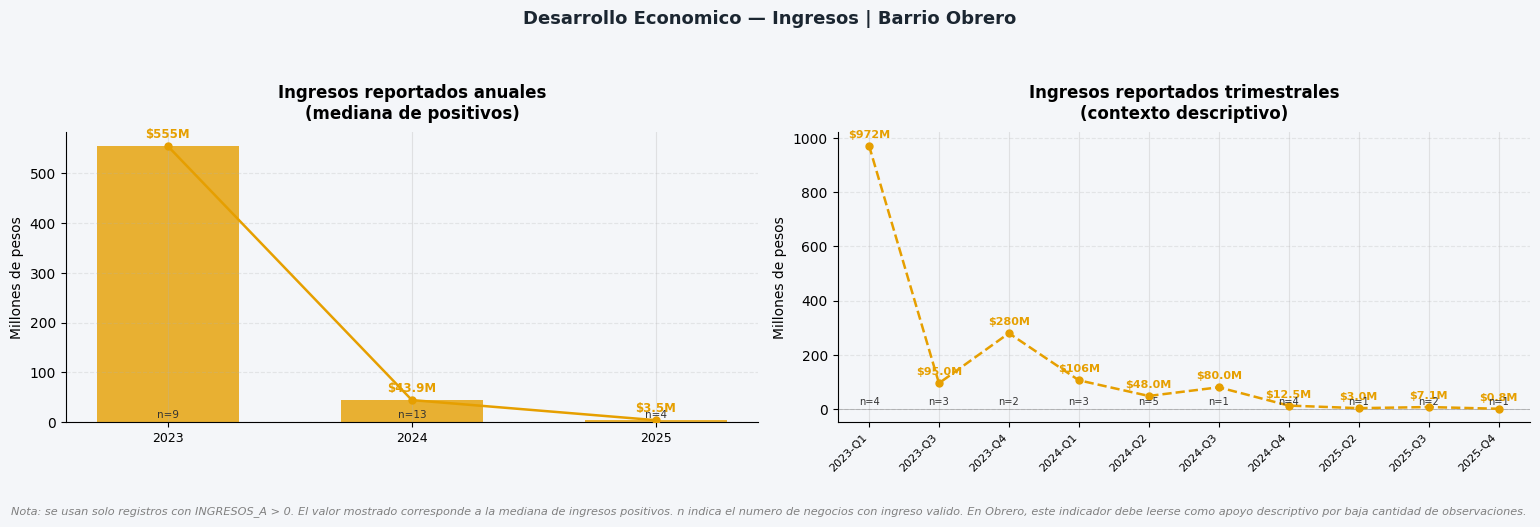

Resumen anual:


,año,negocios_con_ingreso,ingreso_mediano,ingreso_mediano_m
0,2023,9,555000000.0,555.000000
1,2024,13,43942974.0,43.942974
2,2025,4,3500000.0,3.500000


Resumen trimestral con dato positivo:


,periodo,negocios_con_ingreso,ingreso_mediano,ingreso_mediano_m
0,2023-Q1,4,971747292.0,971.747292
1,2023-Q3,3,95000000.0,95.000000
2,2023-Q4,2,279500000.0,279.500000
3,2024-Q1,3,105807555.0,105.807555
4,2024-Q2,5,48000000.0,48.000000
5,2024-Q3,1,80000000.0,80.000000
6,2024-Q4,4,12500000.0,12.500000
7,2025-Q2,1,3000000.0,3.000000
8,2025-Q3,2,7125000.0,7.125000
9,2025-Q4,1,800000.0,0.800000


In [ ]:
# ── Celda DE-ING-VIS: Ingresos | visual contextual honesto | Barrio Obrero ──
# Enfoque:
# - Ingresos calculados solo con INGRESOS_A > 0
# - Resumen con mediana de positivos
# - Anual como panel principal
# - Trimestral como panel secundario/contextual
# - n visible en cada punto

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'BG' not in globals():
    BG = '#F4F6F9'
if 'OKI_NARANJA' not in globals():
    OKI_NARANJA = '#E69F00'
if 'OKI_GRIS' not in globals():
    OKI_GRIS = '#333333'

_df = df_de.copy()

# ---------- Resolver columna de fecha ----------
col_fecha = None
for c in _df.columns:
    c_norm = str(c).strip().lower()
    if c_norm in ['mes_dia_an', 'mes_dia_a1', 'fecha_mat']:
        col_fecha = c
        break

if col_fecha is None and 'fecha_mat' not in _df.columns:
    raise KeyError("No encontre una columna de fecha usable: 'Mes_Dia_An', 'Mes_Dia_A1' o 'fecha_mat'.")

# ---------- Asegurar fecha / año / trimestre ----------
if 'fecha_mat' not in _df.columns:
    meses_es = {
        'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
        'julio': 7, 'agosto': 8, 'septiembre': 9, 'setiembre': 9,
        'octubre': 10, 'noviembre': 11, 'diciembre': 12
    }

    def parse_fecha_es(txt):
        if pd.isna(txt):
            return pd.NaT
        s = str(txt).strip().lower()
        m = re.search(r'(\d{1,2}) de ([a-záéíóú]+) de (\d{4})', s)
        if not m:
            return pd.NaT
        dia = int(m.group(1))
        mes_txt = (m.group(2)
                   .replace('á', 'a').replace('é', 'e')
                   .replace('í', 'i').replace('ó', 'o').replace('ú', 'u'))
        mes = meses_es.get(mes_txt)
        ano = int(m.group(3))
        return pd.Timestamp(year=ano, month=mes, day=dia) if mes else pd.NaT

    _df['fecha_mat'] = _df[col_fecha].apply(parse_fecha_es)
else:
    _df['fecha_mat'] = pd.to_datetime(_df['fecha_mat'], errors='coerce')

_df['anio_mat'] = _df['fecha_mat'].dt.year
_df['trim_mat'] = _df['fecha_mat'].dt.quarter

# ---------- Resolver ingresos ----------
col_ing = None
for c in _df.columns:
    if str(c).strip().upper() == 'INGRESOS_A':
        col_ing = c
        break

if col_ing is None:
    raise KeyError("No encontre la columna 'INGRESOS_A' en df_de.")

_df['ingresos_pos'] = pd.to_numeric(_df[col_ing], errors='coerce')
_df.loc[_df['ingresos_pos'] <= 0, 'ingresos_pos'] = np.nan

ANIOS_ING = [2023, 2024, 2025]

# ---------- Serie anual ----------
rows_anual = []
for ano in ANIOS_ING:
    sub = _df[_df['anio_mat'] == ano].copy()
    med = float(sub['ingresos_pos'].median()) if sub['ingresos_pos'].notna().any() else np.nan
    n_pos = int(sub['ingresos_pos'].notna().sum())
    rows_anual.append({
        'año': ano,
        'negocios_con_ingreso': n_pos,
        'ingreso_mediano': med,
        'ingreso_mediano_m': med / 1e6 if pd.notna(med) else np.nan
    })

df_ing_anual = pd.DataFrame(rows_anual)

# ---------- Serie trimestral ----------
rows_trim = []
for ano in ANIOS_ING:
    for trim in [1, 2, 3, 4]:
        sub = _df[(_df['anio_mat'] == ano) & (_df['trim_mat'] == trim)].copy()
        med = float(sub['ingresos_pos'].median()) if sub['ingresos_pos'].notna().any() else np.nan
        n_pos = int(sub['ingresos_pos'].notna().sum())
        rows_trim.append({
            'periodo': f'{ano}-Q{trim}',
            'año': ano,
            'trimestre': trim,
            'negocios_con_ingreso': n_pos,
            'ingreso_mediano': med,
            'ingreso_mediano_m': med / 1e6 if pd.notna(med) else np.nan
        })

df_ing_trim = pd.DataFrame(rows_trim)
df_ing_trim_pos = df_ing_trim[df_ing_trim['negocios_con_ingreso'] > 0].copy().reset_index(drop=True)

def fmt_compacto_m(v):
    if not pd.notna(v):
        return '—'
    if v >= 1000:
        return f'${v/1000:.1f} mil M'
    if v >= 100:
        return f'${v:.0f}M'
    if v >= 10:
        return f'${v:.1f}M'
    return f'${v:.1f}M'

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.2), facecolor=BG)
fig.suptitle(
    'Desarrollo Economico — Ingresos | Barrio Obrero',
    fontsize=13, fontweight='bold', color='#1B2631'
)

# ── Panel anual principal ────────────────────────────────────────────────────
ax = axes[0]
x1 = np.arange(len(df_ing_anual))
vals1 = df_ing_anual['ingreso_mediano_m'].to_numpy(dtype=float)

bars = ax.bar(x1, np.nan_to_num(vals1, nan=0.0), color=OKI_NARANJA, alpha=0.80, width=0.58)

for i, row in df_ing_anual.iterrows():
    v = row['ingreso_mediano_m']
    n = int(row['negocios_con_ingreso'])
    if pd.notna(v) and v > 0:
        ax.annotate(
            fmt_compacto_m(v),
            (i, v),
            textcoords='offset points', xytext=(0, 6),
            ha='center', fontsize=8.5, fontweight='bold', color=OKI_NARANJA
        )
    ax.annotate(
        f'n={n}',
        (i, 0),
        textcoords='offset points', xytext=(0, 3),
        ha='center', fontsize=7.5, color=OKI_GRIS
    )

ax.plot(x1, vals1, color=OKI_NARANJA, linewidth=1.8, marker='o', markersize=5, zorder=3)
ax.set_xticks(x1)
ax.set_xticklabels(df_ing_anual['año'].astype(str), fontsize=9)
ax.set_title('Ingresos reportados anuales\n(mediana de positivos)', pad=10, fontweight='bold')
ax.set_ylabel('Millones de pesos')
ax.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.set_facecolor(BG)

# ── Panel trimestral secundario/contextual ───────────────────────────────────
ax2 = axes[1]

if len(df_ing_trim_pos) > 0:
    x2 = np.arange(len(df_ing_trim_pos))
    vals2 = df_ing_trim_pos['ingreso_mediano_m'].to_numpy(dtype=float)

    ax2.plot(
        x2, vals2,
        color=OKI_NARANJA, linewidth=1.8, marker='o', markersize=5,
        linestyle='--', zorder=3
    )

    for i, row in df_ing_trim_pos.iterrows():
        v = row['ingreso_mediano_m']
        n = int(row['negocios_con_ingreso'])
        ax2.annotate(
            fmt_compacto_m(v),
            (i, v),
            textcoords='offset points', xytext=(0, 6),
            ha='center', fontsize=8.0, fontweight='bold', color=OKI_NARANJA
        )
        ax2.annotate(
            f'n={n}',
            (i, 0),
            textcoords='offset points', xytext=(0, 3),
            ha='center', fontsize=7.1, color=OKI_GRIS
        )

    ax2.set_xticks(x2)
    ax2.set_xticklabels(df_ing_trim_pos['periodo'], rotation=45, ha='right', fontsize=8)
else:
    ax2.text(0.5, 0.5, 'Sin trimestres con ingresos positivos', ha='center', va='center', fontsize=10, color=OKI_GRIS, transform=ax2.transAxes)
    ax2.set_xticks([])

ax2.set_title('Ingresos reportados trimestrales\n(contexto descriptivo)', pad=10, fontweight='bold')
ax2.set_ylabel('Millones de pesos')
ax2.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
ax2.grid(axis='y', linestyle='--', alpha=0.25)
ax2.set_facecolor(BG)

fig.text(
    0.01, 0.01,
    'Nota: se usan solo registros con INGRESOS_A > 0. El valor mostrado corresponde a la mediana de ingresos positivos. n indica el numero de negocios con ingreso valido. En Obrero, este indicador debe leerse como apoyo descriptivo por baja cantidad de observaciones.',
    fontsize=8.1, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.06, 1, 0.93])
plt.savefig('itt_obrero_ingresos_contextual_mediana.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('Resumen anual:')
display(df_ing_anual)

print('Resumen trimestral con dato positivo:')
display(df_ing_trim_pos[['periodo', 'negocios_con_ingreso', 'ingreso_mediano', 'ingreso_mediano_m']])

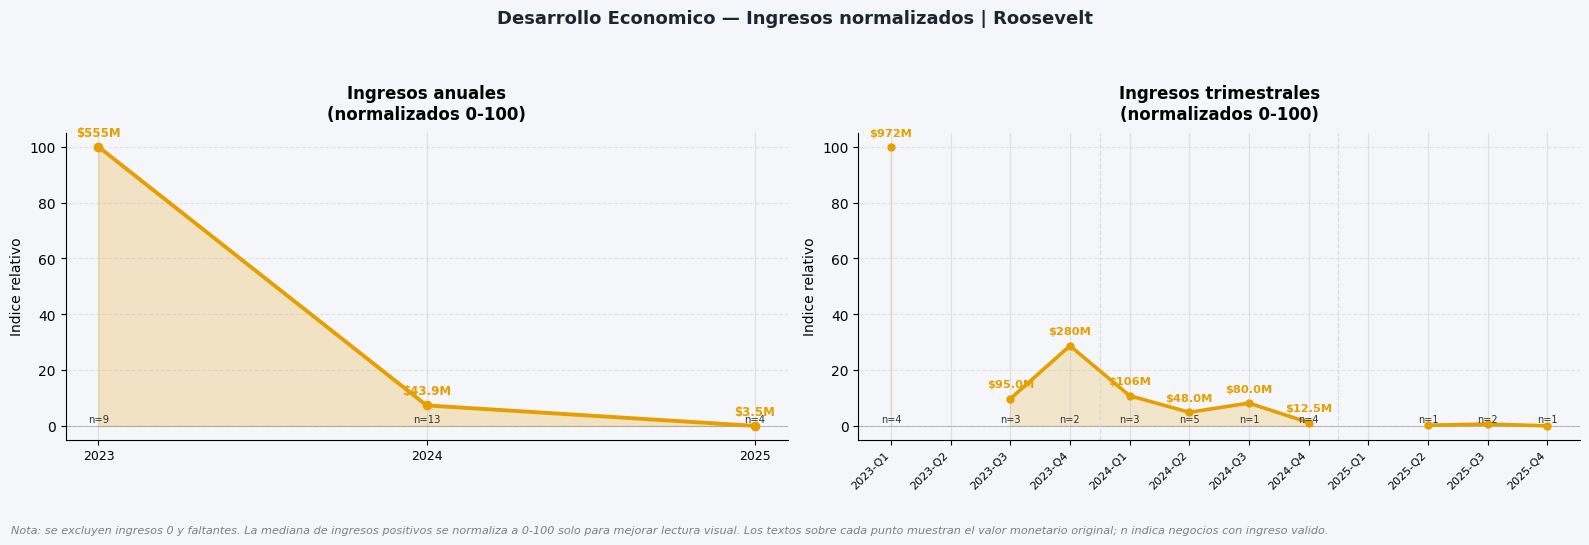

Resumen anual:


,año,negocios_con_ingreso,ingreso_mediano,ingreso_mediano_m,ingreso_norm
0,2023,9,555000000.0,555.000000,100.000000
1,2024,13,43942974.0,43.942974,7.333268
2,2025,4,3500000.0,3.500000,0.000000


Resumen trimestral:


,periodo,negocios_con_ingreso,ingreso_mediano,ingreso_mediano_m,ingreso_norm
0,2023-Q1,4,971747292.0,971.747292,100.000000
1,2023-Q2,0,NaN,NaN,NaN
2,2023-Q3,3,95000000.0,95.000000,9.701865
3,2023-Q4,2,279500000.0,279.500000,28.703927
4,2024-Q1,3,105807555.0,105.807555,10.814959
5,2024-Q2,5,48000000.0,48.000000,4.861232
6,2024-Q3,1,80000000.0,80.000000,8.156982
7,2024-Q4,4,12500000.0,12.500000,1.205009
8,2025-Q1,0,NaN,NaN,NaN
9,2025-Q2,1,3000000.0,3.000000,0.226583


In [ ]:
# ── Celda DE-ING-NORM-VIS: Ingresos normalizados | Roosevelt ─────────────────
# Ejemplo visual:
# - excluye NaN y 0
# - resume con mediana de ingresos positivos
# - normaliza cada serie (anual y trimestral) a 0-100 para mejorar lectura
# Nota: esto es una visualizacion relativa, no el valor monetario real ni el score oficial.

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'BG' not in globals():
    BG = '#F4F6F9'
if 'OKI_NARANJA' not in globals():
    OKI_NARANJA = '#E69F00'
if 'OKI_GRIS' not in globals():
    OKI_GRIS = '#333333'

_df = df_de.copy()

# ---------- Fecha / año / trimestre ----------
if 'fecha_mat' not in _df.columns:
    meses_es = {
        'enero': 1, 'febrero': 2, 'marzo': 3, 'abril': 4, 'mayo': 5, 'junio': 6,
        'julio': 7, 'agosto': 8, 'septiembre': 9, 'setiembre': 9,
        'octubre': 10, 'noviembre': 11, 'diciembre': 12
    }

    def parse_fecha_es(txt):
        if pd.isna(txt):
            return pd.NaT
        s = str(txt).strip().lower()
        m = re.search(r'(\d{1,2}) de ([a-záéíóú]+) de (\d{4})', s)
        if not m:
            return pd.NaT
        dia = int(m.group(1))
        mes_txt = (m.group(2)
                   .replace('á', 'a').replace('é', 'e')
                   .replace('í', 'i').replace('ó', 'o').replace('ú', 'u'))
        mes = meses_es.get(mes_txt)
        ano = int(m.group(3))
        return pd.Timestamp(year=ano, month=mes, day=dia) if mes else pd.NaT

    col_fecha = 'Mes_Dia_An' if 'Mes_Dia_An' in _df.columns else 'fecha_mat'
    _df['fecha_mat'] = _df[col_fecha].apply(parse_fecha_es) if col_fecha == 'Mes_Dia_An' else pd.to_datetime(_df[col_fecha], errors='coerce')

_df['anio_mat'] = _df['fecha_mat'].dt.year
_df['trim_mat'] = _df['fecha_mat'].dt.quarter

# ---------- Ingresos positivos ----------
_df['ingresos_pos'] = pd.to_numeric(_df['INGRESOS_A'], errors='coerce')
_df.loc[_df['ingresos_pos'] <= 0, 'ingresos_pos'] = np.nan

ANIOS_ING = [2023, 2024, 2025]

# ---------- Serie anual ----------
rows_anual = []
for ano in ANIOS_ING:
    sub = _df[_df['anio_mat'] == ano].copy()
    med = float(sub['ingresos_pos'].median()) if sub['ingresos_pos'].notna().any() else np.nan
    n_pos = int(sub['ingresos_pos'].notna().sum())
    rows_anual.append({
        'año': ano,
        'negocios_con_ingreso': n_pos,
        'ingreso_mediano': med,
        'ingreso_mediano_m': med / 1e6 if pd.notna(med) else np.nan
    })
df_ing_anual = pd.DataFrame(rows_anual)

# ---------- Serie trimestral ----------
rows_trim = []
for ano in ANIOS_ING:
    for trim in [1, 2, 3, 4]:
        sub = _df[(_df['anio_mat'] == ano) & (_df['trim_mat'] == trim)].copy()
        med = float(sub['ingresos_pos'].median()) if sub['ingresos_pos'].notna().any() else np.nan
        n_pos = int(sub['ingresos_pos'].notna().sum())
        rows_trim.append({
            'periodo': f'{ano}-Q{trim}',
            'año': ano,
            'trimestre': trim,
            'negocios_con_ingreso': n_pos,
            'ingreso_mediano': med,
            'ingreso_mediano_m': med / 1e6 if pd.notna(med) else np.nan
        })
df_ing_trim = pd.DataFrame(rows_trim)

# ---------- Normalizacion visual 0-100 ----------
def norm_0_100(s):
    s = pd.Series(s, dtype='float64')
    valid = s.dropna()
    if len(valid) == 0:
        return pd.Series(np.nan, index=s.index)
    vmin, vmax = valid.min(), valid.max()
    if vmax == vmin:
        out = pd.Series(np.nan, index=s.index)
        out.loc[valid.index] = 100.0
        return out
    return (s - vmin) / (vmax - vmin) * 100

df_ing_anual['ingreso_norm'] = norm_0_100(df_ing_anual['ingreso_mediano_m'])
df_ing_trim['ingreso_norm'] = norm_0_100(df_ing_trim['ingreso_mediano_m'])

def fmt_compacto_m(v):
    if not pd.notna(v):
        return '—'
    if v >= 1000:
        return f'${v/1000:.1f} mil M'
    if v >= 100:
        return f'${v:.0f}M'
    if v >= 10:
        return f'${v:.1f}M'
    return f'${v:.1f}M'

# ---------- Figura ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 5.4), facecolor=BG)
fig.suptitle(
    'Desarrollo Economico — Ingresos normalizados | Roosevelt',
    fontsize=13, fontweight='bold', color='#1B2631'
)

# Panel 1 anual
ax = axes[0]
x1 = np.arange(len(df_ing_anual))
vals1 = df_ing_anual['ingreso_norm'].to_numpy(dtype=float)

ax.fill_between(x1, vals1, where=~np.isnan(vals1), alpha=0.22, color=OKI_NARANJA)
ax.plot(x1, vals1, color=OKI_NARANJA, linewidth=2.8, marker='o', markersize=6, zorder=3)

for i, row in df_ing_anual.iterrows():
    v = row['ingreso_norm']
    if pd.notna(v):
        ax.annotate(
            fmt_compacto_m(row['ingreso_mediano_m']),
            (i, v),
            textcoords='offset points', xytext=(0, 8),
            ha='center', fontsize=8.5, fontweight='bold', color=OKI_NARANJA
        )
        ax.annotate(
            f"n={int(row['negocios_con_ingreso'])}",
            (i, 0),
            textcoords='offset points', xytext=(0, 3),
            ha='center', fontsize=7.2, color=OKI_GRIS
        )

ax.set_xticks(x1)
ax.set_xticklabels(df_ing_anual['año'].astype(str), fontsize=9)
ax.set_ylim(-5, 105)
ax.set_title('Ingresos anuales\n(normalizados 0-100)', pad=10, fontweight='bold')
ax.set_ylabel('Indice relativo')
ax.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
ax.grid(axis='y', linestyle='--', alpha=0.25)
ax.set_facecolor(BG)

# Panel 2 trimestral
ax2 = axes[1]
x2 = np.arange(len(df_ing_trim))
vals2 = df_ing_trim['ingreso_norm'].to_numpy(dtype=float)

ax2.fill_between(x2, vals2, where=~np.isnan(vals2), alpha=0.18, color=OKI_NARANJA)
ax2.plot(x2, vals2, color=OKI_NARANJA, linewidth=2.6, marker='o', markersize=5, zorder=3)

for i, row in df_ing_trim.iterrows():
    v = row['ingreso_norm']
    if not pd.notna(v):
        continue
    raw = row['ingreso_mediano_m']
    es_max = v == np.nanmax(vals2[~np.isnan(vals2)]) if np.any(~np.isnan(vals2)) else False
    es_relevante = pd.notna(raw) and raw >= 10
    if es_max or es_relevante:
        ax2.annotate(
            fmt_compacto_m(raw),
            (i, v),
            textcoords='offset points', xytext=(0, 8),
            ha='center', fontsize=8.2, fontweight='bold', color=OKI_NARANJA
        )

for i, n in enumerate(df_ing_trim['negocios_con_ingreso'].values):
    if n > 0:
        ax2.annotate(
            f'n={int(n)}',
            (i, 0),
            textcoords='offset points', xytext=(0, 3),
            ha='center', fontsize=7.0, color=OKI_GRIS
        )

ax2.set_xticks(x2)
ax2.set_xticklabels(df_ing_trim['periodo'], rotation=45, ha='right', fontsize=8)
ax2.set_ylim(-5, 105)
ax2.set_title('Ingresos trimestrales\n(normalizados 0-100)', pad=10, fontweight='bold')
ax2.set_ylabel('Indice relativo')
ax2.axhline(0, color=OKI_GRIS, linewidth=0.5, alpha=0.4)
ax2.grid(axis='y', linestyle='--', alpha=0.25)
ax2.set_facecolor(BG)

for cut in [3.5, 7.5]:
    ax2.axvline(cut, color='#D0D7DE', linewidth=0.9, linestyle='--', alpha=0.8)

fig.text(
    0.01, 0.01,
    'Nota: se excluyen ingresos 0 y faltantes. La mediana de ingresos positivos se normaliza a 0-100 solo para mejorar lectura visual. Los textos sobre cada punto muestran el valor monetario original; n indica negocios con ingreso valido.',
    fontsize=8.1, color='gray', style='italic'
)

plt.tight_layout(rect=[0, 0.06, 1, 0.93])
plt.savefig('itt_roosevelt_ingresos_normalizados.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print('Resumen anual:')
display(df_ing_anual[['año', 'negocios_con_ingreso', 'ingreso_mediano', 'ingreso_mediano_m', 'ingreso_norm']])

print('Resumen trimestral:')
display(df_ing_trim[['periodo', 'negocios_con_ingreso', 'ingreso_mediano', 'ingreso_mediano_m', 'ingreso_norm']])

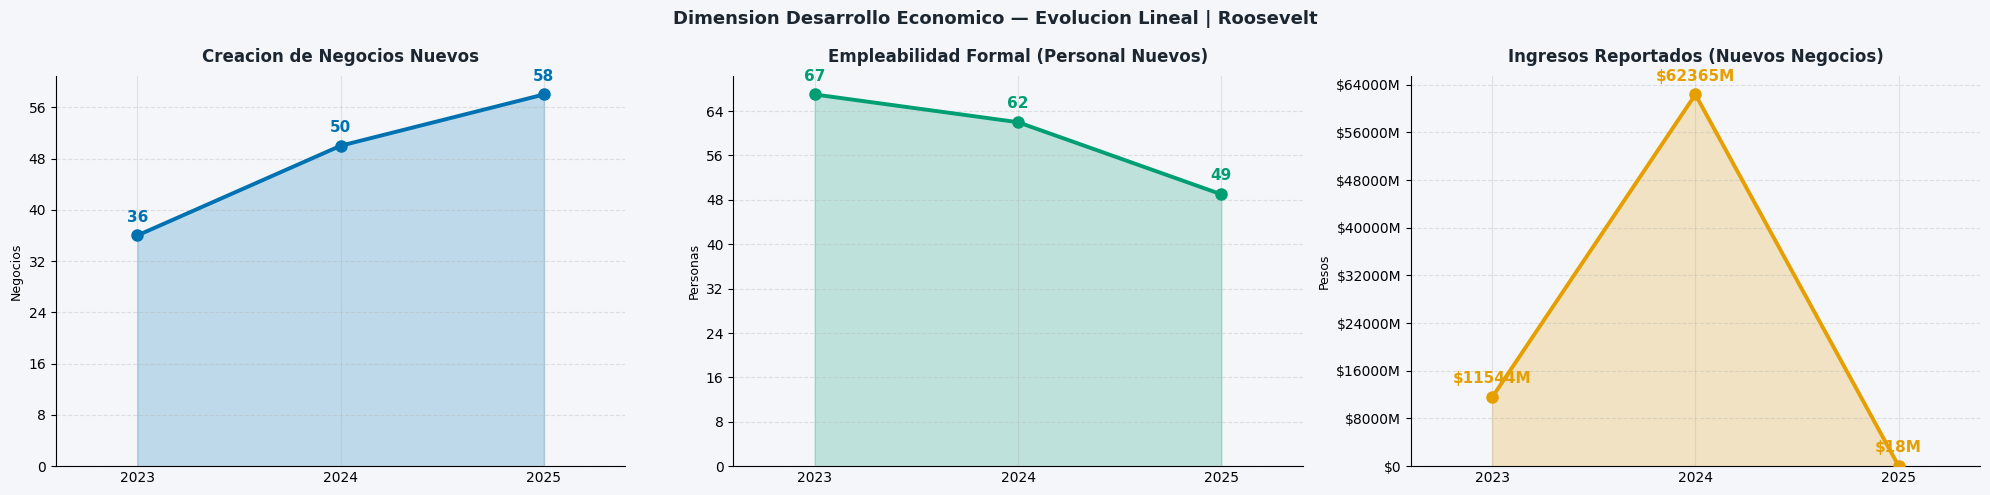

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), facecolor=BG)
fig.suptitle('Dimension Desarrollo Economico — Evolucion Lineal | Roosevelt',
             fontsize=13, fontweight='bold', color='#1B2631')

df_de_plot = df_de_anual.set_index('año').reindex(ANIOS_DE)
anos_lbl   = [str(a) for a in ANIOS_DE]
x_de       = np.arange(len(ANIOS_DE))

cfg_de = [
    ('negocios_nuevos', 'Creacion de Negocios Nuevos',           OKI_AZUL,    'negocios'),
    ('personal_nuevos', 'Empleabilidad Formal (Personal Nuevos)', OKI_VERDE,   'personas'),
    ('ingresos_nuevos', 'Ingresos Reportados (Nuevos Negocios)',  OKI_NARANJA, 'pesos'),
]

for ax, (col, titulo, color, unidad) in zip(axes, cfg_de):
    vals  = df_de_plot[col].values.astype(float)
    valid = ~np.isnan(vals)
    ax.fill_between(x_de, np.where(valid, vals, np.nan), alpha=0.22, color=color)
    ax.plot(x_de, np.where(valid, vals, np.nan),
            color=color, linewidth=2.8, marker='o', markersize=8, zorder=3)
    for i, v in enumerate(vals):
        if not np.isnan(v):
            lbl = f'${v/1e6:.0f}M' if col == 'ingresos_nuevos' and v >= 1e6 else str(int(v))
            ax.annotate(lbl, (i, v), textcoords='offset points', xytext=(0, 10),
                        ha='center', fontsize=11, fontweight='bold', color=color)
    ax.set_xticks(x_de); ax.set_xticklabels(anos_lbl, fontsize=10)
    ax.set_title(titulo, fontweight='bold', pad=10, color='#1B2631')
    ax.set_ylabel(unidad.capitalize(), fontsize=9)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=(col != 'ingresos_nuevos')))
    if col == 'ingresos_nuevos':
        ax.yaxis.set_major_formatter(
            plt.FuncFormatter(lambda v, _: f'${v/1e6:.0f}M' if v >= 1e6 else f'${v:,.0f}'))
    ax.set_xlim(-0.4, len(ANIOS_DE) - 0.6); ax.set_ylim(bottom=0)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.set_facecolor(BG); ax.tick_params(axis='x', length=0)
plt.tight_layout()
plt.savefig('itt_roosevelt_de_evol_linea.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

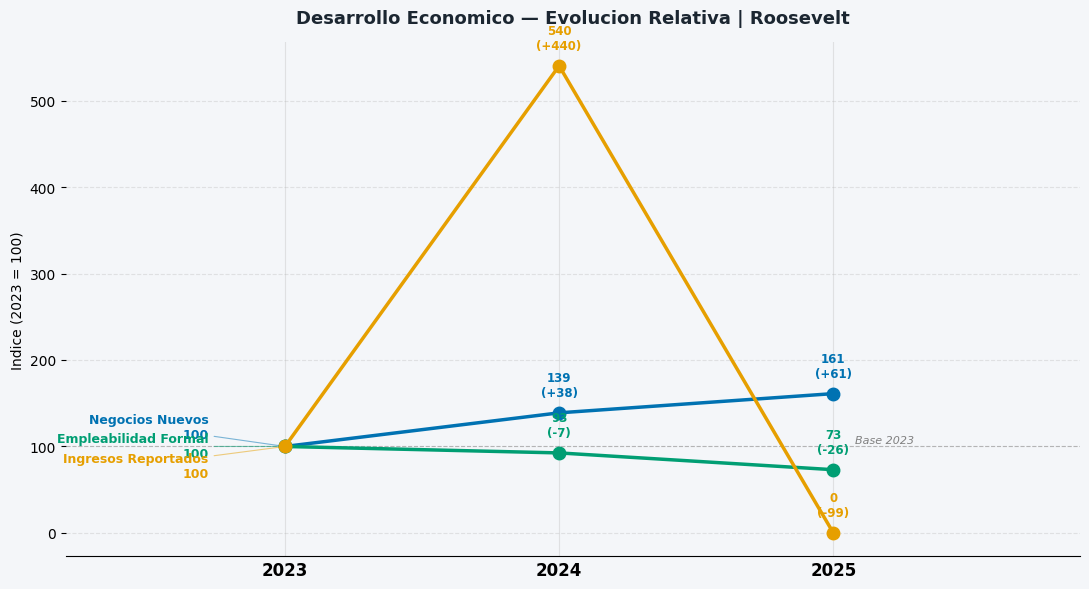

In [ ]:
df_de_plot = df_de_anual.set_index('año').reindex(ANIOS_DE)
indicadores = {
    'negocios_nuevos': ('Negocios Nuevos',      OKI_AZUL),
    'personal_nuevos': ('Empleabilidad Formal',  OKI_VERDE),
    'ingresos_nuevos': ('Ingresos Reportados',   OKI_NARANJA),
}
fig, ax = plt.subplots(figsize=(11, 6), facecolor=BG)
ax.set_facecolor(BG)
x_pos   = [0, 1, 2]
offsets = [14, 0, -14]

for (col, (label, color)), off in zip(indicadores.items(), offsets):
    vals = df_de_plot[col].values.astype(float)
    v0   = vals[0] if not np.isnan(vals[0]) and vals[0] != 0 else 1
    idx  = (vals / v0) * 100
    ax.plot(x_pos, idx, color=color, linewidth=2.5, marker='o', markersize=9, zorder=3, label=label)
    ax.annotate(f'{label}\n100', xy=(0, idx[0]),
                xytext=(-55, off), textcoords='offset points',
                ha='right', va='center', fontsize=9, fontweight='bold', color=color,
                arrowprops=dict(arrowstyle='-', color=color, lw=0.8, alpha=0.5))
    for xi, (x_p, v) in enumerate(zip(x_pos[1:], idx[1:]), 1):
        d = v - 100
        ax.annotate(f'{v:.0f}\n({"+"+str(int(d)) if d>=0 else str(int(d))})',
                    xy=(x_p, v), xytext=(0, 12), textcoords='offset points',
                    ha='center', fontsize=8.5, color=color, fontweight='bold')

ax.axhline(100, color='gray', linewidth=0.8, linestyle='--', alpha=0.45)
ax.text(2.08, 102, 'Base 2023', ha='left', va='bottom', fontsize=8, color='gray', style='italic')
ax.set_xticks(x_pos); ax.set_xticklabels(['2023','2024','2025'], fontsize=12, fontweight='bold')
ax.set_xlim(-0.8, 2.9); ax.set_ylabel('Indice (2023 = 100)', fontsize=10)
ax.set_title('Desarrollo Economico — Evolucion Relativa | Roosevelt',
             fontsize=13, fontweight='bold', color='#1B2631', pad=14)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.tick_params(axis='x', length=0); ax.spines[['top','right','left']].set_visible(False)
plt.tight_layout()
plt.savefig('itt_roosevelt_de_slope.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

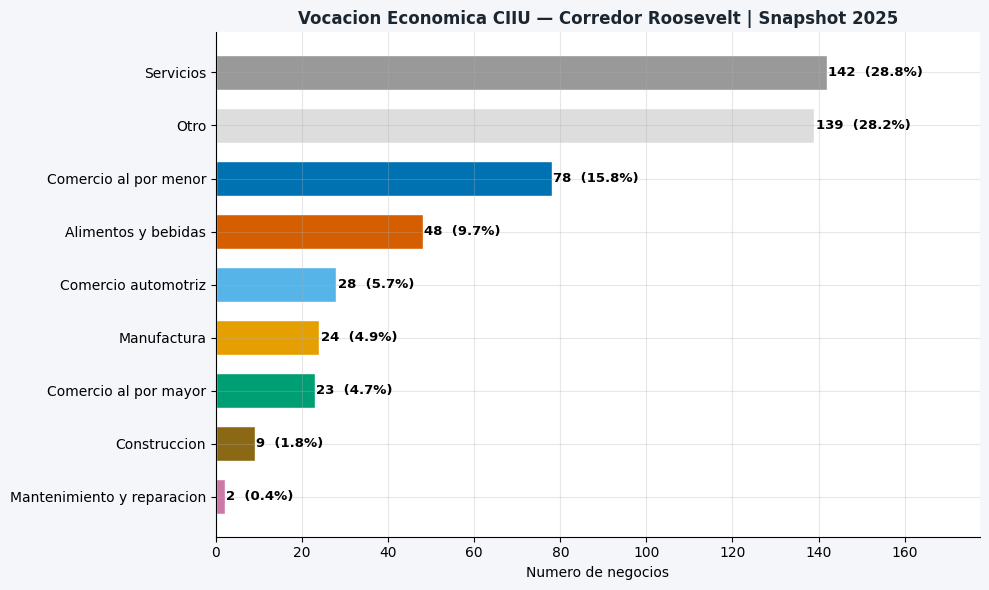

In [ ]:
SECTOR_MAP = {
    '45': 'Comercio automotriz', '46': 'Comercio al por mayor', '47': 'Comercio al por menor',
    '56': 'Alimentos y bebidas', '55': 'Alimentos y bebidas',
    '10': 'Manufactura', '13': 'Manufactura', '15': 'Manufactura',
    '16': 'Manufactura', '22': 'Manufactura', '24': 'Manufactura',
    '25': 'Manufactura', '31': 'Manufactura',
    '29': 'Mantenimiento y reparacion', '33': 'Mantenimiento y reparacion',
    '42': 'Construccion', '43': 'Construccion',
    '38': 'Servicios', '68': 'Servicios', '70': 'Servicios', '73': 'Servicios',
    '74': 'Servicios', '85': 'Servicios', '86': 'Servicios',
    '90': 'Servicios', '91': 'Servicios', '94': 'Servicios', '96': 'Servicios',
}
SECTOR_COLORS = {
    'Comercio al por menor':      '#0072B2',
    'Comercio automotriz':        '#56B4E9',
    'Comercio al por mayor':      '#009E73',
    'Manufactura':                '#E69F00',
    'Alimentos y bebidas':        '#D55E00',
    'Mantenimiento y reparacion': '#CC79A7',
    'Construccion':               '#8B6914',
    'Servicios':                  '#999999',
    'Otro':                       '#DDDDDD',
}

rows_c = []
for feat in raw_de['features']:
    p = feat['properties']
    cod = str(p.get('CODIGO_CII', '')).strip()
    sec2 = cod[:2] if len(cod) >= 2 else ''
    rows_c.append({'sector': SECTOR_MAP.get(sec2, 'Otro')})

df_ciiu    = pd.DataFrame(rows_c)
dist_total = df_ciiu['sector'].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
ax.set_facecolor('white')
colors_h = [SECTOR_COLORS.get(s, '#CCC') for s in dist_total.index]
bars = ax.barh(dist_total.index, dist_total.values, color=colors_h, edgecolor='white', height=0.65)
for bar, val in zip(bars, dist_total.values):
    pct = val / len(df_ciiu) * 100
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}  ({pct:.1f}%)', va='center', fontsize=9.5, fontweight='bold')
ax.set_xlabel('Numero de negocios')
ax.set_title('Vocacion Economica CIIU — Corredor Roosevelt | Snapshot 2025',
             fontsize=12, fontweight='bold', color='#1B2631')
ax.spines[['top','right']].set_visible(False)
ax.set_xlim(0, max(dist_total.values) * 1.25)
plt.tight_layout()
plt.savefig('itt_roosevelt_ciiu.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## ITT Global — Corredor Roosevelt

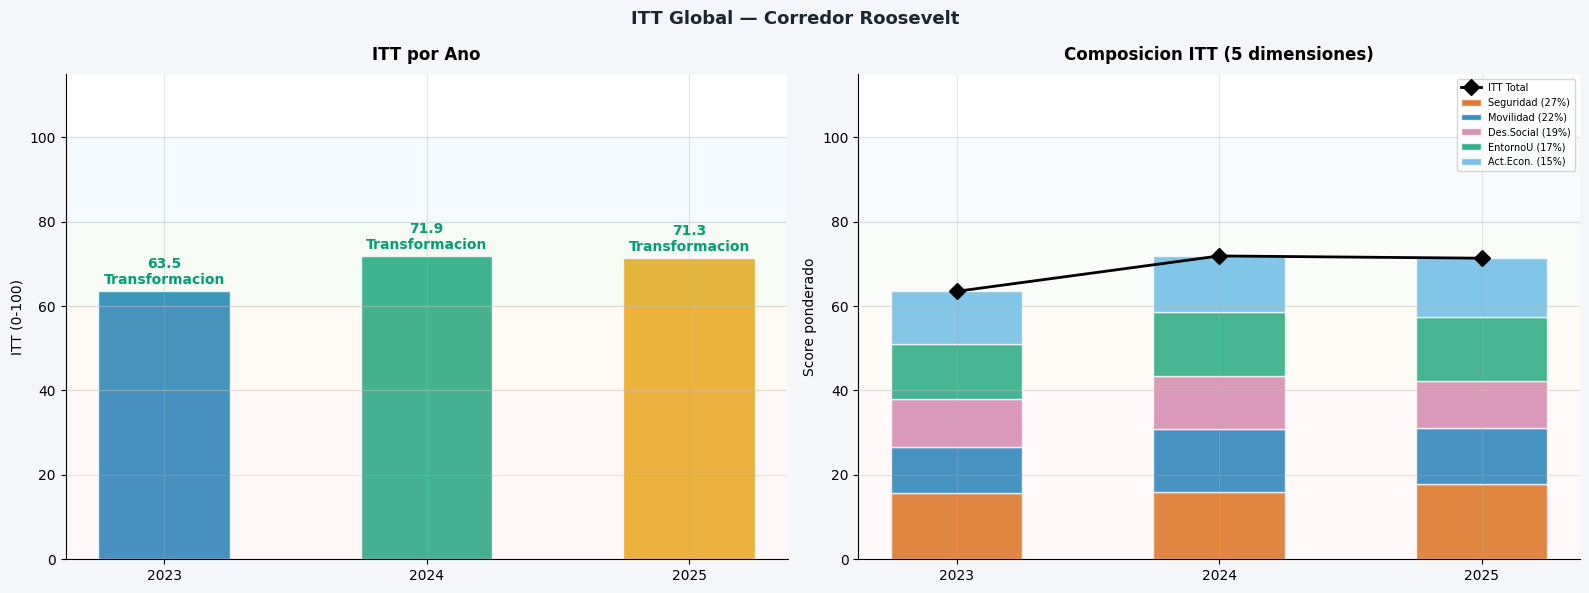

In [ ]:
if not isinstance(base, pd.DataFrame):
    raise RuntimeError("'base' no es DataFrame. Re-ejecuta la celda de Normalizacion.")

ANIOS_R   = [2023, 2024, 2025]
base_plot = base[base['año'].isin(ANIOS_R)].copy()

COLORES_ITT  = [OKI_AZUL, OKI_VERDE, OKI_NARANJA]
band_configs = [(0,40,'#FFCDD2','Activacion'),(40,60,'#FFE0B2','Consolidacion'),
                (60,80,'#C8E6C9','Transformacion'),(80,100,'#BBDEFB','Escala')]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=BG)
fig.suptitle('ITT Global — Corredor Roosevelt', fontsize=13, fontweight='bold', color='#1B2631')

ax1 = axes[0]
bars = ax1.bar(ANIOS_R, base_plot['ITT'], color=COLORES_ITT, alpha=0.85, edgecolor='white', width=0.5)
for bar, val, nivel in zip(bars, base_plot['ITT'], base_plot['nivel']):
    ax1.text(bar.get_x()+bar.get_width()/2, val+1, f'{val:.1f}\n{nivel}',
             ha='center', va='bottom', fontsize=10, fontweight='bold',
             color=NIVEL_COLORS.get(nivel,'#1B2631'))
for y0,y1,c,l in band_configs: ax1.axhspan(y0, y1, alpha=0.15, color=c)
ax1.set_title('ITT por Ano', fontweight='bold', pad=10)
ax1.set_ylim(0, 115); ax1.set_ylabel('ITT (0-100)'); ax1.set_xticks(ANIOS_R)

ax2 = axes[1]
dims  = ['score_seguridad','score_movilidad','score_des_social','score_entorno_u','score_des_eco']
lbls  = ['Seguridad','Movilidad','Des.Social','EntornoU','Act.Econ.']
pesos = [PESOS['Seguridad'],PESOS['Movilidad'],PESOS['DesSocial'],PESOS['EntornoU'],PESOS['DesEco']]
cols  = [OKI_BERMELL, OKI_AZUL, OKI_MORADO, OKI_VERDE, OKI_AZUL_C]

bottom = np.zeros(len(ANIOS_R))
for dim, lbl, peso, col in zip(dims, lbls, pesos, cols):
    if dim in base_plot.columns:
        vals = base_plot[dim].fillna(0).values * peso
        ax2.bar(ANIOS_R, vals, bottom=bottom, label=f'{lbl} ({peso:.0%})',
                color=col, alpha=0.8, edgecolor='white', width=0.5)
        bottom += vals
ax2.plot(ANIOS_R, base_plot['ITT'], 'D-', color='black', linewidth=2, markersize=8, label='ITT Total', zorder=5)
for y0,y1,c,l in band_configs: ax2.axhspan(y0, y1, alpha=0.1, color=c)
ax2.set_title('Composicion ITT (5 dimensiones)', fontweight='bold', pad=10)
ax2.set_ylim(0, 115); ax2.set_ylabel('Score ponderado'); ax2.set_xticks(ANIOS_R)
ax2.legend(loc='upper right', fontsize=7)
plt.tight_layout()
plt.savefig('itt_roosevelt_global.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

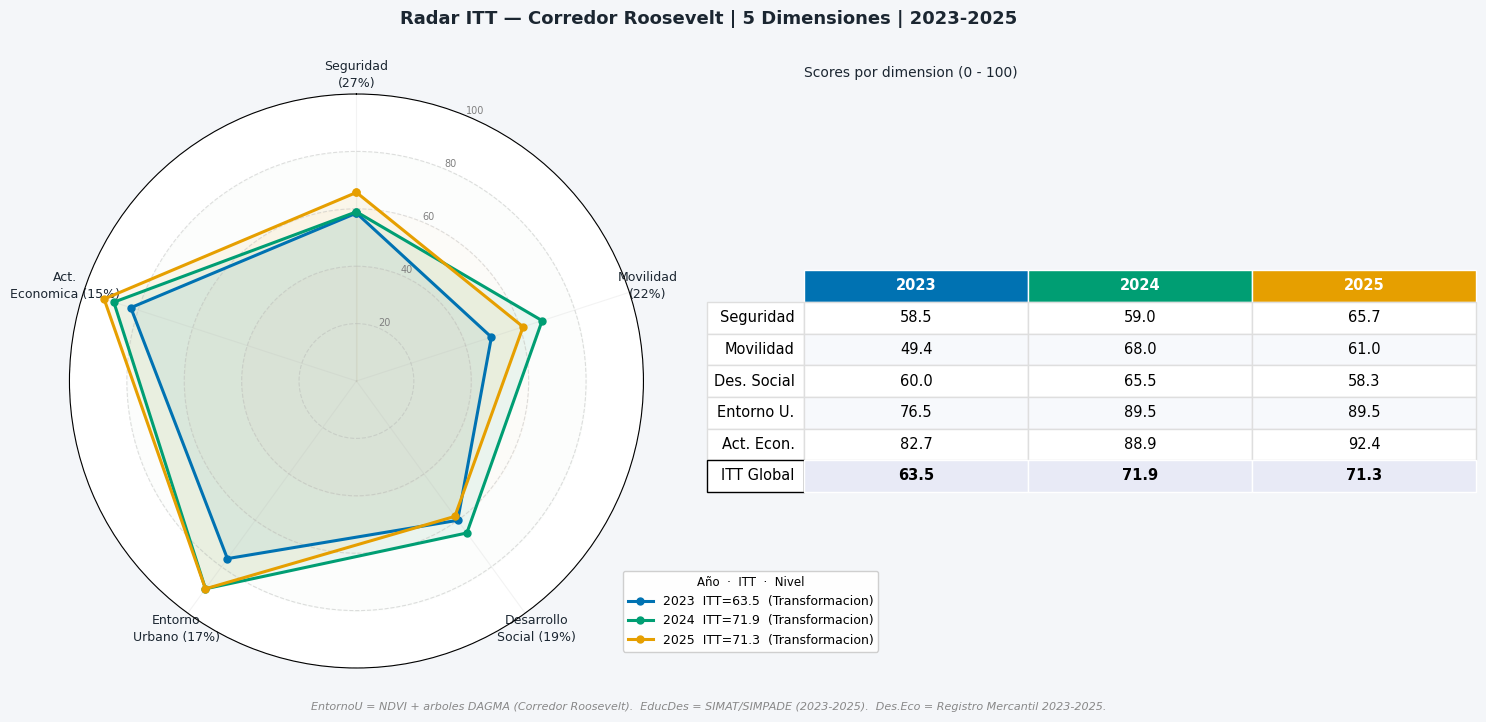

In [ ]:
# ── Radar ITT: 5 dimensiones | 2023-2025 — Corredor Roosevelt ────────────────
DIMS_LBL = [
    'Seguridad\n(27%)', 'Movilidad\n(22%)', 'Desarrollo\nSocial (19%)',
    'Entorno\nUrbano (17%)', 'Act.\nEconomica (15%)',
]
DIMS_COL   = ['score_seguridad','score_movilidad','score_des_social',
              'score_entorno_u','score_des_eco']
DIMS_ABREV = ['Seguridad','Movilidad','Des. Social','Entorno U.','Act. Econ.']
N_DIMS     = len(DIMS_LBL)
angles     = [i / N_DIMS * 2 * np.pi for i in range(N_DIMS)]
angles    += angles[:1]

ANIOS_R   = [2023, 2024, 2025]
COLORES_R = {2023: OKI_AZUL, 2024: OKI_VERDE, 2025: OKI_NARANJA}

# ── Layout 2 paneles ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 7), facecolor=BG)
ax_r = fig.add_axes([0.02, 0.04, 0.52, 0.82], polar=True)
ax_t = fig.add_axes([0.56, 0.04, 0.42, 0.82])
fig.suptitle('Radar ITT — Corredor Roosevelt | 5 Dimensiones | 2023-2025',
             fontsize=13, fontweight='bold', color='#1B2631', y=0.98)

# ── Panel izquierdo: Radar ────────────────────────────────────────────────────
ax_r.set_theta_offset(np.pi / 2)
ax_r.set_theta_direction(-1)
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(DIMS_LBL, fontsize=9, color='#1B2631', linespacing=1.4)
ax_r.set_ylim(0, 100)
ax_r.set_yticks([20, 40, 60, 80, 100])
ax_r.set_yticklabels(['20','40','60','80','100'], fontsize=7, color='gray')
ax_r.yaxis.grid(True, linestyle='--', alpha=0.4)
ax_r.xaxis.grid(True, linestyle='-', alpha=0.15)

for y, c in [(40,'#FFCDD2'),(60,'#FFE0B2'),(80,'#C8E6C9')]:
    ax_r.fill_between(np.linspace(0, 2*np.pi, 200), 0, y, alpha=0.05, color=c)

for año in ANIOS_R:
    row = base[base['año'] == año]
    if row.empty: continue
    vals   = [float(row[c].iloc[0]) if not pd.isna(row[c].iloc[0]) else 0 for c in DIMS_COL]
    vals_c = vals + [vals[0]]
    color  = COLORES_R[año]
    ax_r.plot(angles, vals_c, linewidth=2.2, color=color,
              marker='o', markersize=5,
              label=f"{año}  ITT={float(row['ITT'].iloc[0]):.1f}  ({row['nivel'].iloc[0]})")
    ax_r.fill(angles, vals_c, alpha=0.07, color=color)

ax_r.legend(loc='upper right', bbox_to_anchor=(1.42, 0.18),
            fontsize=9, framealpha=0.92,
            title='Año  ·  ITT  ·  Nivel', title_fontsize=8.5)

# ── Panel derecho: Tabla de scores ───────────────────────────────────────────
ax_t.axis('off')

col_labels = [str(a) for a in ANIOS_R]
row_labels  = DIMS_ABREV + ['ITT Global']

table_data = []
for dim in DIMS_COL:
    table_data.append([
        f"{float(base[base['año']==a].iloc[0][dim]):.1f}"
        if not base[base['año']==a].empty and not pd.isna(base[base['año']==a].iloc[0][dim]) else '—'
        for a in ANIOS_R
    ])
table_data.append([f"{float(base[base['año']==a].iloc[0]['ITT']):.1f}"
                   if not base[base['año']==a].empty else '—'
                   for a in ANIOS_R])

tbl = ax_t.table(
    cellText=table_data,
    rowLabels=row_labels,
    colLabels=col_labels,
    cellLoc='center', rowLoc='right',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10.5)
tbl.scale(1.0, 1.9)

for j, año in enumerate(ANIOS_R):
    cell = tbl[0, j]
    cell.set_facecolor(COLORES_R[año])
    cell.set_text_props(color='white', fontweight='bold')
    cell.set_edgecolor('white')

n = len(table_data)
for j in range(len(ANIOS_R)):
    cell = tbl[n, j]
    cell.set_facecolor('#E8EAF6')
    cell.set_text_props(fontweight='bold')
    cell.set_edgecolor('white')

for i in range(1, n):
    for j in range(len(ANIOS_R)):
        tbl[i, j].set_facecolor('#F7F9FC' if i % 2 == 0 else 'white')
        tbl[i, j].set_edgecolor('#DEDEDE')
    tbl[i, -1].set_edgecolor('#DEDEDE')

ax_t.set_title('Scores por dimension (0 - 100)', fontsize=10,
               color='#1B2631', pad=12, loc='left')

fig.text(0.5, -0.02,
    'EntornoU = NDVI + arboles DAGMA (Corredor Roosevelt).  '
    'EducDes = SIMAT/SIMPADE (2023-2025).  '
    'Des.Eco = Registro Mercantil 2023-2025.',
    ha='center', fontsize=8, color='#888888', style='italic')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('itt_roosevelt_radar.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


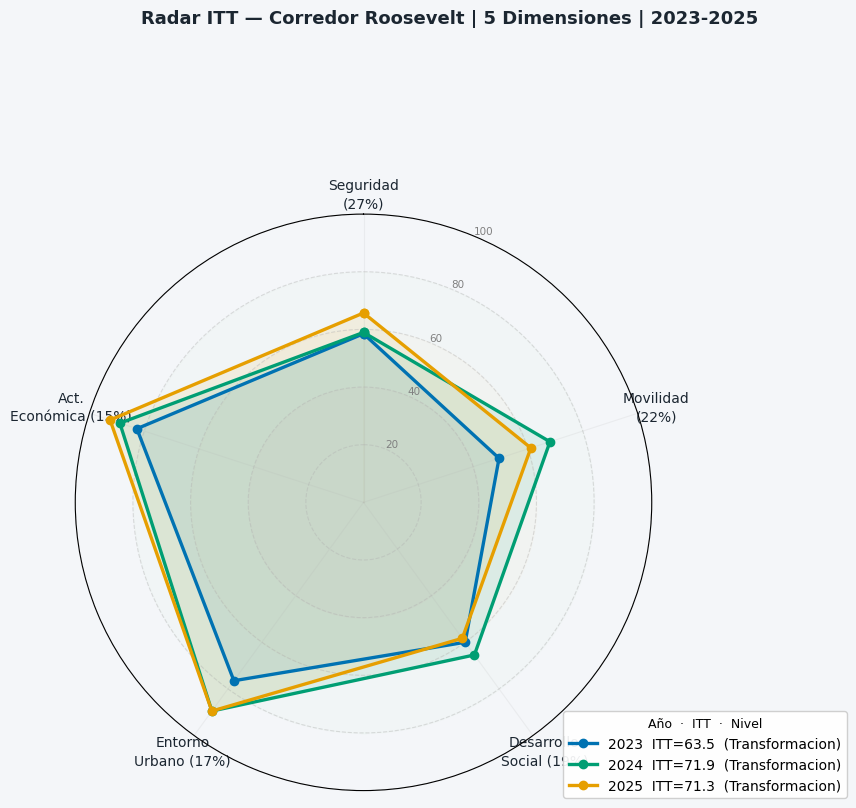

In [ ]:
# ── Radar ITT: 5 dimensiones | 2023-2025 — Corredor Roosevelt ────────────────
DIMS_LBL = [
    'Seguridad\n(27%)', 'Movilidad\n(22%)', 'Desarrollo\nSocial (19%)',
    'Entorno\nUrbano (17%)', 'Act.\nEconómica (15%)',
]
DIMS_COL   = ['score_seguridad','score_movilidad','score_des_social',
              'score_entorno_u','score_des_eco']
N_DIMS     = len(DIMS_LBL)
angles     = [i / N_DIMS * 2 * np.pi for i in range(N_DIMS)]
angles    += angles[:1]

ANIOS_R   = [2023, 2024, 2025]
COLORES_R = {2023: OKI_AZUL, 2024: OKI_VERDE, 2025: OKI_NARANJA}

fig, ax_r = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True), facecolor=BG)
fig.suptitle('Radar ITT — Corredor Roosevelt | 5 Dimensiones | 2023-2025',
             fontsize=13, fontweight='bold', color='#1B2631', y=1.01)

ax_r.set_facecolor(BG)
ax_r.set_theta_offset(np.pi / 2)
ax_r.set_theta_direction(-1)
ax_r.set_xticks(angles[:-1])
ax_r.set_xticklabels(DIMS_LBL, fontsize=10, color='#1B2631', linespacing=1.4)
ax_r.set_ylim(0, 100)
ax_r.set_yticks([20, 40, 60, 80, 100])
ax_r.set_yticklabels(['20','40','60','80','100'], fontsize=7.5, color='gray')
ax_r.yaxis.grid(True, linestyle='--', alpha=0.4)
ax_r.xaxis.grid(True, linestyle='-', alpha=0.15)

for y, c in [(40,'#FFCDD2'), (60,'#FFE0B2'), (80,'#C8E6C9')]:
    ax_r.fill_between(np.linspace(0, 2*np.pi, 200), 0, y, alpha=0.06, color=c)

for año in ANIOS_R:
    row = base[base['año'] == año]
    if row.empty: continue
    vals   = [float(row[c].iloc[0]) if not pd.isna(row[c].iloc[0]) else 0 for c in DIMS_COL]
    vals_c = vals + [vals[0]]
    color  = COLORES_R[año]
    ax_r.plot(angles, vals_c, linewidth=2.4, color=color,
              marker='o', markersize=6,
              label=f"{año}  ITT={float(row['ITT'].iloc[0]):.1f}  ({row['nivel'].iloc[0]})")
    ax_r.fill(angles, vals_c, alpha=0.09, color=color)

ax_r.legend(loc='upper right', bbox_to_anchor=(1.35, 0.15),
            fontsize=10, framealpha=0.92,
            title='Año  ·  ITT  ·  Nivel', title_fontsize=9)

plt.tight_layout()
plt.savefig('itt_roosevelt_radar.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


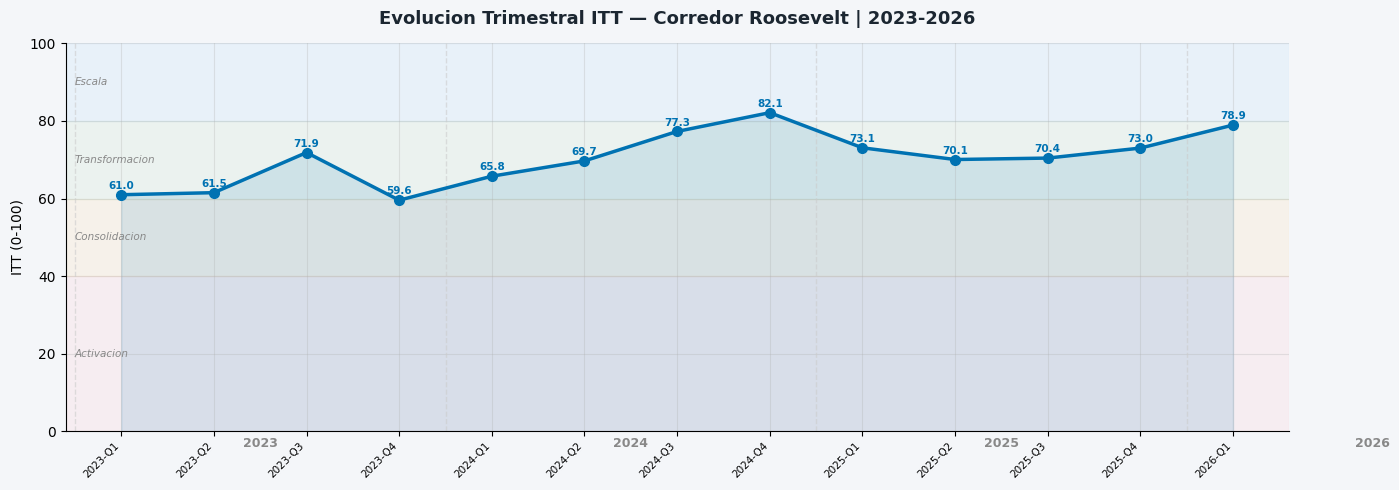

In [ ]:
REFS_Q = {
    'homicidios':     (0,    2.0,   True),
    'hurtos':         (25,   87.5,  True),
    'siniestralidad': (2.5,  11.25, True),
    'lesionados':     (2.0,  8.75,  True),
    'mortales':       (0,    1.0,   True),
    'vif':            (0.75, 3.75,  True),
    'rinas':          (0,    6.25,  True),
}

rows_q = []
for _, r in corr_trim.iterrows():
    anio = int(r['año']); trim = int(r['trimestre'])
    if anio == 2026 and trim > 1: continue

    def qs(col):
        v = r[col]
        if pd.isna(v): return np.nan
        rmin, rmax, inv = REFS_Q[col]
        return score_ref(v, rmin, rmax, inv)

    seg_vals = [x for x in [qs('homicidios'), qs('hurtos')] if not pd.isna(x)]
    mov_vals = [x for x in [qs('siniestralidad'), qs('lesionados'), qs('mortales')] if not pd.isna(x)]
    coh_vals = [x for x in [qs('vif'), qs('rinas')] if not pd.isna(x)]

    sc_seg = np.mean(seg_vals) if seg_vals else np.nan
    sc_mov = np.mean(mov_vals) if mov_vals else np.nan

    brow   = base[base['año'] == anio]
    sc_spa = float(brow['score_spa'].iloc[0]) if not brow.empty and 'score_spa' in brow.columns else np.nan
    sc_coh = np.mean(coh_vals + ([sc_spa] if not pd.isna(sc_spa) else [])) if coh_vals else np.nan
    sc_ent = float(brow['score_entorno_u'].iloc[0]) if not brow.empty else np.nan
    sc_edu = float(brow['score_educ_des'].iloc[0])  if not brow.empty else np.nan
    sc_soc = np.mean([v for v in [sc_coh, sc_edu] if not pd.isna(v)]) if (not pd.isna(sc_coh) or not pd.isna(sc_edu)) else np.nan
    sc_de  = float(brow['score_des_eco'].iloc[0])   if not brow.empty else np.nan

    dims = {'Seguridad':sc_seg,'Movilidad':sc_mov,'DesSocial':sc_soc,'EntornoU':sc_ent,
            'DesEco':sc_de}
    total_peso = sum(PESOS[k] for k,v in dims.items() if not pd.isna(v))
    itt_q = sum(PESOS[k]*v for k,v in dims.items() if not pd.isna(v)) / total_peso if total_peso > 0 else np.nan
    rows_q.append({'periodo': r['periodo'], 'año': anio, 'trimestre': trim, 'ITT': itt_q})

df_evol = pd.DataFrame(rows_q)

fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
ax.set_facecolor(BG)
x_idx    = list(range(len(df_evol)))
itt_vals = df_evol['ITT'].values

band_configs = [(0,40,'#FFCDD2','Activacion'),(40,60,'#FFE0B2','Consolidacion'),
                (60,80,'#C8E6C9','Transformacion'),(80,100,'#BBDEFB','Escala')]
for y0,y1,c,l in band_configs:
    ax.axhspan(y0, y1, alpha=0.2, color=c)
    ax.text(-0.5, (y0+y1)/2, l, va='center', fontsize=7.5, color='#888888', style='italic')

ax.plot(x_idx, itt_vals, color=OKI_AZUL, linewidth=2.5, marker='o', markersize=7, zorder=3)
ax.fill_between(x_idx, itt_vals, alpha=0.12, color=OKI_AZUL)
for xi, v in zip(x_idx, itt_vals):
    if not np.isnan(v):
        ax.text(xi, v+1.5, f'{v:.1f}', ha='center', fontsize=7.5, fontweight='bold', color=OKI_AZUL)

for i, yr in enumerate(df_evol['año'].unique()):
    mask = df_evol['año'] == yr
    xi_start = df_evol[mask].index[0] - df_evol.index[0]
    ax.axvline(xi_start-0.5, color='#CCCCCC', linewidth=1, linestyle='--', alpha=0.6)
    ax.text(xi_start + 1.5, ax.get_ylim()[0] + 1, str(yr),
            ha='center', fontsize=9, color='#888888', fontweight='bold')

ax.set_xticks(x_idx)
ax.set_xticklabels(df_evol['periodo'].tolist(), rotation=45, ha='right', fontsize=7.5)
ax.set_ylim(0, 100); ax.set_ylabel('ITT (0-100)', fontsize=10)
ax.set_title('Evolucion Trimestral ITT — Corredor Roosevelt | 2023-2026',
             fontsize=13, fontweight='bold', color='#1B2631', pad=14)
ax.set_xlim(-0.6, len(x_idx)-0.4)
plt.tight_layout()
plt.savefig('itt_roosevelt_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

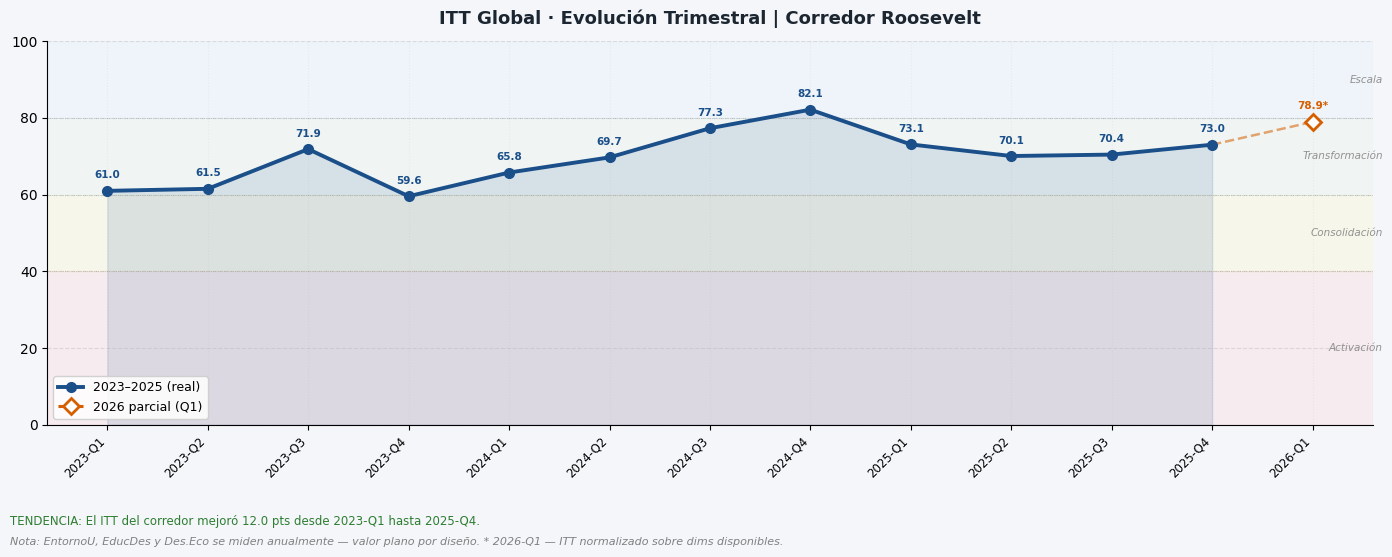

In [ ]:
# ── Evolución Trimestral ITT Global — Corredor Roosevelt (5 dimensiones) ──────
REFS_Q = {
    'homicidios':     (0,     2.0,   True),
    'hurtos':         (25,   87.5,   True),
    'siniestralidad': (2.5,  11.25,  True),
    'lesionados':     (2.0,   8.75,  True),
    'mortales':       (0,     1.0,   True),
    'vif':            (0.75,  3.75,  True),
    'rinas':          (0,     6.25,  True),
}

rows_q = []
for _, r in corr_trim.iterrows():
    anio = int(r['año']); trim = int(r['trimestre'])
    if anio == 2026 and trim > 1: continue   # solo Q1 2026

    def qs(col):
        v = r[col]
        if pd.isna(v): return np.nan
        rmin, rmax, inv = REFS_Q[col]
        return score_ref(v, rmin, rmax, inv)

    seg_vals = [x for x in [qs('homicidios'), qs('hurtos')] if not pd.isna(x)]
    mov_vals = [x for x in [qs('siniestralidad'), qs('lesionados'), qs('mortales')] if not pd.isna(x)]
    coh_vals = [x for x in [qs('vif'), qs('rinas')] if not pd.isna(x)]

    sc_seg = np.mean(seg_vals) if seg_vals else np.nan
    sc_mov = np.mean(mov_vals) if mov_vals else np.nan

    brow   = base[base['año'] == anio]
    sc_spa = float(brow['score_spa'].iloc[0]) if not brow.empty and 'score_spa' in brow.columns else np.nan
    sc_coh = np.mean(coh_vals + ([sc_spa] if not pd.isna(sc_spa) else [])) if coh_vals else np.nan
    sc_ent = float(brow['score_entorno_u'].iloc[0]) if not brow.empty else np.nan
    sc_edu = float(brow['score_educ_des'].iloc[0])  if not brow.empty else np.nan
    sc_soc = np.mean([v for v in [sc_coh, sc_edu] if not pd.isna(v)]) if (not pd.isna(sc_coh) or not pd.isna(sc_edu)) else np.nan
    sc_de  = float(brow['score_des_eco'].iloc[0])   if not brow.empty else np.nan

    # Promedio ponderado normalizado: excluye dims sin dato (evita deflactar por 0)
    dims = {'Seguridad': sc_seg, 'Movilidad': sc_mov, 'DesSocial': sc_soc, 'EntornoU': sc_ent,
            'DesEco': sc_de}
    total_peso = sum(PESOS[k] for k, v in dims.items() if not pd.isna(v))
    itt_q = sum(PESOS[k]*v for k, v in dims.items() if not pd.isna(v)) / total_peso if total_peso > 0 else np.nan

    rows_q.append({
        'periodo': r['periodo'], 'año': anio, 'trimestre': trim,
        'ITT': itt_q, 'parcial': anio == 2026
    })

df_evol = pd.DataFrame(rows_q)

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5), facecolor=BG)
ax.set_facecolor(BG)

x_idx    = list(range(len(df_evol)))
n_per    = len(df_evol)
itt_vals = df_evol['ITT'].values

BANDAS = [
    (0,  40,  '#FFCDD2', 'Activación'),
    (40, 60,  '#FFF9C4', 'Consolidación'),
    (60, 80,  '#E8F5E9', 'Transformación'),
    (80, 100, '#E3F2FD', 'Escala'),
]
for y0, y1, color, lbl in BANDAS:
    ax.axhspan(y0, y1, alpha=0.25, color=color, zorder=0)
    ax.text(n_per - 0.3, (y0 + y1) / 2, lbl,
            fontsize=7.5, color='gray', ha='right', va='center',
            style='italic', alpha=0.85)

for y in [40, 60, 80]:
    ax.axhline(y, color='gray', linewidth=0.6, linestyle=':', alpha=0.5)

# ── Serie histórica 2023-2025 ─────────────────────────────────────────────────
mask_hist = df_evol['parcial'] == False
mask_2026 = df_evol['parcial'] == True
x_hist = [i for i, m in enumerate(mask_hist) if m]
x_2026 = [i for i, m in enumerate(mask_2026) if m]
v_hist = df_evol.loc[mask_hist, 'ITT'].values
v_2026 = df_evol.loc[mask_2026, 'ITT'].values

ax.plot(x_hist, v_hist, '-o', linewidth=2.8, color='#1B4F8A',
        markersize=7, zorder=5, label='2023–2025 (real)')
ax.fill_between(x_hist, 0, v_hist, alpha=0.12, color='#1B4F8A')

# ── Serie 2026 parcial ────────────────────────────────────────────────────────
if len(x_2026) > 0:
    ax.plot([x_hist[-1], x_2026[0]], [v_hist[-1], v_2026[0]],
            color=OKI_BERMELL, linewidth=1.8, linestyle='--', alpha=0.55, zorder=4)
    ax.plot(x_2026, v_2026, '--D', linewidth=2.2, color=OKI_BERMELL,
            markersize=8, markerfacecolor='white', markeredgewidth=2,
            zorder=5, label='2026 parcial (Q1)')

# ── Anotaciones de valor ──────────────────────────────────────────────────────
for xi, val, es_parc in zip(x_idx, itt_vals, df_evol['parcial']):
    if pd.isna(val): continue
    c_ann  = OKI_BERMELL if es_parc else '#1B4F8A'
    sufijo = '*' if es_parc else ''
    ax.annotate(f'{val:.1f}{sufijo}', xy=(xi, val), xytext=(0, 9),
                textcoords='offset points', ha='center', fontsize=7.5,
                color=c_ann, fontweight='bold')

ax.legend(fontsize=9, loc='lower left', framealpha=0.85)
ax.set_xticks(x_idx)
ax.set_xticklabels(df_evol['periodo'].tolist(), rotation=45, ha='right', fontsize=8.5)
ax.set_ylim(0, 100)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.grid(axis='y', linestyle='--', alpha=0.35)
ax.grid(axis='x', linestyle=':', alpha=0.15)
ax.set_title('ITT Global · Evolución Trimestral | Corredor Roosevelt',
             fontsize=13, fontweight='bold', color='#1B2631', pad=12)

val_ini = df_evol[df_evol['año'] == 2023].iloc[0]['ITT']
row_ult = df_evol[(df_evol['año'] == 2025) & (df_evol['trimestre'] == 4)]
val_fin = row_ult.iloc[0]['ITT'] if not row_ult.empty else v_hist[-1]
delta   = val_fin - val_ini
dir_txt = 'mejoró' if delta > 0 else 'retrocedió'
delta_c = '#2E7D32' if delta > 0 else '#C62828'

fig.text(0.01, -0.06,
         f'TENDENCIA: El ITT del corredor {dir_txt} {abs(delta):.1f} pts desde 2023-Q1 hasta 2025-Q4.',
         fontsize=8.5, color=delta_c, transform=fig.transFigure)
fig.text(0.01, -0.10,
         'Nota: EntornoU, EducDes y Des.Eco se miden anualmente — valor plano por diseño. '
         '* 2026-Q1 — ITT normalizado sobre dims disponibles.',
         fontsize=8, color='gray', style='italic', transform=fig.transFigure)

plt.tight_layout()
plt.savefig('itt_roosevelt_evolucion_global.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


Seg 2026: 86.4*  |  Mov 2026: — (sin siniestros)  |  DS 2026: 53.2*


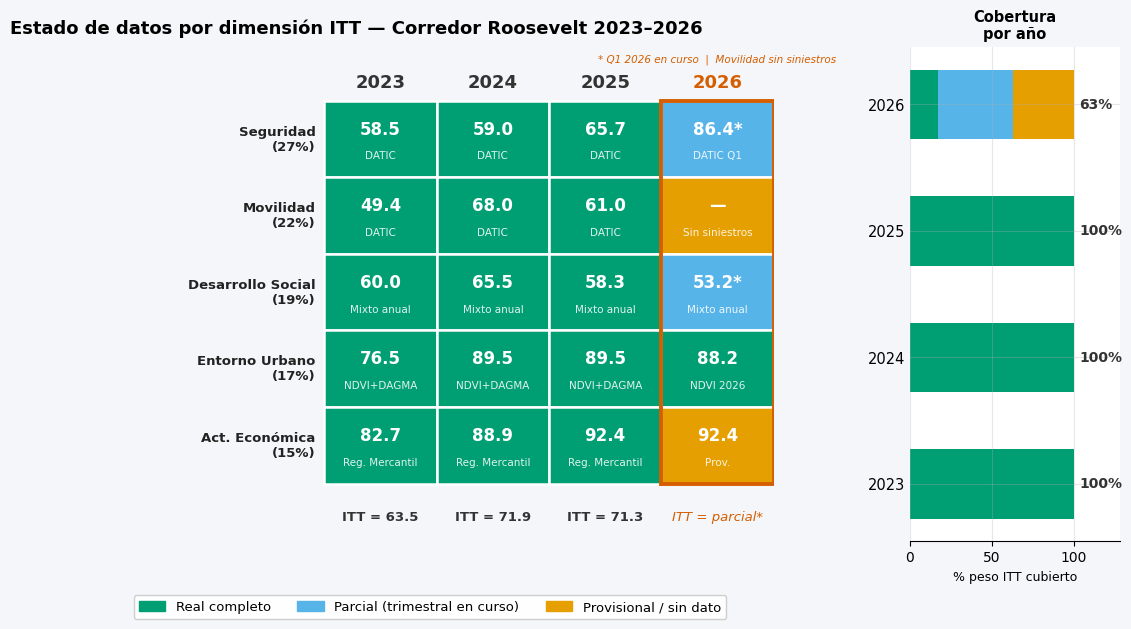

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Celda: Estado de datos 2023–2026 por dimensión ITT — Corredor Roosevelt
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from pathlib import Path

def _sc(col, anio):
    row = base[base['año'] == anio]
    if row.empty or col not in row.columns: return '—'
    v = row.iloc[0][col]
    return '—' if pd.isna(v) else f'{float(v):.1f}'

def _score_parcial(col, src):
    try:
        sub = base[base['año'] == 2026][col].dropna()
        if len(sub) == 0: return '—', src
        return f'{float(sub.iloc[0]):.1f}*', src
    except Exception:
        return '—', src

seg_val, seg_src = _score_parcial('score_seguridad', 'DATIC Q1')
soc_val, soc_src = _score_parcial('score_des_social', 'Indicadores anuales')
print(f"Seg 2026: {seg_val}  |  Mov 2026: — (sin siniestros)  |  DS 2026: {soc_val}")

DIMS_INFO = [
    ('Seguridad',          '27%', 0.27),
    ('Movilidad',          '22%', 0.22),
    ('Desarrollo Social',  '19%', 0.19),
    ('Entorno Urbano',     '17%', 0.17),
    ('Act. Económica',     '15%', 0.15),
]
ANIOS = [2023, 2024, 2025, 2026]

TABLA = [
    [(3,_sc('score_seguridad',2023),'DATIC'),(3,_sc('score_seguridad',2024),'DATIC'),
     (3,_sc('score_seguridad',2025),'DATIC'),(2,seg_val,seg_src)],
    [(3,_sc('score_movilidad',2023),'DATIC'),(3,_sc('score_movilidad',2024),'DATIC'),
     (3,_sc('score_movilidad',2025),'DATIC'),(1,'—','Sin siniestros')],
    [(3,_sc('score_des_social',2023),'Indicadores anuales'),(3,_sc('score_des_social',2024),'Indicadores anuales'),
     (3,_sc('score_des_social',2025),'Indicadores anuales'),(2,soc_val,soc_src)],
    [(3,_sc('score_entorno_u',2023),'NDVI+DAGMA'),(3,_sc('score_entorno_u',2024),'NDVI+DAGMA'),
     (3,_sc('score_entorno_u',2025),'NDVI+DAGMA'),(3,_sc('score_entorno_u',2026),'NDVI 2026')],
    [(2,_sc('score_des_eco',2023),'Proxy stock 2025'),(2,_sc('score_des_eco',2024),'Proxy stock 2025'),
     (3,_sc('score_des_eco',2025),'Stock activo 2025'),(1,_sc('score_des_eco',2026),'Proxy=2025')],
]

ITT_ANUAL = {
    _a: (f"{float(base.loc[base['año'] == _a, 'ITT'].iloc[0]):.1f}" if (not base[base['año'] == _a].empty and not pd.isna(base.loc[base['año'] == _a, 'ITT'].iloc[0])) else None)
    for _a in [2023, 2024, 2025, 2026]
}

C_MAP = {3: OKI_VERDE, 2: OKI_AZUL_C, 1: OKI_NARANJA}
NDIM = len(DIMS_INFO); NANI = len(ANIOS)

fig = plt.figure(figsize=(15, 6.5))
gs  = gridspec.GridSpec(1, 2, width_ratios=[4, 1.1], wspace=0.28,
                        left=0.22, right=0.96, top=0.90, bottom=0.14)
ax  = fig.add_subplot(gs[0])
axb = fig.add_subplot(gs[1])

for i in range(NDIM):
    row_y = NDIM - 1 - i
    for j, anio in enumerate(ANIOS):
        estado, score, fuente = TABLA[i][j]
        ax.add_patch(plt.Rectangle((j, row_y), 1, 1, linewidth=1.8,
            edgecolor='white', facecolor=C_MAP[estado], zorder=1))
        ax.text(j+0.5, row_y+0.63, score, ha='center', va='center',
                fontsize=12, fontweight='bold', color='white', zorder=2)
        ax.text(j+0.5, row_y+0.28, fuente, ha='center', va='center',
                fontsize=7.5, color='white', alpha=0.88, zorder=2)

for i, (dname, peso_s, _) in enumerate(DIMS_INFO):
    ax.text(-0.08, NDIM-1-i+0.5, f'{dname}\n({peso_s})',
            ha='right', va='center', fontsize=9.5, fontweight='bold', color='#222222')

for j, anio in enumerate(ANIOS):
    c = OKI_BERMELL if anio == 2026 else '#333333'
    ax.text(j+0.5, NDIM+0.12, str(anio), ha='center', va='bottom',
            fontsize=13, color=c, fontweight='bold')

ax.text(3.5, NDIM+0.48, '* Q1 2026 en curso  |  Movilidad sin siniestros',
        ha='center', va='bottom', fontsize=7.5, color=OKI_BERMELL, style='italic')

for j, anio in enumerate(ANIOS):
    c   = OKI_BERMELL if anio == 2026 else '#333333'
    val = ITT_ANUAL.get(anio)
    lbl = f'ITT = {val}' if val else 'ITT = parcial*'
    ax.text(j+0.5, -0.35, lbl, ha='center', va='top', fontsize=9.5, color=c,
            fontweight='bold' if val else 'normal',
            style='normal' if val else 'italic')

ax.add_patch(plt.Rectangle((3, 0), 1, NDIM, linewidth=2.8,
    edgecolor=OKI_BERMELL, facecolor='none', zorder=4))
ax.set_xlim(-2.8, NANI); ax.set_ylim(-0.75, NDIM + 0.70); ax.axis('off')
ax.set_title('Estado de datos por dimensión ITT — Corredor Roosevelt 2023–2026',
             fontsize=13, fontweight='bold', pad=10, loc='left', x=0.0)

w_real = []; w_parcial = []; w_provis = []
for j in range(NANI):
    r = p = pv = 0.0
    for i, (_, _, peso) in enumerate(DIMS_INFO):
        e = TABLA[i][j][0]
        if e == 3: r += peso
        elif e == 2: p += peso
        else: pv += peso
    w_real.append(r*100); w_parcial.append(p*100); w_provis.append(pv*100)

y_pos = np.arange(NANI)
axb.barh(y_pos, w_real,    color=OKI_VERDE,   height=0.55)
axb.barh(y_pos, w_parcial, color=OKI_AZUL_C,  height=0.55, left=w_real)
axb.barh(y_pos, w_provis,  color=OKI_NARANJA, height=0.55,
         left=[r+p for r,p in zip(w_real, w_parcial)])

for j in range(NANI):
    axb.text(103, j, f'{w_real[j]+w_parcial[j]:.0f}%',
             va='center', fontsize=10, fontweight='bold', color='#333333')

axb.set_yticks(y_pos); axb.set_yticklabels([str(a) for a in ANIOS], fontsize=10.5)
axb.set_xlim(0, 128); axb.set_xlabel('% peso ITT cubierto', fontsize=9)
axb.set_title('Cobertura\npor año', fontsize=10.5, fontweight='bold')
axb.tick_params(axis='y', length=0)
axb.spines[['top','right','left']].set_visible(False)

patches = [
    mpatches.Patch(color=OKI_VERDE,   label='Real completo'),
    mpatches.Patch(color=OKI_AZUL_C,  label='Parcial (trimestral en curso)'),
    mpatches.Patch(color=OKI_NARANJA, label='Provisional / sin dato'),
]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9.5,
           frameon=True, framealpha=0.95, bbox_to_anchor=(0.5, 0.01))

plt.savefig('itt_roosevelt_cobertura_datos.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


SPA trimestral Roosevelt: {(2023, 1): 38, (2023, 2): 41, (2023, 3): 21, (2023, 4): 16, (2024, 1): 14, (2024, 2): 15, (2024, 3): 30, (2024, 4): 42, (2025, 1): 38, (2025, 2): 54, (2025, 3): 49, (2025, 4): 20, (2026, 1): 28}


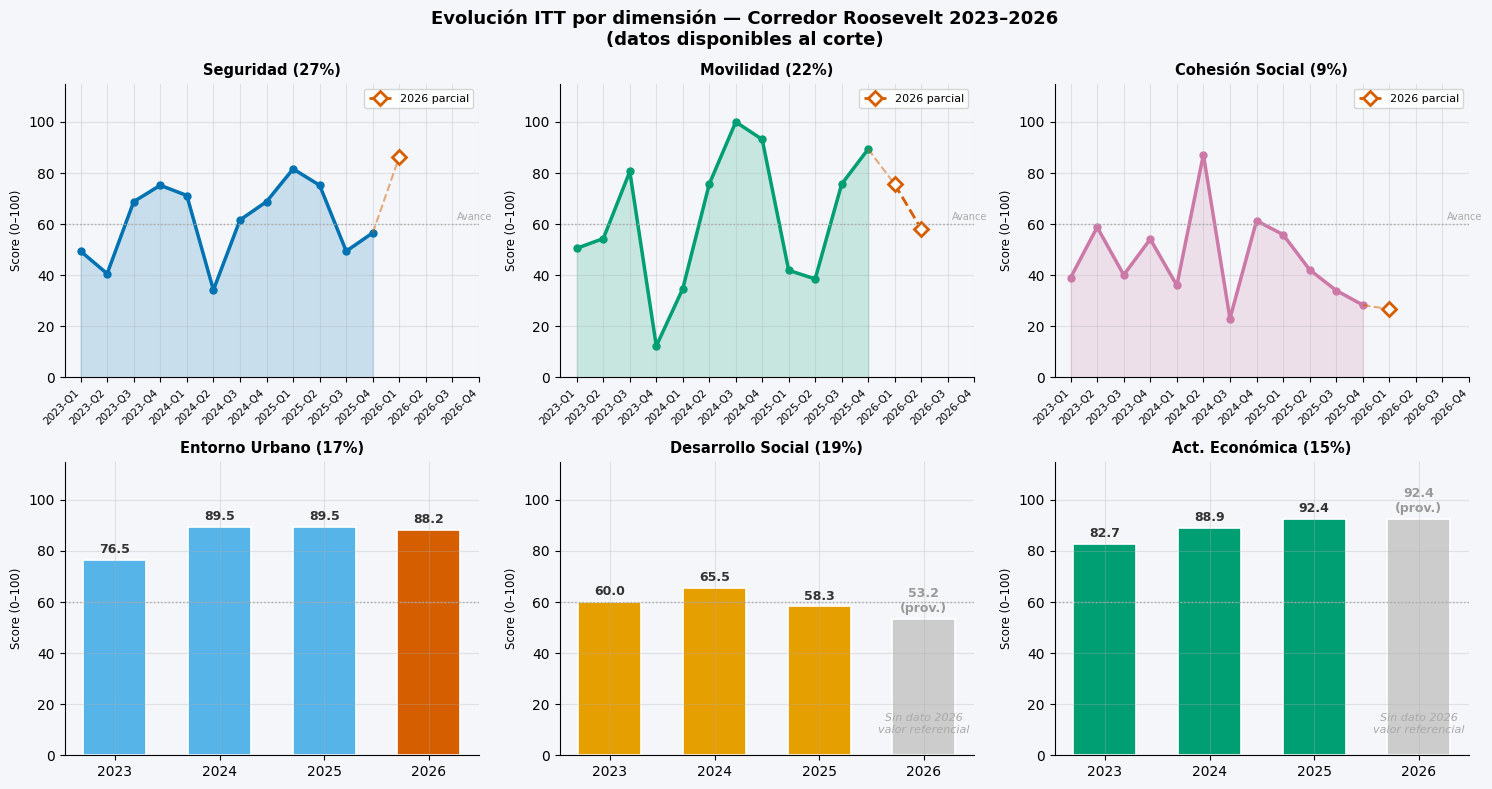

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# Celda: Evolución por dimensión 2023–2026 — Corredor Roosevelt
# ══════════════════════════════════════════════════════════════════════════════

def _sr(v, rmin, rmax, inv=False):
    if pd.isna(v): return np.nan
    raw = np.clip((v - rmin) / (rmax - rmin) * 100, 0, 100)
    return 100 - raw if inv else raw

# ── SPA trimestral desde raw_comp (SUSTANCIAS PSICOACTIVAS) ──────────────────
_df_spa = pd.DataFrame([f['properties'] for f in raw_comp['features']])
_df_spa = _df_spa[_df_spa['agrupado'] == 'SUSTANCIAS PSICOACTIVAS'].copy()
_df_spa['_fecha']    = pd.to_datetime(_df_spa['fecha_hech'], errors='coerce')
_df_spa['año']       = _df_spa['_fecha'].dt.year
_df_spa['trimestre'] = _df_spa['_fecha'].dt.quarter
_spa_q   = _df_spa[_df_spa['año'].isin(ANIOS)].groupby(['año','trimestre']).size()
SPA_TRIM = {(int(a), int(t)): int(n) for (a, t), n in _spa_q.items()}
print(f'SPA trimestral Roosevelt: {SPA_TRIM}')

# ── Scores trimestrales — REFS calibrados para el corredor (anuales / 4) ─────
df = corr_trim.copy()
df['sc_hom'] = df['homicidios'].apply(    lambda v: _sr(v, 0,    2.0,   True))
df['sc_hur'] = df['hurtos'].apply(        lambda v: _sr(v, 25,   87.5,  True))
df['sc_sin'] = df['siniestralidad'].apply(lambda v: _sr(v, 2.5,  11.25, True))
df['sc_les'] = df['lesionados'].apply(    lambda v: _sr(v, 2.0,  8.75,  True))
df['sc_mor'] = df['mortales'].apply(      lambda v: _sr(v, 0,    1.0,   True))
df['sc_vif'] = df['vif'].apply(  lambda v: _sr(v, 0.75, 3.75,  True))
df['sc_rin'] = df['rinas'].apply(lambda v: _sr(v, 0,    6.25,  True))
df['sc_spa'] = df.apply(
    lambda r: _sr(SPA_TRIM.get((r['año'], r['trimestre']), np.nan), 0, 50, True), axis=1)

df['score_seg_q'] = (df['sc_hom'] + df['sc_hur']) / 2
df['score_mov_q'] = (df['sc_sin'] + df['sc_les'] + df['sc_mor']) / 3  # NaN para 2026
df['score_coh_q'] = (df['sc_vif'] + df['sc_rin'] + df['sc_spa']) / 3

# ── Figura 2×3 ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8), facecolor=BG)
fig.suptitle('Evolución ITT por dimensión — Corredor Roosevelt 2023–2026\n(datos disponibles al corte)',
             fontsize=13, fontweight='bold')

# ── Fila 1: dimensiones trimestrales ─────────────────────────────────────────
cfg_q = [
    (axes[0,0], 'score_seg_q', 'Seguridad (27%)',      OKI_AZUL),
    (axes[0,1], 'score_mov_q', 'Movilidad (22%)',       OKI_VERDE),
    (axes[0,2], 'score_coh_q', 'Cohesión Social (9%)',  OKI_MORADO),
]
for ax, col, titulo, color in cfg_q:
    periodos = df['periodo'].tolist()
    vals     = df[col].values.astype(float)
    x        = np.arange(len(periodos))
    is_2026  = df['año'].values == 2026

    x_h, v_h = x[~is_2026], vals[~is_2026]
    x_6, v_6 = x[is_2026],  vals[is_2026]

    ax.fill_between(x_h, np.where(~np.isnan(v_h), v_h, np.nan), alpha=0.18, color=color)
    ax.plot(x_h, np.where(~np.isnan(v_h), v_h, np.nan),
            color=color, linewidth=2.5, marker='o', markersize=5)

    valid_6 = ~np.isnan(v_6)
    if valid_6.any():
        ax.plot([x_h[-1], x_6[0]], [v_h[-1], v_6[0]],
                color=OKI_BERMELL, linewidth=1.5, linestyle='--', alpha=0.5)
        ax.plot(x_6[valid_6], v_6[valid_6],
                color=OKI_BERMELL, linewidth=2, linestyle='--',
                marker='D', markersize=7,
                markerfacecolor='white', markeredgewidth=2, label='2026 parcial')
    else:
        # Sin dato 2026 (Movilidad: no hay siniestros)
        ax.text(len(periodos) - 0.7, 8, 'Sin dato\n2026', ha='right',
                fontsize=8, color='#AAAAAA', style='italic')

    ax.axhline(60, color='#AAAAAA', linestyle=':', linewidth=1)
    ax.text(len(periodos) - 0.5, 61.5, 'Avance', fontsize=7, color='#AAAAAA', ha='right')
    ax.set_ylim(0, 115)
    ax.set_xticks(x)
    ax.set_xticklabels(periodos, rotation=45, ha='right', fontsize=7.5)
    ax.set_title(titulo, fontsize=10.5, fontweight='bold')
    ax.set_ylabel('Score (0–100)', fontsize=8.5)
    ax.set_facecolor(BG)
    ax.spines[['top', 'right']].set_visible(False)
    if valid_6.any():
        ax.legend(fontsize=8, framealpha=0.8)

# ── Fila 2: dimensiones anuales ───────────────────────────────────────────────
base_idx = base.set_index('año')

# es_real_2026: True = dato real 2026 (NDVI existe) / False = provisional
cfg_a = [
    (axes[1,0], 'score_entorno_u', 'Entorno Urbano (17%)',     OKI_AZUL_C,  True),
    (axes[1,1], 'score_des_social', 'Desarrollo Social (19%)', OKI_NARANJA, False),
    (axes[1,2], 'score_des_eco',    'Act. Económica (15%)',    OKI_VERDE,   False),
]
for ax, col, titulo, color, es_real in cfg_a:
    vals = [float(base_idx.loc[a, col])
            if a in base_idx.index and not pd.isna(base_idx.loc[a, col])
            else np.nan for a in ANIOS]

    colores = [OKI_BERMELL if (a == 2026 and es_real) else
               '#CCCCCC'   if (a == 2026 and not es_real) else
               color for a in ANIOS]

    bars = ax.bar(range(4), vals, color=colores, width=0.6,
                  edgecolor='white', linewidth=1.2)

    for i, (bar, v) in enumerate(zip(bars, vals)):
        if not np.isnan(v):
            es_prov = ANIOS[i] == 2026 and not es_real
            ax.text(bar.get_x() + bar.get_width()/2, v + 1.5,
                    f'{v:.1f}' + ('\n(prov.)' if es_prov else ''),
                    ha='center', va='bottom', fontsize=9,
                    fontweight='bold',
                    color='#999999' if es_prov else '#333333')

    if not es_real:
        ax.text(3, 8, 'Sin dato 2026\nvalor referencial',
                ha='center', va='bottom', fontsize=8,
                color='#AAAAAA', style='italic')

    ax.axhline(60, color='#AAAAAA', linestyle=':', linewidth=1)
    ax.set_ylim(0, 115)
    ax.set_xticks(range(4))
    ax.set_xticklabels([str(a) for a in ANIOS], fontsize=10)
    ax.set_title(titulo, fontsize=10.5, fontweight='bold')
    ax.set_ylabel('Score (0–100)', fontsize=8.5)
    ax.set_facecolor(BG)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('itt_roosevelt_dimensiones_evolucion.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Exportacion Excel — 9 hojas

In [ ]:
EXPORT_PATH = 'ITT_Roosevelt.xlsx'

# Seguridad
df_seg = corr_trim[['año','trimestre','periodo','homicidios','hurtos']].copy()
_sc_seg = base[['año','score_seguridad']].copy()
df_seg  = df_seg.merge(_sc_seg, on='año', how='left')

# Movilidad
df_mov = corr_trim[['año','trimestre','periodo','siniestralidad','lesionados','mortales']].copy()
_sc_mov = base[['año','score_movilidad']].copy()
df_mov  = df_mov.merge(_sc_mov, on='año', how='left')

# Cohesion: VIF + rinas trimestrales + SPA anual
_coh_raw = corr_trim.groupby('año')[['vif','rinas']].sum().reset_index()
_coh_spa = base[['año'] + [c for c in ['spa','score_spa','score_cohesion'] if c in base.columns]].copy()
df_coh   = _coh_raw.merge(_coh_spa, on='año', how='left')

# Entorno Urbano
df_eu_exp = df_eu.copy() if 'df_eu' in dir() else pd.DataFrame({'año': ANIOS, 'score_entorno_u': base['score_entorno_u']})

# Educacion
df_educ_exp = df_educ.copy() if 'df_educ' in dir() else pd.DataFrame({'año': [2023,2024,2025], 'score_educ_des': base[base['año'].isin([2023,2024,2025])]['score_educ_des'].values})

# DesEco
df_de_export = df_de_scores.copy() if 'df_de_scores' in dir() else pd.DataFrame({'año': ANIOS})
if 'año' in df_de_export.columns:
    def _nota_de_stock(a):
        if a == 2025:
            return 'Real (stock activo corte 2025)'
        if a == 2026:
            return 'Proxy referencial = 2025'
        return 'Proxy retrospectivo dentro del stock 2025'
    df_de_export['nota_estado'] = df_de_export['año'].apply(_nota_de_stock)

# Indicadores trimestrales completos
df_trim_export = corr_trim.copy()

# ITT anual
df_itt_anual = base[['año','score_seguridad','score_movilidad','score_des_social',
                      'score_entorno_u','score_des_eco','ITT','nivel']].copy()

# ITT trimestral
df_itt_trim = df_evol.copy() if 'df_evol' in dir() else pd.DataFrame()

sheets = {
    'ITT_Resumen':              df_itt_anual,
    'ITT_Trimestral':           df_itt_trim,
    'Seguridad':                df_seg,
    'Movilidad':                df_mov,
    'Cohesion_Social':          df_coh,
    'Entorno_Urbano':           df_eu_exp,
    'Educacion':                df_educ_exp,
    'Desarrollo_Economico':     df_de_export,
    'Indicadores_Trimestrales': df_trim_export,
}

with pd.ExcelWriter(EXPORT_PATH, engine='openpyxl') as writer:
    for sheet_name, df_sh in sheets.items():
        if isinstance(df_sh, pd.DataFrame) and not df_sh.empty:
            df_sh.round(2).to_excel(writer, sheet_name=sheet_name, index=False)
        else:
            pd.DataFrame({'nota': [f'Sin datos — ejecutar celdas de la dimension']}).to_excel(
                writer, sheet_name=sheet_name, index=False)

print(f'Exportado: {EXPORT_PATH}')
print('Hojas:', ' | '.join(sheets.keys()))

# Descargar en Colab
if os.path.exists('/content'):
    from google.colab import files
    files.download(EXPORT_PATH)

Exportado: ITT_Roosevelt.xlsx
Hojas: ITT_Resumen | ITT_Trimestral | Seguridad | Movilidad | Cohesion_Social | Entorno_Urbano | Educacion | Desarrollo_Economico | Indicadores_Trimestrales


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import base64
from IPython.display import HTML

ruta = '/content/ITT_Roosevelt.xlsx'
with open(ruta, 'rb') as f:
    b64 = base64.b64encode(f.read()).decode()

mime = 'application/vnd.openxmlformats-officedocument.spreadsheetml.sheet'
HTML(f'<a href="data:{mime};base64,{b64}" download="ITT_Roosevelt.xlsx">'
     '<b>Haz click aqui para descargar el Excel</b></a>')